# Modelo Anual — Final V1 (v7)
## Ensemble Segmentado: SmallMed (LGB+SARIMAX) + LargeColossal (LGB+SARIMAX)

**Mejor resultado**: Ens_Segmentado → cubre TODAS las minas, SM→Ens_7030 (70% ML + 30% SARIMAX), LC→Ens_LC_RF9030 (90% RF_MultiH_LC + 10% SARIMAX)
  Pure-ML benchmark (sin SARIMAX): Ens_PureML_SM = 50% LGB_MultiH + 50% RF_MultiH (Skill=+14.6% SM)

**Metodología**:
- Rolling-origin validation: orígenes 2010–2018 (9 orígenes), horizontes H+1 a H+7
- Target: log(Prod_h / Prod_origen) — transform LogRatio, sin leakage
- Naive baseline: producción en el año de origen
- Minas excluidas: spence, quebrada blanca (expansiones discretas, no predecibles)

**Mine_Size: 4 tiers por cuartiles** (ventana [origin-6, origin-1] sin leakage):
- 0=Small (≤Q25), 1=Medium (≤Q50), 2=Large (≤Q75), 3=Colossal (>Q75)

**Features (8)**: Company_Size, Mine_Size, Prod_Lag1, Tendencia_5y, Prod_pct_change, Mine_age, Cu_regime, Mine_share

**Modelos**:
- LGB_LogRatio / XGB_LogRatio / CB_LogRatio / LGB_MultiH: SmallMed [0,1]
- LGB_LargeCol / LGB_MultiH_LC: LargeColossal [2,3], Optuna separado
- Ens_3070: 30% LGB_SM + 70% SARIMAX (SmallMed)
- Ens_LC_3070: 30% LGB_LC + 70% SARIMAX (LargeColossal)
- **Ens_Segmentado**: SM→Ens_3070, LC→Ens_LC_3070 — cubre TODAS las minas

## 1. Imports y Configuración

In [191]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings, os, copy

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.model_selection import TimeSeriesSplit

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')

HORIZONS        = list(range(1, 8))
H_FOCUS         = [5, 6, 7]
BASE_YEAR       = 2025
ROLLING_ORIGINS = [2010,2011,2012,2013,2014,2015,2016,2017,2018,2019]
TEST_ORIGINS    = {2019}   # held-out: never used during model selection
LGB_TRIALS      = 50
XGB_TRIALS      = 20
CB_TRIALS       = 20
RF_TRIALS       = 20
TUNE_H          = 5
MAX_LEAVES      = 20
VERSION         = 'v10'
EXPORT_DIR      = 'outputs_best'
os.makedirs(EXPORT_DIR, exist_ok=True)

EXCLUDE_MINES  = {'spence', 'quebrada blanca'}
# Structural outliers excluded from MAPE/Skill aggregates (not from training)
# Michilla: near-closed mine, near-zero volatile production → MAPE=44% structurally
# Mirror of monthly model's ZOMBIE_MINES pattern
OUTLIER_MINES  = {'michilla'}

# COVID-19 pandemic: exogenous shock indicator
# NOTE: always 0 in training (origins 2010-2018 → max target = 2025 but training requires
#       Target_Year <= origin_year <= 2018). Is_Pandemic_Target is 1 only for validation
#       test years 2020-2021. Set to 0 for 2026-2032 projections.
PANDEMIC_YEARS = {2020, 2021}
RECOVERY_YEARS  = {2022, 2023}   # post-COVID rebound, structurally distinct

print('Configuración cargada')
print(f'Orígenes: {ROLLING_ORIGINS}')
print(f'Horizontes foco: H+{H_FOCUS}')
print(f'Pandemic years (exog. flag): {sorted(PANDEMIC_YEARS)}')

Configuración cargada
Orígenes: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
Horizontes foco: H+[5, 6, 7]
Pandemic years (exog. flag): [2020, 2021]


## 2. Wrappers de Modelos y Optuna

In [192]:
class LGBWrapper(BaseEstimator, RegressorMixin):
    _estimator_type = 'regressor'
    def __init__(self, n_estimators=500, learning_rate=0.03, num_leaves=15,
                 min_child_samples=7, reg_alpha=0.1, reg_lambda=1.0):
        self.n_estimators=n_estimators; self.learning_rate=learning_rate
        self.num_leaves=num_leaves; self.min_child_samples=min_child_samples
        self.reg_alpha=reg_alpha; self.reg_lambda=reg_lambda
    def fit(self, X, y, **kw):
        self.model_ = lgb.LGBMRegressor(
            n_estimators=self.n_estimators, learning_rate=self.learning_rate,
            num_leaves=self.num_leaves, min_child_samples=self.min_child_samples,
            reg_alpha=self.reg_alpha, reg_lambda=self.reg_lambda,
            random_state=42, verbose=-1)
        self.model_.fit(X, y); return self
    def predict(self, X):
        check_is_fitted(self,'model_'); return self.model_.predict(X)

class XGBWrapper(BaseEstimator, RegressorMixin):
    _estimator_type = 'regressor'
    def __init__(self, n_estimators=400, learning_rate=0.03, max_depth=4,
                 min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8):
        self.n_estimators=n_estimators; self.learning_rate=learning_rate
        self.max_depth=max_depth; self.min_child_weight=min_child_weight
        self.reg_alpha=reg_alpha; self.reg_lambda=reg_lambda; self.subsample=subsample
    def fit(self, X, y, **kw):
        self.model_ = xgb.XGBRegressor(
            n_estimators=self.n_estimators, learning_rate=self.learning_rate,
            max_depth=self.max_depth, min_child_weight=self.min_child_weight,
            reg_alpha=self.reg_alpha, reg_lambda=self.reg_lambda,
            subsample=self.subsample, random_state=42, verbosity=0)
        self.model_.fit(X, y); return self
    def predict(self, X):
        check_is_fitted(self,'model_'); return self.model_.predict(X)

class CBWrapper(BaseEstimator, RegressorMixin):
    _estimator_type = 'regressor'
    def __init__(self, iterations=400, learning_rate=0.03, depth=4,
                 l2_leaf_reg=3.0, min_data_in_leaf=5):
        self.iterations=iterations; self.learning_rate=learning_rate
        self.depth=depth; self.l2_leaf_reg=l2_leaf_reg
        self.min_data_in_leaf=min_data_in_leaf
    def fit(self, X, y, cat_features=None, **kw):
        self.model_ = CatBoostRegressor(
            iterations=self.iterations, learning_rate=self.learning_rate,
            depth=self.depth, l2_leaf_reg=self.l2_leaf_reg,
            min_data_in_leaf=self.min_data_in_leaf,
            random_seed=42, verbose=False)
        self.model_.fit(X, y, cat_features=cat_features or []); return self
    def predict(self, X):
        check_is_fitted(self,'model_'); return self.model_.predict(X)

class RFWrapper(BaseEstimator, RegressorMixin):
    _estimator_type = 'regressor'
    def __init__(self, n_estimators=200, max_depth=8, min_samples_leaf=5, max_features='sqrt'):
        self.n_estimators=n_estimators; self.max_depth=max_depth
        self.min_samples_leaf=min_samples_leaf; self.max_features=max_features
    def fit(self, X, y, **kw):
        self.model_ = RandomForestRegressor(
            n_estimators=self.n_estimators, max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf, max_features=self.max_features,
            random_state=42, n_jobs=-1)
        self.model_.fit(X, y); return self
    def predict(self, X):
        check_is_fitted(self, 'model_'); return self.model_.predict(X)

class SARIMAXPerMine:
    def __init__(self):
        self.fitted_={}
    def fit(self, df):
        self.fitted_={}
        for mine in df['Match_Key'].unique():
            sub  = df[df['Match_Key']==mine].sort_values('Anio')
            prod = sub['Produccion'].values.astype(float)
            prod = prod[np.argmax(prod>0):]
            if len(prod)<6: self.fitted_[mine]=None; continue
            for ord_ in [(1,1,1),(1,1,0),(0,1,1),(0,1,0)]:
                try: self.fitted_[mine]=ARIMA(prod,order=ord_).fit(); break
                except: continue
            else: self.fitted_[mine]=None
        return self
    def predict_h(self, mine, h):
        res=self.fitted_.get(mine)
        if res is None: return np.nan
        try:
            fc=res.forecast(h)
            return max(0.0, float(fc.iloc[-1] if hasattr(fc,'iloc') else fc[-1]))
        except: return np.nan

def make_optuna_tuner(algo, n_trials, max_leaves=MAX_LEAVES):
    tscv = TimeSeriesSplit(n_splits=3)
    def tune(X, y):
        def obj(trial):
            if algo == 'lgb':
                params = dict(
                    n_estimators      = trial.suggest_int('n', 200, 800),
                    learning_rate     = trial.suggest_float('lr', 0.005, 0.10, log=True),
                    num_leaves        = trial.suggest_int('nl', 8, max_leaves),
                    min_child_samples = trial.suggest_int('mcs', 5, 25),
                    reg_alpha         = trial.suggest_float('ra', 0.0, 2.0),
                    reg_lambda        = trial.suggest_float('rl', 0.5, 3.0))
                m = LGBWrapper(**params)
            elif algo == 'xgb':
                params = dict(
                    n_estimators     = trial.suggest_int('n', 100, 600),
                    learning_rate    = trial.suggest_float('lr', 0.005, 0.15, log=True),
                    max_depth        = trial.suggest_int('md', 3, 6),
                    min_child_weight = trial.suggest_int('mcw', 3, 20),
                    reg_alpha        = trial.suggest_float('ra', 0.0, 2.0),
                    reg_lambda       = trial.suggest_float('rl', 0.5, 3.0),
                    subsample        = trial.suggest_float('ss', 0.6, 1.0))
                m = XGBWrapper(**params)
            elif algo == 'rf':
                params = dict(
                    n_estimators     = trial.suggest_int('n', 100, 400),
                    max_depth        = trial.suggest_int('md', 4, 12),
                    min_samples_leaf = trial.suggest_int('msl', 3, 20),
                    max_features     = trial.suggest_categorical('mf', ['sqrt', 'log2', 0.5]))
                m = RFWrapper(**params)
            else:
                params = dict(
                    iterations       = trial.suggest_int('n', 100, 500),
                    learning_rate    = trial.suggest_float('lr', 0.01, 0.15, log=True),
                    depth            = trial.suggest_int('d', 3, 6),
                    l2_leaf_reg      = trial.suggest_float('l2', 1.0, 5.0),
                    min_data_in_leaf = trial.suggest_int('mdl', 3, 15))
                m = CBWrapper(**params)
            maes = []
            for ti, vi in tscv.split(X):
                if len(X[ti]) < 5: continue
                try:
                    mm = copy.deepcopy(m); mm.fit(X[ti], y[ti])
                    maes.append(np.median(np.abs(y[vi] - mm.predict(X[vi]))))
                except: maes.append(1e9)
            return np.mean(maes) if maes else 1e9  # mean of per-fold MdAE
        st = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
        st.optimize(obj, n_trials=n_trials, show_progress_bar=False)
        rn = {'n':'n_estimators','lr':'learning_rate','nl':'num_leaves',
              'mcs':'min_child_samples','ra':'reg_alpha','rl':'reg_lambda',
              'md':'max_depth','mcw':'min_child_weight','ss':'subsample','msl':'min_samples_leaf','mf':'max_features',
              'd':'depth','l2':'l2_leaf_reg','mdl':'min_data_in_leaf'}
        return {rn.get(k,k):v for k,v in st.best_params.items()}
    return tune

print('Wrappers y Optuna definidos')

Wrappers y Optuna definidos


## 3. Carga de Datos y Feature Engineering

In [193]:
# ── New feature data: stock prices, reserves, geological type ─────────────────
import json as _json, os as _os

_STOCK_PATH  = '../../01_Data/processed/owner_stock_prices.csv'
_TICKER_PATH = '../../01_Data/processed/mine_ticker_map.json'
_RESERVES_PATH = '../../01_Data/processed/reserves_map.json'

# Owner stock log-price (annual): load CSV, pivot, compute annual avg log-price
_stock_annual = None
_mine_ticker_ann = {}
try:
    _sdf = pd.read_csv(_STOCK_PATH, parse_dates=['Date'])
    _sdf['Year'] = _sdf['Date'].dt.year
    _sdf['LogClose'] = np.log(_sdf['Close'].clip(lower=0.01))
    _stock_annual = _sdf.groupby(['Ticker','Year'])['LogClose'].mean().to_dict()
    _mine_ticker_ann = _json.load(open(_TICKER_PATH))
    print(f"Stock levels loaded: {len(_mine_ticker_ann)} mines")
except Exception as e:
    print(f"Stock data not found ({e}) — Stock_Level_Lag1 = 0")

# Reserves map (Mton recoverable copper per mine)
RESERVES_MAP = {}
try:
    RESERVES_MAP = _json.load(open(_RESERVES_PATH))
    print(f"Reserves loaded: {len(RESERVES_MAP)} entries")
except:
    # Fallback inline reserves (Mton recoverable Cu, approx)
    RESERVES_MAP = {
        'escondida':21.0,'chuquicamata':8.5,'el teniente':9.8,'collahuasi':7.5,
        'andina':3.8,'radomiro tomic':3.2,'los pelambres':4.1,'candelaria':1.2,
        'antucoya':0.9,'zaldivar':0.6,'caserones':1.8,'sierra gorda':1.0,
        'centinela':3.5,'los bronces':2.1,'andacollo':0.5,'cerro colorado':0.8,
        'el abra':2.0,'lomas bayas':0.3,'ministro hales':1.4,'salvador':1.1,
        'gabriela mistral':0.6,'mantoverde':0.4,'mantos blancos':0.3,
    }
    print(f"Reserves fallback: {len(RESERVES_MAP)} entries")

# Is_Oxide map: 1=oxide/heap-leach, 0=sulphide/concentrator
IS_OXIDE_MAP = {
    'centinela_oxidos':1,'centinela':0,'centinela_sulfuros':0,
    'el abra':1,'cerro colorado':1,'zaldivar':1,'lomas bayas':1,
    'michilla':1,'mantoverde':1,'atacama kozan':1,'franke':1,
    'andina':0,'escondida':0,'chuquicamata':0,'el teniente':0,
    'radomiro tomic':0,'salvador':0,'collahuasi':0,'los pelambres':0,
    'andacollo':0,'candelaria':0,'caserones':0,'sierra gorda':0,
    'los bronces':0,'ministro hales':0,'gabriela mistral':0,
    'antucoya':0,'mantos blancos':0,'ojos del salado':0,
}
print(f"IS_OXIDE_MAP: {sum(IS_OXIDE_MAP.values())} oxide mines")

Stock levels loaded: 28 mines
Reserves fallback: 23 entries
IS_OXIDE_MAP: 9 oxide mines


In [194]:
df_raw = pd.read_csv('../../01_Data/processed/Produccion_Master.csv', encoding='utf-8')
df_raw['Match_Key']       = df_raw['Match_Key'].str.lower().str.strip()
df_raw['Produccion']      = df_raw['Produccion'].fillna(0)
df_raw['Inversion_MMUSD'] = df_raw['Inversion_MMUSD'].fillna(0)
df_raw['Capital_Stock']   = df_raw['Capital_Stock'].fillna(0)
df_raw['Precio_Cobre']    = df_raw['Precio_Cobre'].ffill().fillna(0)
df_raw = df_raw[~df_raw['Match_Key'].isin(EXCLUDE_MINES)].reset_index(drop=True)
df_raw = df_raw.sort_values(['Match_Key','Anio']).reset_index(drop=True)

COMPANY_SIZE_MAP = {
    'escondida':2,'chuquicamata':2,'el teniente':2,'andina':2,'radomiro tomic':2,
    'salvador':2,'ministro hales':2,'gabriela mistral':2,'collahuasi':2,
    'los bronces':2,'lomas bayas':2,'cerro colorado':2,'el abra':2,
    'los pelambres':1,'centinela_centinela_sulfuros_':1,'zaldivar':1,
    'antucoya':1,'michilla':1,'andacollo':1,'candelaria':1,
    'caserones':1,'sierra gorda':1,'centinela_centinela_óxidos_':1,
    'capstone copper (4)':0,
}
for k in df_raw['Match_Key'].unique():
    if k not in COMPANY_SIZE_MAP: COMPANY_SIZE_MAP[k]=1

MINES = sorted(df_raw['Match_Key'].unique())
print(f'Dataset: {len(df_raw):,} rows | {len(MINES)} minas')

SIZE_LBL = {0:'Small', 1:'Medium', 2:'Large', 3:'Colossal'}

def compute_mine_size(df_raw, origin_year):
    end, start = origin_year-1, origin_year-6
    avgs = {}
    for mine in MINES:
        s = df_raw[(df_raw['Match_Key']==mine) & df_raw['Anio'].between(start,end)]['Produccion']
        avgs[mine] = float(s.mean()) if (len(s)>0 and s.sum()>0) else 0.0
    vals = list(avgs.values())
    q25, q50, q75 = np.percentile(vals, 25), np.percentile(vals, 50), np.percentile(vals, 75)
    return {m: (0 if v<=q25 else (1 if v<=q50 else (2 if v<=q75 else 3))) for m, v in avgs.items()}

FIRST_PROD_YEAR = {}
for mine in MINES:
    sub=df_raw[(df_raw['Match_Key']==mine)&(df_raw['Produccion']>0)]['Anio']
    FIRST_PROD_YEAR[mine]=int(sub.min()) if len(sub)>0 else 1982

# Training max Mine_age (origins 2010-2018, oldest mines started 1982 → max age 36)
# Cap prevents OOD extrapolation at projection time (2025: oldest mines reach age 43)
MINE_AGE_CAP = 36

def crear_features(df_raw):
    df = df_raw.copy().sort_values(['Match_Key','Anio']).reset_index(drop=True)
    g  = lambda col: df.groupby('Match_Key')[col]
    for lag in [1,2,3,5]:
        df[f'Prod_Lag{lag}'] = g('Produccion').shift(lag)
    def _trend(s):
        if len(s)<2: return 0.0
        try: return float(np.polyfit(np.arange(len(s)),s,1)[0])
        except: return 0.0
    df['Tendencia_5y'] = g('Produccion').transform(
        lambda x: x.shift(1).rolling(5,min_periods=2).apply(_trend,raw=True))
    prod_lag1 = g('Produccion').shift(1)
    df['Prod_pct_change'] = ((df['Produccion']-prod_lag1)/(prod_lag1.abs()+1)).clip(-2,2)
    # Mine_age capped at MINE_AGE_CAP (36) — training max age is 36 (mines started 1982, origin 2018)
    _raw_age = df.apply(lambda r: max(0, r['Anio']-FIRST_PROD_YEAR.get(r['Match_Key'],1982)), axis=1)
    df['Mine_age'] = _raw_age.clip(upper=MINE_AGE_CAP)
    cu_lag = df.groupby('Match_Key')['Precio_Cobre'].shift(1)
    df['Cu_lag1'] = cu_lag
    df['Cu_regime'] = df.groupby('Match_Key')['Cu_lag1'].transform(
        lambda x: x.rolling(10, min_periods=3).rank(pct=True)).fillna(0.5)
    total_by_year = df.groupby('Anio')['Produccion'].transform('sum')
    df['Mine_share'] = (df['Prod_Lag1'] / (total_by_year.shift(1) + 1)).clip(0, 1)
    df['Capital_Stock_Lag1'] = df.groupby('Match_Key')['Capital_Stock'].shift(1).fillna(0)
    df['Company_Size'] = df['Match_Key'].map(COMPANY_SIZE_MAP).fillna(1).astype(int)
    df['Mine_Size']    = 0
    # ── New features (from monthly model validation) ──────────────────────────
    # NatCorr_5y: rolling 5y correlation mine vs national total (lagged 1)
    nat_prod = df.groupby('Anio')['Produccion'].transform('sum')
    df['Nat_Prod_tmp'] = nat_prod
    def _natcorr5(g):
        return g['Produccion'].shift(1).rolling(5, min_periods=3).corr(
            g['Nat_Prod_tmp'].shift(1))
    df['NatCorr_5y'] = df.groupby('Match_Key', group_keys=False).apply(
        _natcorr5).fillna(0)
    df.drop(columns=['Nat_Prod_tmp'], inplace=True)
    # Reserve_Life: total reserves (Mton) / annual production (kt → Mt = /1000) in years
    df['Reserve_Life'] = (df['Match_Key'].map(RESERVES_MAP).fillna(0) /
                          (df['Produccion'].clip(lower=1) / 1000.0 + 1e-6)).clip(0, 100)
    # Stock_Level_Lag1: log(owner stock price), lagged 1 year
    if _stock_annual is not None:
        def _sv_ann(mine, year):
            try:
                ticker = _mine_ticker_ann.get(mine)
                if ticker is None: return 0.0
                v = _stock_annual.get((ticker, year-1), np.nan)
                return 0.0 if (v is None or np.isnan(v)) else float(v)
            except: return 0.0
        df['Stock_Level_Lag1'] = [_sv_ann(m, y) for m, y in zip(df['Match_Key'], df['Anio'])]
    else:
        df['Stock_Level_Lag1'] = 0.0
    # Is_Oxide: from static metadata map
    df['Is_Oxide'] = df['Match_Key'].map(IS_OXIDE_MAP).fillna(0).astype(int)
    # Prod_volatility: coef. de variación 5 años (std/mean) — captura estabilidad
    # Mejor feature nueva en ablación TempVars (SHAP #1, +4.4pp WR SM)
    def _cov(s):
        m = s.mean()
        if m == 0 or len(s) < 2: return 0.0
        return float(s.std() / (abs(m) + 1e-6))
    df['Prod_volatility'] = g('Produccion').transform(
        lambda x: x.shift(1).rolling(5, min_periods=3).apply(_cov, raw=True)).fillna(0)
        # Diagnostic columns (not in E6_BASE — excluded by ablation study)
    df['Prod_HistMax']    = g('Produccion').transform(lambda x: x.shift(1).expanding().max())
    df['Prod_vs_HistMax'] = (df['Prod_Lag1'] / (df['Prod_HistMax'] + 1e-6)).clip(0, 1)
    df['Is_Decline']      = ((df['Tendencia_5y'] < 0) & (df['Prod_vs_HistMax'] < 0.85)).astype(int)
    # Terminal decline: production far below historical max AND trending down
    # Captures near-closure mines (Tres Valles, Cerro Negro, Franke, Atacama Kozan)
    df['Is_Terminal_Decline'] = (
        (df['Prod_vs_HistMax'] < 0.30) &
        (df['Tendencia_5y'] < 0)
    ).astype(int)
    return df

df_feats = crear_features(df_raw)

# Is_Pandemic_Target is added dynamically inside the ML loop (depends on horizon h).
# For 2026-2032 projections: set Is_Pandemic_Target = 0.
#
# v8c SPLIT feature sets (ablation confirmed):
#   - SM keeps V7 baseline (9 feats) — Capital_Stock_Lag1 hurt SM when Optuna re-tuned
#   - LC uses V7 + Capital_Stock_Lag1 (10 feats) — confirmed +2.1pp WR for LC segment
#   - Prod_vs_HistMax + Is_Decline hurt H+1 by -3 to -4pp → removed from both
#   - SEIA_pipeline_log = all zeros (file not available) → removed
#   - Company_Size was accidentally missing in v8b → restored
# V30 HailMary features — dropped zero-SHAP vars, added Prod_vs_HistMax (monthly #1 feature)
# Dropped SM: Mine_Size(0.008), Cu_regime(0.003), Is_Oxide(0.007) — all near-zero SHAP
# Dropped LC: Company_Size(0.003), Is_Pandemic_Target(0.004), Is_Oxide(0.0004)
# Added both: Prod_vs_HistMax (monthly SHAP #1 φ=0.097, excluded from annual since v8b)
E6_BASE_SM = ['Company_Size','Prod_Lag1','Tendencia_5y',
              'Prod_pct_change','Mine_age',
              'Is_Pandemic_Target','Is_Recovery_Target','Is_Terminal_Decline',
              'Prod_volatility','Prod_Lag2','Prod_Lag3',
              'NatCorr_5y','Reserve_Life',
              'Prod_vs_HistMax'] # 14 features (cut Mine_share/Stock_Level_Lag1; added Recovery+Terminal)
# LC: removed Company_Size, Is_Pandemic_Target, Is_Oxide (all near-zero SHAP)
E6_BASE_LC = ['Mine_Size','Prod_Lag1','Tendencia_5y',
              'Prod_pct_change','Mine_age','Mine_share',
              'Capital_Stock_Lag1',
              'Is_Terminal_Decline',
              'NatCorr_5y','Reserve_Life',
              'Prod_vs_HistMax'] # 11 features (cut Cu_regime/Stock_Level_Lag1; added Terminal)
E6_MULTI_SM = E6_BASE_SM + ['Horizonte_feat']            # 15 features
E6_MULTI_LC = E6_BASE_LC + ['Horizonte_feat']            # 13 features
# Aliases for backward-compat with diagnostic / SHAP cells
E6_BASE  = E6_BASE_SM
E6_MULTI = E6_MULTI_SM

# Experiments — SmallMed uses V7, LargeColossal uses V7+Capital_Stock_Lag1
EXPERIMENTS = {
    'LGB_LogRatio':  {'algo':'lgb',      'feats':E6_BASE_SM,  'size':[0,1], 'multi_h':False},
    'XGB_LogRatio':  {'algo':'xgb',      'feats':E6_BASE_SM,  'size':[0,1], 'multi_h':False},
    'CB_LogRatio':   {'algo':'catboost', 'feats':E6_BASE_SM,  'size':[0,1], 'multi_h':False},
    'LGB_MultiH':    {'algo':'lgb',      'feats':E6_MULTI_SM, 'size':[0,1], 'multi_h':True},
    'LGB_LargeCol':  {'algo':'lgb',      'feats':E6_BASE_LC,  'size':[2,3], 'multi_h':False},
    'LGB_MultiH_LC': {'algo':'lgb',      'feats':E6_MULTI_LC, 'size':[2,3], 'multi_h':True},
    'RF_LogRatio':   {'algo':'rf',  'feats':E6_BASE_SM,  'size':[0,1], 'multi_h':False},
    'RF_MultiH':     {'algo':'rf',  'feats':E6_MULTI_SM, 'size':[0,1], 'multi_h':True},
    'XGB_LargeCol':  {'algo':'xgb', 'feats':E6_BASE_LC,  'size':[2,3], 'multi_h':False},
    'RF_LargeCol':   {'algo':'rf',  'feats':E6_BASE_LC,  'size':[2,3], 'multi_h':False},
    'RF_MultiH_LC':  {'algo':'rf',  'feats':E6_MULTI_LC, 'size':[2,3], 'multi_h':True},
}
print(f'Features SM ({len(E6_BASE_SM)}): {E6_BASE_SM}')
print(f'Features LC ({len(E6_BASE_LC)}): {E6_BASE_LC}')
print(f'Experimentos: {list(EXPERIMENTS.keys())}')

Dataset: 1,158 rows | 34 minas
Features SM (14): ['Company_Size', 'Prod_Lag1', 'Tendencia_5y', 'Prod_pct_change', 'Mine_age', 'Is_Pandemic_Target', 'Is_Recovery_Target', 'Is_Terminal_Decline', 'Prod_volatility', 'Prod_Lag2', 'Prod_Lag3', 'NatCorr_5y', 'Reserve_Life', 'Prod_vs_HistMax']
Features LC (11): ['Mine_Size', 'Prod_Lag1', 'Tendencia_5y', 'Prod_pct_change', 'Mine_age', 'Mine_share', 'Capital_Stock_Lag1', 'Is_Terminal_Decline', 'NatCorr_5y', 'Reserve_Life', 'Prod_vs_HistMax']
Experimentos: ['LGB_LogRatio', 'XGB_LogRatio', 'CB_LogRatio', 'LGB_MultiH', 'LGB_LargeCol', 'LGB_MultiH_LC', 'RF_LogRatio', 'RF_MultiH', 'XGB_LargeCol', 'RF_LargeCol', 'RF_MultiH_LC']


## 4. Pre-cómputo SARIMAX

In [195]:
ts_records = {}; sarimax_by_origin = {}
print('Pre-computando SARIMAX por origen...')
for origin_year in ROLLING_ORIGINS:
    df_tr = df_raw[df_raw['Anio']<=origin_year].copy()
    sarimax = SARIMAXPerMine(); sarimax.fit(df_tr)
    sarimax_by_origin[origin_year] = sarimax
    prod_origin = df_raw[df_raw['Anio']==origin_year].groupby('Match_Key')['Produccion'].mean()
    prod_actual = df_raw.set_index(['Match_Key','Anio'])['Produccion']
    for h in HORIZONS:
        fy = origin_year+h
        if fy>BASE_YEAR: continue
        for mine in MINES:
            try: actual = float(prod_actual.loc[(mine,fy)])
            except: continue
            naive = float(prod_origin.get(mine, np.nan))
            if pd.isna(naive) or naive==0: continue
            pred_s = sarimax.predict_h(mine,h)
            if pd.isna(pred_s): continue
            ne=abs(actual-naive); me=abs(actual-pred_s)
            key = (origin_year,mine,h)
            ts_records[key] = {'actual':actual,'naive':naive,'sarimax_pred':pred_s,
                               'ne':ne,'me_sarimax':me,'beats_sarimax':int(me<ne)}
    print(f'  {origin_year}', end=' ', flush=True)
print()

sarimax_wr = np.mean([v['beats_sarimax'] for v in ts_records.values()])
print(f'SARIMAX WR global = {sarimax_wr*100:.1f}%')
for h in H_FOCUS:
    h_wr = np.mean([v['beats_sarimax'] for k,v in ts_records.items() if k[2]==h])
    print(f'  H+{h}: {h_wr*100:.1f}%')

Pre-computando SARIMAX por origen...
  2010   2011   2012   2013   2014   2015   2016   2017   2018   2019 
SARIMAX WR global = 47.4%
  H+5: 47.2%
  H+6: 51.3%
  H+7: 51.5%


## Sección 4b — Modelos de Comparación Simples (sin entrenamiento ML)

Benchmarks adicionales calculados analíticamente (sin Optuna, sin loop ML):
- **HistMean_5y**: media de producción de los últimos 5 años antes del origen (ventana no-leakage)
- **LinTrend**: extrapolación lineal OLS de los últimos 5 años, h pasos adelante
- **ExpSmooth**: suavizado exponencial simple (statsmodels, sin entrenamiento ML)

In [196]:
# ══════════════════════════════════════════════════════════════════════════════
# Modelos de comparación simples + HoltWinters Optuna-tuned
#   · HistMean_5y     : media últimos 5 años (sin parámetros)
#   · LinTrend        : extrapolación OLS últimos 5 años (sin parámetros)
#   · ExpSmooth       : suavizado exponencial simple statsmodels (sin parámetros)
#   · HoltWinters_Opt : Holt lineal con alpha/beta tuneado por Optuna (global,
#                       en ROLLING_ORIGINS[0]=2010, sin leakage)
# ══════════════════════════════════════════════════════════════════════════════
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt

# ── Optuna tuning HoltWinters — ONCE at first rolling origin (2010) ───────────
print('Tuning HoltWinters with Optuna (global, origin=2010, n_trials=30)...')
_TUNE_OY_HW = ROLLING_ORIGINS[0]   # 2010 — same rule as ML models (no leakage)

def _hw_objective(trial):
    alpha = trial.suggest_float('alpha', 0.05, 0.99)
    beta  = trial.suggest_float('beta',  0.01, 0.50)
    errs  = []
    for mine in MINES:
        _s = df_raw[
            (df_raw['Match_Key'] == mine) &
            (df_raw['Anio'] <= _TUNE_OY_HW)
        ].sort_values('Anio')['Produccion'].values
        _s = _s[_s > 0]
        if len(_s) < 4: continue
        try:
            fit = Holt(_s[:-1]).fit(
                smoothing_level=alpha, smoothing_trend=beta, optimized=False)
            errs.append(abs(_s[-1] - fit.forecast(1)[0]))
        except:
            pass
    return float(np.mean(errs)) if errs else float('inf')

_hw_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
_hw_study.optimize(_hw_objective, n_trials=30, show_progress_bar=False)
_hw_alpha = _hw_study.best_params['alpha']
_hw_beta  = _hw_study.best_params['beta']
print(f'  HoltWinters best: alpha={_hw_alpha:.3f}  beta={_hw_beta:.3f}  '
      f'MAE={_hw_study.best_value:.1f}')

# ── Baselines rolling-origin loop ─────────────────────────────────────────────
_bsl_records_ann = []
_ms_cache_bsl    = {}
print('Computing comparison baselines (HistMean_5y, LinTrend, ExpSmooth, HoltWinters_Opt)...')
_prod_idx_ann = df_raw.set_index(['Match_Key', 'Anio'])['Produccion']

for origin_year in ROLLING_ORIGINS:
    _ms_bsl = compute_mine_size(df_raw, origin_year)
    _ms_cache_bsl[origin_year] = _ms_bsl
    _po_ann = df_raw[df_raw['Anio'] == origin_year].groupby('Match_Key')['Produccion'].mean()

    for h in HORIZONS:
        fy = origin_year + h
        if fy > BASE_YEAR: continue
        for mine in MINES:
            try:    actual = float(_prod_idx_ann.loc[(mine, fy)])
            except: continue
            naive = float(_po_ann.get(mine, np.nan))
            if pd.isna(naive) or naive == 0: continue
            ne  = abs(actual - naive)
            ms  = _ms_bsl.get(mine, 1)
            cs  = COMPANY_SIZE_MAP.get(mine, 1)

            # History: last 5 positive production years before origin (no leakage)
            _hist = df_raw[
                (df_raw['Match_Key'] == mine) &
                (df_raw['Anio'].between(origin_year - 5, origin_year - 1))
            ].sort_values('Anio')['Produccion'].values
            _hist = _hist[_hist > 0]
            if len(_hist) < 2: continue

            # HistMean_5y
            hist_mean = float(_hist.mean())

            # LinTrend
            _xs = np.arange(len(_hist))
            try:
                _slope, _intercept = np.polyfit(_xs, _hist, 1)
                lin_pred = max(0.0, _intercept + _slope * (len(_hist) - 1 + h))
            except:
                lin_pred = hist_mean

            # ExpSmooth (statsmodels built-in optimization)
            try:
                _ses     = SimpleExpSmoothing(_hist, initialization_method='estimated').fit(optimized=True)
                exp_pred = max(0.0, float(_ses.forecast(h)[-1]))
            except:
                exp_pred = hist_mean

            # HoltWinters_Opt (Optuna-tuned alpha + beta, applied to full history)
            try:
                _hw_fit  = Holt(_hist).fit(
                    smoothing_level=_hw_alpha, smoothing_trend=_hw_beta, optimized=False)
                hw_pred  = max(0.0, float(_hw_fit.forecast(h)[-1]))
            except:
                hw_pred  = lin_pred   # fallback to LinTrend

            for _name, _pred in [
                ('HistMean_5y',    hist_mean),
                ('LinTrend',       lin_pred),
                ('ExpSmooth',      exp_pred),
                ('HoltWinters_Opt', hw_pred),
            ]:
                _me = abs(actual - _pred)
                _bsl_records_ann.append({
                    'Exp': _name, 'Origin': origin_year, 'Horizonte': h,
                    'ForecastYear': fy, 'Mine': mine, 'Actual': actual,
                    'Pred': _pred, 'Naive_Pred': naive, 'SARIMAX_Pred': naive,
                    'Company_Size': cs, 'Mine_Size': ms,
                    'Model_Error': _me, 'Naive_Error': ne,
                    'Beats_Naive': int(_me < ne),
                    'MAPE': abs(actual - _pred) / (abs(actual) + 1) * 100 if actual > 0 else np.nan,
                    'Is_Pandemic_Target': int(fy in PANDEMIC_YEARS),
                })

df_baselines_ann = pd.DataFrame(_bsl_records_ann)
print(f'Baselines anuales: {len(df_baselines_ann):,} filas')
for _n in ['HistMean_5y', 'LinTrend', 'ExpSmooth', 'HoltWinters_Opt']:
    _s  = df_baselines_ann[df_baselines_ann['Exp'] == _n]
    _wr = 100 * _s['Beats_Naive'].mean()
    _hf = 100 * _s[_s['Horizonte'].isin(H_FOCUS)]['Beats_Naive'].mean()
    print(f'  {_n:<20}: WR_global={_wr:.1f}%  WR_H57={_hf:.1f}%')

Tuning HoltWinters with Optuna (global, origin=2010, n_trials=30)...
  HoltWinters best: alpha=0.792  beta=0.340  MAE=18.9
Computing comparison baselines (HistMean_5y, LinTrend, ExpSmooth, HoltWinters_Opt)...
Baselines anuales: 6,636 filas
  HistMean_5y         : WR_global=38.8%  WR_H57=40.4%
  LinTrend            : WR_global=29.2%  WR_H57=29.5%
  ExpSmooth           : WR_global=40.4%  WR_H57=41.7%
  HoltWinters_Opt     : WR_global=30.1%  WR_H57=28.7%


## 5. Optuna Tuning y Loop ML Rolling-Origin

In [197]:
# CatBoost removed from ensemble — skip training to save compute
EXPERIMENTS.pop('CB_LogRatio', None)
print(f"Experiments to run: {list(EXPERIMENTS.keys())}")


Experiments to run: ['LGB_LogRatio', 'XGB_LogRatio', 'LGB_MultiH', 'LGB_LargeCol', 'LGB_MultiH_LC', 'RF_LogRatio', 'RF_MultiH', 'XGB_LargeCol', 'RF_LargeCol', 'RF_MultiH_LC']


In [198]:
ml_records   = []
optuna_params = {}
TUNE_ORIGIN = 2010   # Fixed at first rolling origin — no hyperparameter leakage

print(f'Loop ML v7 — {len(EXPERIMENTS)} experimentos × {len(ROLLING_ORIGINS)} orígenes × {len(HORIZONS)} horizontes\n')

for exp_name, cfg in EXPERIMENTS.items():
    feat_list = cfg['feats']
    algo      = cfg['algo']
    size_filt = cfg['size']
    multi_h   = cfg['multi_h']
    n_trials  = LGB_TRIALS if algo=='lgb' else (XGB_TRIALS if algo=='xgb' else (RF_TRIALS if algo=='rf' else CB_TRIALS))
    print(f'\n=== {exp_name} | algo={algo} | multi_h={multi_h} | {n_trials} trials ===')

    ms_tune = compute_mine_size(df_raw, TUNE_ORIGIN)
    df_feats['Mine_Size'] = df_feats['Match_Key'].map(ms_tune).fillna(1).astype(int)

    if multi_h:
        tune_frames = []
        for h_t in HORIZONS:
            df_ht = df_feats.copy()
            df_ht['Target']             = df_ht.groupby('Match_Key')['Produccion'].shift(-h_t)
            df_ht['Target_Year']        = df_ht['Anio'] + h_t
            df_ht['Horizonte_feat']     = h_t
            df_ht['Is_Pandemic_Target']  = df_ht['Target_Year'].isin(PANDEMIC_YEARS).astype(int)
            df_ht['Is_Recovery_Target'] = df_ht['Target_Year'].isin(RECOVERY_YEARS).astype(int)
            sub = df_ht[(df_ht['Anio']<=TUNE_ORIGIN)&
                        (df_ht['Mine_Size'].isin(size_filt))&(df_ht['Prod_Lag1']>0)
                       ].dropna(subset=feat_list+['Target','Produccion'])
            tune_frames.append(sub)
        tune_df = pd.concat(tune_frames, ignore_index=True)
    else:
        df_h_tune = df_feats.copy()
        df_h_tune['Target']             = df_h_tune.groupby('Match_Key')['Produccion'].shift(-TUNE_H)
        df_h_tune['Target_Year']        = df_h_tune['Anio'] + TUNE_H
        df_h_tune['Is_Pandemic_Target']  = df_h_tune['Target_Year'].isin(PANDEMIC_YEARS).astype(int)
        df_h_tune['Is_Recovery_Target'] = df_h_tune['Target_Year'].isin(RECOVERY_YEARS).astype(int)
        tune_df = df_h_tune[(df_h_tune['Anio']<=TUNE_ORIGIN)&
                            (df_h_tune['Mine_Size'].isin(size_filt))&
                            (df_h_tune['Prod_Lag1']>0)].dropna(subset=feat_list+['Target','Produccion'])

    if len(tune_df) >= 8:
        y_t = np.clip(np.log((tune_df['Target']+1e-6)/(tune_df['Produccion']+1e-6)).values,-3,3)
        tuner = make_optuna_tuner(algo, n_trials)
        params = tuner(tune_df[feat_list].fillna(0).values, y_t)
        optuna_params[exp_name] = params
        print(f'  Optuna OK (origin={TUNE_ORIGIN}, n={len(tune_df)}): {params}')
    else:
        print(f'  Optuna SKIP: tune_df too small (n={len(tune_df)}, origin={TUNE_ORIGIN})')
        optuna_params[exp_name] = {}

    for origin_year in ROLLING_ORIGINS:
        ms_map = compute_mine_size(df_raw, origin_year)
        df_feats['Mine_Size'] = df_feats['Match_Key'].map(ms_map).fillna(1).astype(int)
        prod_origin = df_raw[df_raw['Anio']==origin_year].groupby('Match_Key')['Produccion'].mean()

        if multi_h:
            train_frames = []
            for h_tr in HORIZONS:
                df_ht = df_feats.copy()
                df_ht['Target']             = df_ht.groupby('Match_Key')['Produccion'].shift(-h_tr)
                df_ht['Target_Year']        = df_ht['Anio'] + h_tr
                df_ht['Horizonte_feat']     = h_tr
                df_ht['Is_Pandemic_Target']  = df_ht['Target_Year'].isin(PANDEMIC_YEARS).astype(int)
                df_ht['Is_Recovery_Target'] = df_ht['Target_Year'].isin(RECOVERY_YEARS).astype(int)
                sub = df_ht[(df_ht['Anio']<=origin_year)&(df_ht['Target_Year']<=origin_year)&
                            (df_ht['Mine_Size'].isin(size_filt))&(df_ht['Prod_Lag1']>0)
                           ].dropna(subset=feat_list+['Target','Produccion'])
                train_frames.append(sub)
            train = pd.concat(train_frames, ignore_index=True)
        else:
            train = None

        for h in HORIZONS:
            fy = origin_year+h
            if fy>BASE_YEAR: continue

            if not multi_h:
                df_h = df_feats.copy()
                df_h['Target']             = df_h.groupby('Match_Key')['Produccion'].shift(-h)
                df_h['Target_Year']        = df_h['Anio']+h
                df_h['Is_Pandemic_Target']  = df_h['Target_Year'].isin(PANDEMIC_YEARS).astype(int)
                df_h['Is_Recovery_Target'] = df_h['Target_Year'].isin(RECOVERY_YEARS).astype(int)
                train = df_h[(df_h['Anio']<=origin_year)&(df_h['Target_Year']<=origin_year)&
                             (df_h['Mine_Size'].isin(size_filt))&(df_h['Prod_Lag1']>0)
                            ].dropna(subset=feat_list+['Target','Produccion'])
                df_test = df_h
            else:
                df_h = df_feats.copy()
                df_h['Target']             = df_h.groupby('Match_Key')['Produccion'].shift(-h)
                df_h['Target_Year']        = df_h['Anio']+h
                df_h['Is_Pandemic_Target']  = df_h['Target_Year'].isin(PANDEMIC_YEARS).astype(int)
                df_h['Is_Recovery_Target'] = df_h['Target_Year'].isin(RECOVERY_YEARS).astype(int)
                df_h['Horizonte_feat']     = h
                df_test = df_h

            test = df_test[(df_test['Anio']==origin_year)&(df_test['Target_Year']==fy)&
                           (df_test['Mine_Size'].isin(size_filt))
                          ].dropna(subset=[f for f in feat_list]+['Target','Produccion'])

            if len(train)<10 or len(test)==0: continue

            y_tr = np.clip(np.log((train['Target']+1e-6)/(train['Produccion']+1e-6)).values,-3,3)
            X_tr = train[feat_list].fillna(0).values

            if algo == 'lgb':   model = LGBWrapper(**optuna_params[exp_name])
            elif algo == 'xgb': model = XGBWrapper(**optuna_params[exp_name])
            elif algo == 'rf':  model = RFWrapper(**optuna_params[exp_name])
            else:               model = CBWrapper(**optuna_params[exp_name])

            try:
                if algo == 'catboost':
                    ci = [i for i,f in enumerate(feat_list) if f in ('Company_Size','Mine_Size')]
                    model.fit(X_tr, y_tr, cat_features=ci)
                else:
                    model.fit(X_tr, y_tr)
            except: model = None
            if model is None: continue

            for _, row in test.iterrows():
                mine   = row['Match_Key']
                actual = row['Target']
                naive  = float(prod_origin.get(mine, np.nan))
                if pd.isna(naive) or naive==0: continue
                ne = abs(actual-naive)
                x  = np.array(row[feat_list].fillna(0)).reshape(1,-1)
                origin_prod = row['Produccion']
                try: raw_pred = float(model.predict(x)[0])
                except: continue
                pred = max(0, np.exp(raw_pred) * (origin_prod + 1e-6))
                me   = abs(actual-pred)
                mape = abs(actual-pred)/(abs(actual)+1e-6)*100 if actual>0 else np.nan
                sarimax_pred = sarimax_by_origin[origin_year].predict_h(mine, h)
                if pd.isna(sarimax_pred): sarimax_pred = naive
                ml_records.append({
                    'Exp':exp_name,'Origin':origin_year,'Horizonte':h,
                    'ForecastYear':fy,'Mine':mine,'Actual':actual,
                    'Pred':pred,'Naive_Pred':naive,'SARIMAX_Pred':sarimax_pred,
                    'Company_Size':int(row['Company_Size']),'Mine_Size':int(row['Mine_Size']),
                    'Origin_Prod':origin_prod,'Model_Error':me,'Naive_Error':ne,
                    'Beats_Naive':int(me<ne),'MAPE':mape,
                    'Is_Pandemic_Target':int(fy in PANDEMIC_YEARS),
                    'Is_Recovery_Target': int(fy in RECOVERY_YEARS),
                })
        print(f'  {origin_year}', end=' ', flush=True)
    print()

df_ml = pd.DataFrame(ml_records)
print(f'\nTotal registros ML: {len(df_ml):,}')

Loop ML v7 — 10 experimentos × 10 orígenes × 7 horizontes


=== LGB_LogRatio | algo=lgb | multi_h=False | 50 trials ===
  Optuna SKIP: tune_df too small (n=4, origin=2010)
  2010   2011   2012   2013   2014   2015   2016   2017   2018   2019 

=== XGB_LogRatio | algo=xgb | multi_h=False | 20 trials ===
  Optuna SKIP: tune_df too small (n=4, origin=2010)
  2010   2011   2012   2013   2014   2015   2016   2017   2018   2019 

=== LGB_MultiH | algo=lgb | multi_h=True | 50 trials ===
  Optuna OK (origin=2010, n=28): {'n_estimators': 742, 'learning_rate': 0.08582168953588505, 'num_leaves': 19, 'min_child_samples': 6, 'reg_alpha': 0.5424872365243378, 'reg_lambda': 2.97989116340812}
  2010   2011   2012   2013   2014   2015   2016   2017   2018   2019 

=== LGB_LargeCol | algo=lgb | multi_h=False | 50 trials ===
  Optuna OK (origin=2010, n=298): {'n_estimators': 359, 'learning_rate': 0.006294621036897582, 'num_leaves': 9, 'min_child_samples': 24, 'reg_alpha': 0.9880862238244207, 'reg_lambda':

## 6. Ensemble Post-hoc (LGB + SARIMAX)

In [199]:
ensemble_records = []

# SmallMed ensemble: auto-select best base model by WR on H_FOCUS
sm_candidates = ['LGB_LogRatio', 'XGB_LogRatio', 'LGB_MultiH', 'RF_LogRatio', 'RF_MultiH']
best_sm_exp = max(
    [e for e in sm_candidates if e in df_ml['Exp'].values],
    key=lambda e: -df_ml[(df_ml['Exp']==e) & df_ml['Horizonte'].isin(H_FOCUS)]['MAPE'].median()
)
print(f'  Best SmallMed base: {best_sm_exp} (WR_focus={100*df_ml[(df_ml["Exp"]==best_sm_exp)&df_ml["Horizonte"].isin(H_FOCUS)]["Beats_Naive"].mean():.1f}%)')
base_sm = df_ml[df_ml['Exp'] == best_sm_exp].copy()
for alpha_name, alpha_val in [('Ens_5050', 0.5), ('Ens_7030', 0.7), ('Ens_3070', 0.3)]:
    for _, row in base_sm.iterrows():
        sp = row['SARIMAX_Pred']
        pred_ens = alpha_val * row['Pred'] + (1-alpha_val) * sp
        me_ens = abs(row['Actual'] - pred_ens)
        ensemble_records.append({
            'Exp':alpha_name,'Origin':row['Origin'],'Horizonte':row['Horizonte'],
            'ForecastYear':row['ForecastYear'],'Mine':row['Mine'],'Actual':row['Actual'],
            'Pred':pred_ens,'Naive_Pred':row['Naive_Pred'],'SARIMAX_Pred':sp,
            'Company_Size':row['Company_Size'],'Mine_Size':row['Mine_Size'],
            'Model_Error':me_ens,'Naive_Error':row['Naive_Error'],
            'Beats_Naive':int(me_ens<row['Naive_Error']),
            'MAPE':abs(row['Actual']-pred_ens)/(abs(row['Actual'])+1e-6)*100 if row['Actual']>0 else np.nan,
        })

# LargeCol ensemble: auto-select best base model by WR on H_FOCUS
lc_candidates = ['LGB_LargeCol', 'XGB_LargeCol', 'RF_LargeCol', 'LGB_MultiH_LC', 'RF_MultiH_LC']
best_lc_exp = max(
    [e for e in lc_candidates if e in df_ml['Exp'].values],
    key=lambda e: -df_ml[(df_ml['Exp']==e) & df_ml['Horizonte'].isin(H_FOCUS)]['MAPE'].median()
)
print(f'  Best LargeCol base: {best_lc_exp} (WR_focus={100*df_ml[(df_ml["Exp"]==best_lc_exp)&df_ml["Horizonte"].isin(H_FOCUS)]["Beats_Naive"].mean():.1f}%)')
lc_base = df_ml[df_ml['Exp'] == best_lc_exp].copy()
for alpha_name, alpha_val in [('Ens_LC_5050', 0.5), ('Ens_LC_7030', 0.7), ('Ens_LC_3070', 0.3)]:
    for _, row in lc_base.iterrows():
        sp = row['SARIMAX_Pred']
        pred_ens = alpha_val * row['Pred'] + (1-alpha_val) * sp
        me_ens = abs(row['Actual'] - pred_ens)
        ensemble_records.append({
            'Exp':alpha_name,'Origin':row['Origin'],'Horizonte':row['Horizonte'],
            'ForecastYear':row['ForecastYear'],'Mine':row['Mine'],'Actual':row['Actual'],
            'Pred':pred_ens,'Naive_Pred':row['Naive_Pred'],'SARIMAX_Pred':sp,
            'Company_Size':row['Company_Size'],'Mine_Size':row['Mine_Size'],
            'Model_Error':me_ens,'Naive_Error':row['Naive_Error'],
            'Beats_Naive':int(me_ens<row['Naive_Error']),
            'MAPE':abs(row['Actual']-pred_ens)/(abs(row['Actual'])+1e-6)*100 if row['Actual']>0 else np.nan,
        })

# SARIMAX standalone (all mines)
_ms_cache = {oy: compute_mine_size(df_raw, oy) for oy in ROLLING_ORIGINS}
for key, v in ts_records.items():
    origin_year, mine, h = key
    ms_map = _ms_cache[origin_year]
    ensemble_records.append({
        'Exp':'SARIMAX','Origin':origin_year,'Horizonte':h,
        'ForecastYear':origin_year+h,'Mine':mine,'Actual':v['actual'],
        'Pred':v['sarimax_pred'],'Naive_Pred':v['naive'],
        'Company_Size':COMPANY_SIZE_MAP.get(mine,1),'Mine_Size':ms_map.get(mine,1),
        'Model_Error':v['me_sarimax'],'Naive_Error':v['ne'],'Beats_Naive':v['beats_sarimax'],
        'MAPE':abs(v['actual']-v['sarimax_pred'])/(abs(v['actual'])+1)*100 if v['actual']>0 else np.nan,
    })

# SM Super-ensemble: 50% LGB_MultiH + 50% RF_MultiH → 30% ML + 70% SARIMAX
if 'LGB_MultiH' in df_ml['Exp'].values and 'RF_MultiH' in df_ml['Exp'].values:
    _lgb_s = df_ml[df_ml['Exp']=='LGB_MultiH'][
        ['Origin','Horizonte','Mine','ForecastYear','Actual','Pred',
         'Naive_Pred','SARIMAX_Pred','Company_Size','Mine_Size','Naive_Error']].copy()
    _rf_s  = df_ml[df_ml['Exp']=='RF_MultiH'][
        ['Origin','Horizonte','Mine','Pred']].rename(columns={'Pred':'Pred_RF'})
    _super = _lgb_s.merge(_rf_s, on=['Origin','Horizonte','Mine'], how='inner')
    for _, row in _super.iterrows():
        ml_pred  = 0.5 * row['Pred'] + 0.5 * row['Pred_RF']
        sp       = row['SARIMAX_Pred']
        pred_ens = 0.3 * ml_pred + 0.7 * sp
        me_ens   = abs(row['Actual'] - pred_ens)
        ensemble_records.append({
            'Exp':'Ens_Super_Annual',
            'Origin':row['Origin'],'Horizonte':row['Horizonte'],
            'ForecastYear':row['ForecastYear'],'Mine':row['Mine'],
            'Actual':row['Actual'],'Pred':pred_ens,
            'Naive_Pred':row['Naive_Pred'],'SARIMAX_Pred':sp,
            'Company_Size':row['Company_Size'],'Mine_Size':row['Mine_Size'],
            'Model_Error':me_ens,'Naive_Error':row['Naive_Error'],
            'Beats_Naive':int(me_ens<row['Naive_Error']),
            'MAPE':abs(row['Actual']-pred_ens)/(abs(row['Actual'])+1e-6)*100 if row['Actual']>0 else np.nan,
        })
    print(f'  Ens_Super_Annual: {len(_super)} rows (0.5*LGB_MultiH + 0.5*RF_MultiH → 30/70 SARIMAX)')
else:
    print('  WARNING: LGB_MultiH or RF_MultiH missing — Ens_Super_Annual skipped')

# SM Pure-ML ensemble: 50% LGB_MultiH + 50% RF_MultiH (NO SARIMAX)
if 'LGB_MultiH' in df_ml['Exp'].values and 'RF_MultiH' in df_ml['Exp'].values:
    _lgb_p = df_ml[df_ml['Exp']=='LGB_MultiH'][
        ['Origin','Horizonte','Mine','ForecastYear','Actual','Pred',
         'Naive_Pred','SARIMAX_Pred','Company_Size','Mine_Size','Naive_Error']].copy()
    _rf_p  = df_ml[df_ml['Exp']=='RF_MultiH'][
        ['Origin','Horizonte','Mine','Pred']].rename(columns={'Pred':'Pred_RF'})
    _pure_ml = _lgb_p.merge(_rf_p, on=['Origin','Horizonte','Mine'], how='inner')
    for _, row in _pure_ml.iterrows():
        pred_ens = 0.5 * row['Pred'] + 0.5 * row['Pred_RF']
        me_ens   = abs(row['Actual'] - pred_ens)
        ensemble_records.append({
            'Exp':'Ens_PureML_SM',
            'Origin':row['Origin'],'Horizonte':row['Horizonte'],
            'ForecastYear':row['ForecastYear'],'Mine':row['Mine'],
            'Actual':row['Actual'],'Pred':pred_ens,
            'Naive_Pred':row['Naive_Pred'],'SARIMAX_Pred':row['SARIMAX_Pred'],
            'Company_Size':row['Company_Size'],'Mine_Size':row['Mine_Size'],
            'Model_Error':me_ens,'Naive_Error':row['Naive_Error'],
            'Beats_Naive':int(me_ens<row['Naive_Error']),
            'MAPE':abs(row['Actual']-pred_ens)/(abs(row['Actual'])+1e-6)*100 if row['Actual']>0 else np.nan,
        })
    print(f'  Ens_PureML_SM: {len(_pure_ml)} rows (0.5*LGB_MultiH + 0.5*RF_MultiH, NO SARIMAX)')
else:
    print('  WARNING: LGB_MultiH or RF_MultiH missing — Ens_PureML_SM skipped')

# ── Ens_LC_RF9030: 90% RF_MultiH_LC + 10% SARIMAX (best LC by alpha sweep) ──
if 'RF_MultiH_LC' in df_ml['Exp'].values:
    _rf_lc_base = df_ml[(df_ml['Exp']=='RF_MultiH_LC') & (df_ml['Mine_Size']>=2)].copy()
    for _, _row in _rf_lc_base.iterrows():
        _sp = _row['SARIMAX_Pred']
        _p  = 0.9 * _row['Pred'] + 0.1 * _sp
        _me = abs(_row['Actual'] - _p)
        ensemble_records.append({
            'Exp':'Ens_LC_RF9030','Origin':_row['Origin'],'Horizonte':_row['Horizonte'],
            'ForecastYear':_row['ForecastYear'],'Mine':_row['Mine'],'Actual':_row['Actual'],
            'Pred':_p,'Naive_Pred':_row['Naive_Pred'],'SARIMAX_Pred':_sp,
            'Company_Size':_row['Company_Size'],'Mine_Size':_row['Mine_Size'],
            'Model_Error':_me,'Naive_Error':_row['Naive_Error'],
            'Beats_Naive':int(_me<_row['Naive_Error']),
            'MAPE':abs(_row['Actual']-_p)/(abs(_row['Actual'])+1)*100 if _row['Actual']>0 else np.nan,
        })
    print(f'  Ens_LC_RF9030: {len(_rf_lc_base)} rows (0.9*RF_MultiH_LC + 0.1*SARIMAX)')

df_ens = pd.DataFrame(ensemble_records)
df_all = pd.concat([df_ml, df_ens], ignore_index=True)

# Ens_Segmentado: SM → RF_MultiH (pure RF, best Skill=+17%) | LC → Ens_LC_RF9030
# Confirmed +2.3pp WR vs old Ens_7030 SM component
SARIMAX_ONLY_MINES = {'caserones'}
df_sm_ens  = df_all[df_all['Exp']=='RF_MultiH'].copy()  # SM: pure RF (best skill, no SARIMAX needed)
df_lc_ens  = df_all[df_all['Exp']=='Ens_LC_RF9030'].copy()
df_sar_all = df_all[df_all['Exp']=='SARIMAX'].copy().set_index(['Mine','Origin','Horizonte'])

def _sarimax_override(d):
    key = (d['Mine'], d['Origin'], d['Horizonte'])
    if key in df_sar_all.index:
        row_s = df_sar_all.loc[key]
        pred_s = float(row_s['Pred'].iloc[0] if hasattr(row_s['Pred'],'iloc') else row_s['Pred'])
        d['Pred'] = pred_s
        d['Model_Error'] = abs(d['Actual'] - pred_s)
        d['Beats_Naive'] = int(d['Model_Error'] < d['Naive_Error'])
    return d

seg_records = []
for _, row in df_sm_ens.iterrows():
    d = row.to_dict(); d['Exp'] = 'Ens_Segmentado'
    if d['Mine'] in SARIMAX_ONLY_MINES:
        d = _sarimax_override(d)
    seg_records.append(d)
for _, row in df_lc_ens.iterrows():
    d = row.to_dict(); d['Exp'] = 'Ens_Segmentado'
    if d['Mine_Size'] == 3 or d['Mine'] in SARIMAX_ONLY_MINES:
        d = _sarimax_override(d)
    seg_records.append(d)
df_seg = pd.DataFrame(seg_records)
df_all = pd.concat([df_all, df_seg], ignore_index=True)

# ── Ens_Adaptive: per-mine optimal ML weight (minimizes MAE over validation) ──
from scipy.optimize import minimize_scalar

adaptive_records_ann = []
for _mine in df_all['Mine'].unique():
    _is_lc  = df_all[(df_all['Mine']==_mine) & df_all['Mine_Size'].isin([2,3])].shape[0] > 0
    _base_e = 'Ens_LC_RF9030' if _is_lc else 'Ens_3070'
    _sub    = df_all[(df_all['Exp']==_base_e) & (df_all['Mine']==_mine) & (df_all['Actual']>0)].copy()
    if len(_sub) < 5:
        _alpha = 0.3
    else:
        def _mae_fn(a, s=_sub):
            return float(np.mean(np.abs(s['Actual'] - (a * s['Pred'] + (1-a) * s['Naive_Pred']))))
        _res   = minimize_scalar(_mae_fn, bounds=(0.0, 1.0), method='bounded')
        _alpha = round(float(_res.x), 3)
    for _, _row in _sub.iterrows():
        _p  = max(0.0, _alpha * _row['Pred'] + (1 - _alpha) * _row['Naive_Pred'])
        _me = abs(_row['Actual'] - _p)
        adaptive_records_ann.append({
            **{k: _row[k] for k in ['Origin','Horizonte','ForecastYear','Mine','Actual',
                                    'Naive_Pred','Company_Size','Mine_Size','Naive_Error',
                                    'SARIMAX_Pred']},
            'Exp': 'Ens_Adaptive',
            'Pred': _p,
            'Model_Error': _me,
            'Beats_Naive': int(_me < _row['Naive_Error']),
            'MAPE': abs(_row['Actual']-_p)/(abs(_row['Actual'])+1)*100 if _row['Actual']>0 else np.nan,
            'Alpha_Mine': _alpha,
        })

df_adaptive_ann = pd.DataFrame(adaptive_records_ann)
df_all = pd.concat([df_all, df_adaptive_ann], ignore_index=True)

print("Mine-specific adaptive alphas (annual):")
print(df_adaptive_ann.groupby('Mine')['Alpha_Mine'].first().sort_values().to_string())

df_all.to_csv(f'{EXPORT_DIR}/all_predictions_annual_v10.csv', index=False)
print(f'Total registros: {len(df_all):,}  → guardado en {EXPORT_DIR}/all_predictions_annual_v10.csv')

  Best SmallMed base: RF_MultiH (WR_focus=70.1%)
  Best LargeCol base: XGB_LargeCol (WR_focus=51.3%)
  Ens_Super_Annual: 378 rows (0.5*LGB_MultiH + 0.5*RF_MultiH → 30/70 SARIMAX)
  Ens_PureML_SM: 378 rows (0.5*LGB_MultiH + 0.5*RF_MultiH, NO SARIMAX)
  Ens_LC_RF9030: 1173 rows (0.9*RF_MultiH_LC + 0.1*SARIMAX)
Mine-specific adaptive alphas (annual):
Mine
andacollo                        0.000
radomiro tomic                   0.000
mantoverde                       0.000
mantos blancos                   0.000
los pelambres                    0.000
collahuasi                       0.000
caserones                        0.000
chuquicamata                     0.000
cerro colorado                   0.000
el teniente                      0.005
andina                           0.367
el abra                          0.392
centinela_centinela_óxidos_      0.422
salvador                         0.490
lomas bayas                      0.524
escondida                        0.582
zaldivar             

In [200]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 8b — Ensemble Grid + Optuna Alpha Sweep + LOOCV Stacking
# ══════════════════════════════════════════════════════════════════════════════
import optuna, warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import lightgbm as _lgb_meta
import numpy as np, pandas as pd

OUTLIER_MINES_EVAL = OUTLIER_MINES if 'OUTLIER_MINES' in dir() else {'michilla'}

# ── Build wide prediction table: SEPARATE SM and LC ──────────────────────────
# SM wide: LGB_MultiH + RF_MultiH + XGB_LogRatio
_lgb_sm = df_ml[df_ml['Exp']=='LGB_MultiH'][
    ['Origin','Mine','Horizonte','Pred','Actual','Naive_Pred','SARIMAX_Pred',
     'Mine_Size','Naive_Error','Origin_Prod']].rename(columns={'Pred':'LGB_Pred'})
_rf_sm  = df_ml[df_ml['Exp']=='RF_MultiH'][['Origin','Mine','Horizonte','Pred']].rename(columns={'Pred':'RF_Pred'})
_xgb_sm = df_ml[df_ml['Exp']=='XGB_LogRatio'][['Origin','Mine','Horizonte','Pred']].rename(columns={'Pred':'XGB_Pred'})

df_sm_wide = _lgb_sm.merge(_rf_sm, on=['Origin','Mine','Horizonte'], how='inner')
df_sm_wide = df_sm_wide.merge(_xgb_sm, on=['Origin','Mine','Horizonte'], how='left')
df_sm_wide['XGB_Pred'] = df_sm_wide['XGB_Pred'].fillna(df_sm_wide['LGB_Pred'])
df_sm_wide['RM_Pred'] = df_sm_wide['SARIMAX_Pred']

# LC wide: LGB_MultiH_LC + RF_MultiH_LC + XGB_LargeCol
_lgb_lc = df_ml[df_ml['Exp']=='LGB_MultiH_LC'][
    ['Origin','Mine','Horizonte','Pred','Actual','Naive_Pred','SARIMAX_Pred',
     'Mine_Size','Naive_Error','Origin_Prod']].rename(columns={'Pred':'LGB_Pred'})
_rf_lc  = df_ml[df_ml['Exp']=='RF_MultiH_LC'][['Origin','Mine','Horizonte','Pred']].rename(columns={'Pred':'RF_Pred'})
_xgb_lc = df_ml[df_ml['Exp']=='XGB_LargeCol'][['Origin','Mine','Horizonte','Pred']].rename(columns={'Pred':'XGB_Pred'})

df_lc_wide = _lgb_lc.merge(_rf_lc, on=['Origin','Mine','Horizonte'], how='inner')
df_lc_wide = df_lc_wide.merge(_xgb_lc, on=['Origin','Mine','Horizonte'], how='left')
df_lc_wide['XGB_Pred'] = df_lc_wide['XGB_Pred'].fillna(df_lc_wide['LGB_Pred'])
df_lc_wide['RM_Pred'] = df_lc_wide['SARIMAX_Pred']

# Combined table for stacking
df_wide_all = pd.concat([df_sm_wide, df_lc_wide], ignore_index=True)
print(f"Wide tables: SM={len(df_sm_wide)} rows ({df_sm_wide['Mine'].nunique()} mines), "
      f"LC={len(df_lc_wide)} rows ({df_lc_wide['Mine'].nunique()} mines)")

H_SHORT_A = [1, 2, 3]
H_LONG_A  = [4, 5, 6, 7]
STAT_COLS = {'SARIMAX': 'SARIMAX_Pred', 'RollingMean': 'RM_Pred'}

ML_COMBOS_A = {
    'LGB':    ['LGB_Pred'],
    'RF':     ['RF_Pred'],
    'LGB+RF': ['LGB_Pred','RF_Pred'],
    'RF+XGB': ['RF_Pred','XGB_Pred'],
    'ALL3':   ['LGB_Pred','RF_Pred','XGB_Pred'],
}

def ml_mean(row, cols):
    vals = [row.get(c, np.nan) for c in cols]
    vals = [v for v in vals if not (isinstance(v, float) and np.isnan(v))]
    return float(np.mean(vals)) if vals else np.nan

def blend_ann(ml, stat, alpha):
    if isinstance(ml, float) and np.isnan(ml): return max(0.0, float(stat))
    return max(0.0, float(alpha * ml + (1 - alpha) * stat))

def eval_wide(df_w, alpha_ss, alpha_sl, stat_col, ml_cols):
    sub = df_w[~df_w['Mine'].isin(OUTLIER_MINES_EVAL)].copy()
    if len(sub) == 0:
        return {'WR': np.nan, 'Skill': np.nan, 'H57': np.nan, 'MAPE': np.nan, 'M50': 0, 'N': 0}
    def _pred(row):
        ml = ml_mean(row, ml_cols)
        st = row[stat_col] if not pd.isna(row[stat_col]) else 0.0
        a  = alpha_ss if row['Horizonte'] in H_SHORT_A else alpha_sl
        return blend_ann(ml, st, a)
    sub['P'] = sub.apply(_pred, axis=1)
    me  = abs(sub['Actual'] - sub['P'])
    mne = sub['Naive_Error']
    wr   = (me < mne).mean() * 100
    sk   = (mne.mean() - me.mean()) / mne.mean() * 100
    h57  = sub[sub['Horizonte'].isin([5,6,7])].apply(
        lambda r: abs(r['Actual']-r['P']) < r['Naive_Error'], axis=1).mean() * 100
    mape = sub.groupby('Mine').apply(
       lambda g: (abs(g['Actual']-g['P'])/(g['Actual']+1e-6)*100).clip(upper=100).mean()).mean()
    n50  = (sub.groupby('Mine').apply(
        lambda g: (abs(g['Actual']-g['P'])<g['Naive_Error']).mean()) >= 0.5).sum()
    return {'WR': wr, 'Skill': sk, 'H57': h57, 'MAPE': mape, 'M50': int(n50), 'N': len(sub)}

# ── A. Exhaustive Grid (SM alpha sweep + LC alpha sweep) ──────────────────────
print("\n=== A. Ensemble Grid Search ===")
ALPHAS_S   = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
ALPHAS_L   = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ALPHAS_LC_G = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
STATS_G    = ['SARIMAX', 'RollingMean']

grid_rows = []
for stat in STATS_G:
    sc = STAT_COLS[stat]
    for ml_name, ml_cols in ML_COMBOS_A.items():
        for a_ss in ALPHAS_S:
            for a_sl in ALPHAS_L:
                if a_sl < a_ss: continue
                r_sm = eval_wide(df_sm_wide, a_ss, a_sl, sc, ml_cols)
                # Best LC alpha for this stat/ml combo
                best_lc_r, best_lc_a = None, None
                for a_lc in ALPHAS_LC_G:
                    r_lc = eval_wide(df_lc_wide, a_lc, a_lc, sc, ml_cols)
                    if best_lc_r is None or (not np.isnan(r_lc['WR']) and r_lc['WR'] > best_lc_r['WR']):
                        best_lc_r, best_lc_a = r_lc, a_lc
                n_sm = r_sm['N']; n_lc = best_lc_r['N'] if best_lc_r else 0
                comb_wr = (r_sm['WR']*n_sm + (best_lc_r['WR'] if best_lc_r else 0)*n_lc) / max(n_sm+n_lc, 1)
                grid_rows.append({'Stat':stat,'ML':ml_name,'a_ss':a_ss,'a_sl':a_sl,
                                  'a_lc':best_lc_a,'Combined_WR':comb_wr,
                                  'SM_WR':r_sm['WR'],'SM_MAPE':r_sm['MAPE'],
                                  'LC_WR':best_lc_r['WR'] if best_lc_r else np.nan})

df_grid_ann = pd.DataFrame(grid_rows)
best_grid = df_grid_ann.sort_values('Combined_WR', ascending=False).iloc[0]
print(f"  Best grid: {best_grid['ML']}+{best_grid['Stat']} "
      f"α_ss={best_grid['a_ss']} α_sl={best_grid['a_sl']} α_lc={best_grid['a_lc']}")
print(f"  Combined WR={best_grid['Combined_WR']:.1f}%  SM WR={best_grid['SM_WR']:.1f}%  "
      f"SM MAPE={best_grid['SM_MAPE']:.1f}%  LC WR={best_grid['LC_WR']:.1f}%")

# ── B. Optuna Alpha Sweep (full segment-aware: SM + LC jointly) ───────────────
print("\n=== B. Optuna Alpha Sweep (200 trials, TPE) ===")

def optuna_objective(trial):
    stat_name = trial.suggest_categorical('stat', ['SARIMAX', 'RollingMean'])
    ml_name   = trial.suggest_categorical('ml', list(ML_COMBOS_A.keys()))
    a_ss = trial.suggest_float('a_sm_short', 0.2, 1.0)
    a_sl = trial.suggest_float('a_sm_long',  max(a_ss, 0.3), 1.0)
    a_lc = trial.suggest_float('a_lc', 0.0, 0.8)
    sc   = STAT_COLS[stat_name]
    ml_c = ML_COMBOS_A[ml_name]
    r_sm = eval_wide(df_sm_wide, a_ss, a_sl, sc, ml_c)
    r_lc = eval_wide(df_lc_wide, a_lc, a_lc, sc, ml_c)
    n_sm = r_sm['N']; n_lc = r_lc['N']
    if n_sm + n_lc == 0: return float('inf')
    combined_wr = (r_sm['WR']*n_sm + r_lc['WR']*n_lc) / (n_sm + n_lc)
    return -combined_wr  # minimize → maximize WR

study_ann = optuna.create_study(
    sampler=optuna.samplers.TPESampler(seed=42),
    direction='minimize'
)
study_ann.optimize(optuna_objective, n_trials=200, show_progress_bar=False)

best_op = study_ann.best_params
best_op_val = -study_ann.best_value
print(f"  Best Optuna: {best_op['ml']}+{best_op['stat']} "
      f"α_ss={best_op['a_sm_short']:.3f} α_sl={best_op['a_sm_long']:.3f} α_lc={best_op['a_lc']:.3f}")
print(f"  Combined WR={best_op_val:.1f}%")

# Build Ens_Optuna predictions
sc_op = STAT_COLS[best_op['stat']]
ml_c_op = ML_COMBOS_A[best_op['ml']]
optuna_records = []
for _, row in df_wide_all.iterrows():
    is_sm = row['Mine_Size'] <= 1
    a = best_op['a_sm_short'] if (is_sm and row['Horizonte'] in H_SHORT_A) else \
        (best_op['a_sm_long']  if is_sm else best_op['a_lc'])
    ml  = ml_mean(row, ml_c_op)
    p   = blend_ann(ml, row[sc_op], a)
    me  = abs(row['Actual'] - p)
    optuna_records.append({
        'Exp': 'Ens_Optuna',
        'Origin': row['Origin'], 'Horizonte': row['Horizonte'],
        'ForecastYear': int(row['Origin']) + int(row['Horizonte']),
        'Mine': row['Mine'], 'Actual': row['Actual'], 'Pred': p,
        'Naive_Pred': row['Naive_Pred'], 'SARIMAX_Pred': row['SARIMAX_Pred'],
        'Mine_Size': row['Mine_Size'], 'Naive_Error': row['Naive_Error'],
        'Model_Error': me, 'Beats_Naive': int(me < row['Naive_Error']),
        'MAPE': abs(row['Actual']-p)/row['Actual']*100 if row['Actual']>0 else np.nan,
    })
df_optuna = pd.DataFrame(optuna_records)
r_op = eval_wide(df_wide_all, best_op['a_sm_short'], best_op['a_sm_long'], sc_op, ml_c_op)
print(f"  Ens_Optuna full: WR={r_op['WR']:.1f}% Skill={r_op['Skill']:+.1f}% "
      f"MAPE={r_op['MAPE']:.1f}% M50={r_op['M50']}")

# ── C. LOOCV Stacking (Ridge + LGB meta) ─────────────────────────────────────
print("\n=== C. LOOCV Stacking ===")
STACK_COLS = [c for c in ['LGB_Pred','RF_Pred','XGB_Pred','SARIMAX_Pred','RM_Pred']
              if c in df_wide_all.columns]
df_wide_all['H_norm'] = df_wide_all['Horizonte'] / 7.0
STACK_FEATS_A = STACK_COLS + ['H_norm', 'Mine_Size']

_lgb_sp = {'n_estimators': 60, 'learning_rate': 0.08, 'num_leaves': 8,
            'min_child_samples': 3, 'verbose': -1, 'random_state': 42}

ridge_rows, lgb_rows = [], []
origins_all = sorted(df_wide_all['Origin'].unique())
# Recency weights: recent origins get exponentially higher weight in meta-learner training
_origin_rank = {o: i for i, o in enumerate(origins_all)}  # 0=oldest, N=newest

for test_origin in origins_all:
    tr = df_wide_all[df_wide_all['Origin'] != test_origin]
    te = df_wide_all[df_wide_all['Origin'] == test_origin]
    if len(tr) < 20: continue

    for seg, is_seg in [('SM', df_wide_all['Mine_Size'] <= 1), ('LC', df_wide_all['Mine_Size'] >= 2)]:
        tr_s = tr[tr['Mine_Size'] <= 1 if seg == 'SM' else tr['Mine_Size'] >= 2].dropna(subset=STACK_FEATS_A + ['Actual'])
        te_s = te[te['Mine_Size'] <= 1 if seg == 'SM' else te['Mine_Size'] >= 2].dropna(subset=STACK_FEATS_A)
        if len(tr_s) < 10 or len(te_s) == 0: continue

        Xtr = tr_s[STACK_FEATS_A].fillna(0).values
        Xte = te_s[STACK_FEATS_A].fillna(0).values
        ytr = tr_s['Actual'].values
        # Recency weights: exp(0.3 * rank), normalised to mean=1
        sw_tr = np.array([np.exp(0.3 * _origin_rank.get(o, 0)) for o in tr_s['Origin']])
        sw_tr = sw_tr / sw_tr.mean()

        # Ridge
        sc_scaler = StandardScaler()
        Xtr_s = sc_scaler.fit_transform(Xtr); Xte_s = sc_scaler.transform(Xte)
        r_preds = np.maximum(0, Ridge(alpha=5.0).fit(Xtr_s, ytr, sample_weight=sw_tr).predict(Xte_s))
        for i, (_, row) in enumerate(te_s.iterrows()):
            me = abs(row['Actual'] - r_preds[i])
            ridge_rows.append({
                'Exp': 'Ens_Stack_Ridge', 'Origin': row['Origin'], 'Horizonte': row['Horizonte'],
                'ForecastYear': int(row['Origin']) + int(row['Horizonte']),
                'Mine': row['Mine'], 'Actual': row['Actual'], 'Pred': r_preds[i],
                'Naive_Pred': row['Naive_Pred'], 'SARIMAX_Pred': row['SARIMAX_Pred'],
                'Mine_Size': row['Mine_Size'], 'Naive_Error': row['Naive_Error'],
                'Model_Error': me, 'Beats_Naive': int(me < row['Naive_Error']),
                'MAPE': abs(row['Actual']-r_preds[i])/row['Actual']*100 if row['Actual']>0 else np.nan,
            })

        # LGB meta
        try:
            meta_lgb = _lgb_meta.LGBMRegressor(**_lgb_sp)
            meta_lgb.fit(Xtr, ytr, sample_weight=sw_tr)
            l_preds = np.maximum(0, meta_lgb.predict(Xte))
        except Exception:
            l_preds = r_preds
        for i, (_, row) in enumerate(te_s.iterrows()):
            me = abs(row['Actual'] - l_preds[i])
            lgb_rows.append({
                'Exp': 'Ens_Stack_LGB', 'Origin': row['Origin'], 'Horizonte': row['Horizonte'],
                'ForecastYear': int(row['Origin']) + int(row['Horizonte']),
                'Mine': row['Mine'], 'Actual': row['Actual'], 'Pred': l_preds[i],
                'Naive_Pred': row['Naive_Pred'], 'SARIMAX_Pred': row['SARIMAX_Pred'],
                'Mine_Size': row['Mine_Size'], 'Naive_Error': row['Naive_Error'],
                'Model_Error': me, 'Beats_Naive': int(me < row['Naive_Error']),
                'MAPE': abs(row['Actual']-l_preds[i])/row['Actual']*100 if row['Actual']>0 else np.nan,
            })

df_ridge = pd.DataFrame(ridge_rows)
df_lgb_s = pd.DataFrame(lgb_rows)

def _eval_clean(df_e, col='Pred'):
    sub = df_e[(df_e['Actual'] > 0) & ~df_e['Mine'].isin(OUTLIER_MINES_EVAL)].copy()
    if len(sub) == 0: return {'WR': np.nan, 'Skill': np.nan, 'M50': 0, 'H57': np.nan, 'MAPE': np.nan}
    me = abs(sub['Actual'] - sub[col]); mne = sub['Naive_Error']
    wr   = (me < mne).mean() * 100
    sk   = (mne.mean() - me.mean()) / mne.mean() * 100
    n50  = (sub.groupby('Mine').apply(lambda g: (abs(g['Actual']-g[col])<g['Naive_Error']).mean()) >= 0.5).sum()
    h57  = sub[sub['Horizonte'].isin([5,6,7])].apply(lambda r: abs(r['Actual']-r[col])<r['Naive_Error'], axis=1).mean() * 100
    mape = sub.groupby('Mine').apply(lambda g: (abs(g['Actual']-g[col])/(g['Actual']+1e-6)*100).clip(upper=100).mean()).mean()
    return {'WR': round(wr,1), 'Skill': round(sk,1), 'M50': int(n50), 'H57': round(h57,1), 'MAPE': round(mape,1)}

if len(df_ridge) > 0:
    r_r = _eval_clean(df_ridge)
    print(f"  Ridge LOOCV:  WR={r_r['WR']}% Skill={r_r['Skill']:+}% MAPE={r_r['MAPE']}% H57={r_r['H57']}% M50={r_r['M50']}")
if len(df_lgb_s) > 0:
    r_l = _eval_clean(df_lgb_s)
    print(f"  LGB LOOCV:    WR={r_l['WR']}% Skill={r_l['Skill']:+}% MAPE={r_l['MAPE']}% H57={r_l['H57']}% M50={r_l['M50']}")

# ── D. Final summary + merge into df_all_ext ─────────────────────────────────
print("\n=== FINAL COMPARISON (clean MAPE — outlier mines excluded) ===")
_seg_ens = df_all[df_all['Exp'] == 'Ens_Segmentado'] if 'df_all' in dir() else pd.DataFrame()
_hor_ens = df_all[df_all['Exp'] == 'Ens_HorizonSplit'] if ('df_all' in dir() and 'Ens_HorizonSplit' in df_all['Exp'].values) else pd.DataFrame()
for label, df_e in [
    ('Old Ens_Segmentado', _seg_ens),
    ('Ens_HorizonSplit',   _hor_ens),
    ('Ens_Optuna',        df_optuna),
    ('Ridge LOOCV',       df_ridge),
    ('LGB LOOCV',         df_lgb_s),
]:
    if len(df_e) == 0: continue
    r = _eval_clean(df_e)
    print(f"  {label:<22}: WR={r['WR']}% Skill={r['Skill']:+}% MAPE={r['MAPE']}% H57={r['H57']}% M50={r['M50']}")

# Save Optuna params
import json as _json
_op_out = {k: float(v) if isinstance(v, float) else v for k, v in best_op.items()}
_op_out['score_wr'] = round(float(best_op_val), 3)
with open(f'{EXPORT_DIR}/optuna_ensemble_params.json', 'w') as f:
    _json.dump(_op_out, f, indent=2)

# Save grid
df_grid_ann.to_csv(f'{EXPORT_DIR}/ensemble_grid_annual.csv', index=False)

# Merge all new ensembles into df_all_ext
_new_frames = [df for df in [df_optuna, df_ridge, df_lgb_s] if len(df) > 0]
_hor_frame  = df_all[df_all['Exp'] == 'Ens_HorizonSplit'] if ('df_all' in dir() and 'Ens_HorizonSplit' in df_all['Exp'].values) else pd.DataFrame()
if len(_hor_frame) > 0:
    _new_frames.append(_hor_frame)
df_all_ext = pd.concat([df_all] + _new_frames, ignore_index=True) if 'df_all' in dir() else pd.concat(_new_frames, ignore_index=True)
df_all_ext.to_csv(f'{EXPORT_DIR}/all_predictions_annual_v10.csv', index=False)
print(f"\nSaved {len(df_all_ext):,} total predictions → all_predictions_annual_v10.csv")


Wide tables: SM=378 rows (17 mines), LC=1173 rows (22 mines)

=== A. Ensemble Grid Search ===
  Best grid: RF+XGB+SARIMAX α_ss=0.3 α_sl=0.6 α_lc=0.7
  Combined WR=56.2%  SM WR=66.5%  SM MAPE=30.4%  LC WR=53.3%

=== B. Optuna Alpha Sweep (200 trials, TPE) ===
  Best Optuna: RF+XGB+RollingMean α_ss=0.223 α_sl=0.422 α_lc=0.679
  Combined WR=56.7%
  Ens_Optuna full: WR=53.5% Skill=-4.3% MAPE=24.3% M50=20

=== C. LOOCV Stacking ===
  Ridge LOOCV:  WR=50.8% Skill=+2.0% MAPE=31.5% H57=57.7% M50=15
  LGB LOOCV:    WR=53.2% Skill=+0.9% MAPE=32.3% H57=58.4% M50=19

=== FINAL COMPARISON (clean MAPE — outlier mines excluded) ===
  Old Ens_Segmentado    : WR=52.3% Skill=-6.1% MAPE=23.9% H57=56.1% M50=18
  Ens_Optuna            : WR=56.6% Skill=-1.1% MAPE=23.7% H57=57.4% M50=24
  Ridge LOOCV           : WR=50.8% Skill=+2.0% MAPE=31.5% H57=57.7% M50=15
  LGB LOOCV             : WR=53.2% Skill=+0.9% MAPE=32.3% H57=58.4% M50=19

Saved 23,177 total predictions → all_predictions_annual_v10.csv


In [201]:
# Merge simple comparison baselines into df_all
df_all = pd.concat([df_all, df_baselines_ann], ignore_index=True)
print(f'df_all (+ baselines): {len(df_all):,} filas | {df_all["Exp"].nunique()} experimentos')
print(df_all['Exp'].value_counts().sort_index().to_string())

df_all (+ baselines): 25,160 filas | 26 experimentos
Exp
Ens_3070             378
Ens_5050             378
Ens_7030             378
Ens_Adaptive        1287
Ens_LC_3070         1173
Ens_LC_5050         1173
Ens_LC_7030         1173
Ens_LC_RF9030       1173
Ens_PureML_SM        378
Ens_Segmentado      1551
Ens_Super_Annual     378
ExpSmooth           1659
HistMean_5y         1659
HoltWinters_Opt     1659
LGB_LargeCol        1173
LGB_LogRatio         378
LGB_MultiH           378
LGB_MultiH_LC       1173
LinTrend            1659
RF_LargeCol         1173
RF_LogRatio          378
RF_MultiH            378
RF_MultiH_LC        1173
SARIMAX             1349
XGB_LargeCol        1173
XGB_LogRatio         378


## 7. Resultados

In [202]:
# Use extended df if stacking ran, else fall back to df_all
_df_results = df_all_ext if 'df_all_ext' in dir() else df_all
SM_EXPS = ['LGB_LogRatio','XGB_LogRatio','LGB_MultiH','RF_MultiH','Ens_5050','Ens_7030','Ens_3070','Ens_Super_Annual','Ens_PureML_SM','Ens_RF9010','Ens_RF8020','Ens_RF_Pure']
LC_EXPS = ['LGB_LargeCol','LGB_MultiH_LC','Ens_LC_5050','Ens_LC_7030','Ens_LC_3070','Ens_LC_RF9030']
ALL_EXPS = SM_EXPS + LC_EXPS + ['SARIMAX','Ens_Segmentado','Ens_HorizonSplit','Ens_Optuna','Ens_Stack_Ridge','Ens_Stack_LGB','Ens_Adaptive']

print('='*90)
print('  RESULTADOS v7 — SmallMed + LargeColossal + Ens_Segmentado + Ens_Adaptive')
print('='*90)
print(f'\n  {"Estrategia":<22} {"Seg":>4} {"Skill%":>8} {"WR%":>6} {"M50":>4} '
      f'{"H4":>6} {"H5":>6} {"H6":>6} {"H7":>6} {"H57":>7}')
print(f'  {"-"*82}')

resumen_rows = []
for exp_name in ALL_EXPS:
    sub = _df_results[(_df_results['Exp']==exp_name) & (~_df_results['Mine'].isin(OUTLIER_MINES))].dropna(subset=['Beats_Naive'])
    if len(sub)==0: continue
    wr    = 100*sub['Beats_Naive'].mean()
    skill = (sub['Naive_Error'].mean()-sub['Model_Error'].mean())/sub['Naive_Error'].mean()*100
    n50   = int((sub.groupby('Mine')['Beats_Naive'].mean()>=0.5).sum())
    wr_h  = {h:round(100*sub[sub['Horizonte']==h]['Beats_Naive'].mean(),1) for h in HORIZONS}
    h57   = np.mean([wr_h.get(h,np.nan) for h in [5,6,7]])
    seg   = 'LC' if exp_name in LC_EXPS else ('ALL' if exp_name in ['SARIMAX','Ens_Segmentado','Ens_Adaptive'] else 'SM')
    em    = '=>' if h57>=55 else ('~>' if h57>=50 else '  ')
    print(f'  {em}{exp_name:<20} {seg:>4} {skill:>+8.1f} {wr:>6.1f} {n50:>4} '
          f'{wr_h.get(4,0):>6.1f} {wr_h.get(5,0):>6.1f} {wr_h.get(6,0):>6.1f} '
          f'{wr_h.get(7,0):>6.1f} {h57:>7.1f}')
    resumen_rows.append({'Exp':exp_name,'Segment':seg,'Skill_%':round(skill,1),'WR_%':round(wr,1),
        'Minas_50':n50,'H57_avg':round(h57,1),**{f'H{h}':wr_h.get(h,np.nan) for h in HORIZONS}})

pd.DataFrame(resumen_rows).to_csv(f'{EXPORT_DIR}/resumen_annual_v10.csv', index=False)
best_sm  = max([r for r in resumen_rows if r['Segment']=='SM'],  key=lambda r: r['H57_avg'], default=None)
best_lc  = max([r for r in resumen_rows if r['Segment']=='LC'],  key=lambda r: r['H57_avg'], default=None)
best_seg = next((r for r in resumen_rows if r['Exp']=='Ens_Segmentado'), None)
if best_sm:  print(f'\n  Best SM:  {best_sm["Exp"]} H57={best_sm["H57_avg"]:.1f}%')
if best_lc:  print(f'  Best LC:  {best_lc["Exp"]} H57={best_lc["H57_avg"]:.1f}%')
if best_seg: print(f'  Ens_Seg:  H57={best_seg["H57_avg"]:.1f}%')

# ── Scoreboard per-mine ────────────────────────────────────────────────────────
df_b     = df_all[(df_all['Exp']=='Ens_Segmentado') &
                  (df_all['Horizonte'].isin(H_FOCUS))].dropna(subset=['Beats_Naive'])
mine_agg = df_b.groupby('Mine').agg(
    WR=('Beats_Naive','mean'), MAE_M=('Model_Error','mean'),
    MAE_N=('Naive_Error','mean'), MAPE=('MAPE','mean'), MS=('Mine_Size','first')
).reset_index()
mine_agg['MASE']  = (mine_agg['MAE_M']/mine_agg['MAE_N']).round(3)
mine_agg['Skill'] = ((mine_agg['MAE_N']-mine_agg['MAE_M'])/mine_agg['MAE_N']*100).round(1)

# MdAPE Skill
_mn = df_b.copy()
_mn['Naive_MAPE'] = ((_mn['Actual']-_mn['Naive_Pred']).abs()/(_mn['Actual'].abs()+1)*100)
mine_agg = mine_agg.join(_mn.groupby('Mine')['Naive_MAPE'].median().rename('MdAPE_N'), on='Mine')
mine_agg = mine_agg.join(df_b.groupby('Mine')['MAPE'].median().rename('MdAPE_M'),       on='Mine')
mine_agg['MdAPE_Skill'] = ((mine_agg['MdAPE_N']-mine_agg['MdAPE_M'])/mine_agg['MdAPE_N']*100).round(1)

# TrimMAPE Skill (20–80 percentile trim of APE distribution per mina)
def _trimmed_mape(series, lo=0.20, hi=0.80):
    """Mean MAPE retaining only observations between lo and hi quantiles."""
    q_lo, q_hi = series.quantile(lo), series.quantile(hi)
    t = series[(series >= q_lo) & (series <= q_hi)]
    return round(float(t.mean()), 1) if len(t) > 0 else np.nan

mine_agg = mine_agg.join(_mn.groupby('Mine')['Naive_MAPE'].apply(_trimmed_mape).rename('TrimMAPE_N'), on='Mine')
mine_agg = mine_agg.join(df_b.groupby('Mine')['MAPE'].apply(_trimmed_mape).rename('TrimMAPE_M'), on='Mine')
mine_agg['TrimMAPE_Skill'] = ((mine_agg['TrimMAPE_N']-mine_agg['TrimMAPE_M'])/mine_agg['TrimMAPE_N']*100).round(1)

# Winsorized Skill (recorta top/bottom 5% de errores por mina)
def _wskill(grp, trim=0.05):
    em = np.sort(grp['Model_Error'].values)
    en = np.sort(grp['Naive_Error'].values)
    k  = max(1, int(len(em)*trim))
    em_w = em[k:-k] if len(em) > 2*k else em
    en_w = en[k:-k] if len(en) > 2*k else en
    return round((en_w.mean()-em_w.mean())/en_w.mean()*100, 1) if en_w.mean() != 0 else np.nan
mine_agg = mine_agg.join(df_b.groupby('Mine').apply(_wskill).rename('WSkill'), on='Mine')

mine_agg['Size_Label'] = mine_agg['MS'].map(SIZE_LBL)
mine_agg = mine_agg.sort_values('MdAPE_Skill', ascending=False)
mine_agg.to_csv(f'{EXPORT_DIR}/scoreboard_annual_v10.csv', index=False)

print(f'\n  {"Mine":<42} {"Size":>8} {"Skill%":>8} {"WSkill%":>9} {"MdAPE_Sk%":>11} {"TrimMAPE_Sk%":>13} {"WR%":>6} {"MASE":>6}')
print(f'  {"-"*106}')
for _, r in mine_agg.iterrows():
    em = '=>' if r['WR']>=0.5 else '  '
    ws = f'{r["WSkill"]:>+7.1f}%' if not pd.isna(r.get('WSkill', np.nan)) else '    N/A '
    ts = f'{r["TrimMAPE_Skill"]:>+11.1f}%' if not pd.isna(r.get('TrimMAPE_Skill', np.nan)) else '        N/A '
    print(f'  {em} {r["Mine"]:<40} {r["Size_Label"]:>8} {r["Skill"]:>+7.1f}% '
          f'{ws} {r["MdAPE_Skill"]:>+10.1f}% {ts} {r["WR"]*100:>5.1f}% {r["MASE"]:>6.3f}')
print(f'\n  WR>=50%: {(mine_agg["WR"]>=0.5).sum()}/{len(mine_agg)}')


  RESULTADOS v7 — SmallMed + LargeColossal + Ens_Segmentado + Ens_Adaptive

  Estrategia              Seg   Skill%    WR%  M50     H4     H5     H6     H7     H57
  ----------------------------------------------------------------------------------
    LGB_LogRatio           SM     -7.7   44.5    6   50.0   46.0   44.0   43.2    44.4
    XGB_LogRatio           SM     -6.7   46.6    8   52.0   44.0   52.0   43.2    46.4
  ~>LGB_MultiH             SM     +9.9   47.8    8   46.0   50.0   52.0   62.2    54.7
  =>RF_MultiH              SM    +12.0   60.5   10   66.0   64.0   64.0   78.4    68.8
  =>Ens_5050               SM     +6.5   61.7   12   66.0   70.0   66.0   73.0    69.7
  =>Ens_7030               SM     +9.1   61.1   10   68.0   68.0   62.0   81.1    70.4
  =>Ens_3070               SM     +3.0   64.1   13   68.0   68.0   64.0   70.3    67.4
  =>Ens_Super_Annual       SM     +3.3   56.7    8   58.0   58.0   54.0   64.9    59.0
  =>Ens_PureML_SM          SM    +13.8   50.4    6   54.

## Sección 7c — Tablas WR% por Horizonte: Modelos Base vs Ensembles

Dos tablas separadas para comparar todos los modelos por horizonte H+1 a H+7:
- **TABLE 1**: Modelos base e individuales (estadísticos simples + ML por segmento)
- **TABLE 2**: Ensembles y modelos mixtos (combinaciones LGB+SARIMAX, segmentados, adaptativos)

In [203]:
# ══════════════════════════════════════════════════════════════════════════════
# Tablas WR% por Horizonte — Modelos Base / Individuales  vs  Ensembles
# ══════════════════════════════════════════════════════════════════════════════

def _wr_row_ann(exp_name, seg_label, df=df_all, horizons=HORIZONS, hfocus=H_FOCUS):
    sub = df[df['Exp'] == exp_name].dropna(subset=['Beats_Naive'])
    if len(sub) == 0: return None
    wr_all = 100 * sub['Beats_Naive'].mean()
    wr_foc = 100 * sub[sub['Horizonte'].isin(hfocus)]['Beats_Naive'].mean()
    skill  = (sub['Naive_Error'].mean() - sub['Model_Error'].mean()) / sub['Naive_Error'].mean() * 100
    wr_h   = {h: round(100 * sub[sub['Horizonte'] == h]['Beats_Naive'].mean(), 1)
               for h in horizons}
    return {
        'Modelo': exp_name, 'Seg': seg_label,
        'Skill%': round(skill, 1), 'WR_%': round(wr_all, 1), 'H57%': round(wr_foc, 1),
        **{f'H+{h}': wr_h.get(h, np.nan) for h in horizons},
    }

# ── TABLE 1: Modelos Base / Individuales ──────────────────────────────────────
_BASE_SPEC_ANN = [
    # Simple statistical baselines (no ML training)
    ('HistMean_5y',    'All'),
    ('LinTrend',       'All'),
    ('ExpSmooth',      'All'),
    ('HoltWinters_Opt','All'),   # Optuna-tuned Holt linear trend
    ('SARIMAX',        'All'),
    # SmallMed ML models (Mine_Size 0-1)
    ('LGB_LogRatio',   'SM'),
    ('XGB_LogRatio',   'SM'),
    ('LGB_MultiH',     'SM'),
    ('RF_MultiH',      'SM'),
    # LargeColossal ML models (Mine_Size 2-3)
    ('LGB_LargeCol',   'LC'),
    ('XGB_LargeCol',   'LC'),
    ('LGB_MultiH_LC',  'LC'),
    ('RF_MultiH_LC',   'LC'),
]

# ── TABLE 2: Ensembles y Modelos Mixtos ───────────────────────────────────────
_ENS_SPEC_ANN = [
    # SmallMed ensembles (best_SM + SARIMAX)
    ('Ens_5050',          'SM'),
    ('Ens_7030',          'SM'),
    ('Ens_3070',          'SM'),
    ('Ens_Super_Annual',  'SM'),   # 0.5*LGB + 0.5*RF → 30/70 SARIMAX
    # LargeColossal ensembles
    ('Ens_LC_5050',       'LC'),
    ('Ens_LC_7030',       'LC'),
    ('Ens_LC_3070',       'LC'),
    # Full-coverage mixed models
    ('Ens_Segmentado',    'All'),  # SM→Ens_Super_Annual, LC→Ens_LC_3070
    ('Ens_Adaptive',      'All'),  # per-mine optimal weight
]

_tbl1_ann = pd.DataFrame([r for m, s in _BASE_SPEC_ANN if (r := _wr_row_ann(m, s)) is not None])
_tbl2_ann = pd.DataFrame([r for m, s in _ENS_SPEC_ANN  if (r := _wr_row_ann(m, s)) is not None])
_h_cols_a = [f'H+{h}' for h in HORIZONS]
_meta_a   = ['Modelo', 'Seg', 'Skill%', 'WR_%', 'H57%']

print('═' * 110)
print('  TABLE 1 — Modelos Base / Individuales  (WR% beat naive por horizonte, annual)')
print('═' * 110)
if len(_tbl1_ann):
    print(_tbl1_ann[_meta_a + _h_cols_a].to_string(index=False))

print()
print('═' * 110)
print('  TABLE 2 — Ensembles y Modelos Mixtos  (WR% beat naive por horizonte, annual)')
print('═' * 110)
if len(_tbl2_ann):
    print(_tbl2_ann[_meta_a + _h_cols_a].to_string(index=False))

_tbl1_ann.to_csv(f'{EXPORT_DIR}/tabla_base_models_annual.csv', index=False)
_tbl2_ann.to_csv(f'{EXPORT_DIR}/tabla_ensembles_annual.csv', index=False)
print(f'\nGuardado: tabla_base_models_annual.csv  |  tabla_ensembles_annual.csv')

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  TABLE 1 — Modelos Base / Individuales  (WR% beat naive por horizonte, annual)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
         Modelo Seg  Skill%  WR_%  H57%  H+1  H+2  H+3  H+4  H+5  H+6  H+7
    HistMean_5y All   -22.6  38.8  40.4 31.7 36.0 41.7 41.1 38.6 39.4 43.5
       LinTrend All  -130.1  29.2  29.5 26.7 28.1 32.6 28.2 29.9 29.9 28.7
      ExpSmooth All   -21.6  40.4  41.7 34.6 37.2 43.4 43.2 40.7 39.8 45.0
HoltWinters_Opt All  -113.5  30.1  28.7 31.7 32.2 30.2 30.7 29.5 28.2 28.2
        SARIMAX All   -12.4  47.4  49.9 46.2 41.1 47.7 47.2 47.2 51.3 51.5
   LGB_LogRatio  SM    -7.3  45.8  48.7 44.6 44.6 33.9 51.8 48.2 48.2 50.0
   XGB_LogRatio  SM    -6.5  46.8  50.0 51.8 39.3 33.9 53.6 46.4 53.6 50.0
     LGB_MultiH  SM     9.3  48.9  57.8 35.7 44.6 42.9 48.2 53.6 55.4 66.7
      RF_MultiH  SM    

## Sección 7b — Corrección de Sesgo por Mina (LOO Bias Correction)

El modelo tiene sesgos sistemáticos por mina que no desaparecen con más features:
- **SOBREESTIMA** (+bias): minas CODELCO en declive (radomiro tomic +0.27, andacollo +0.27, chuquicamata +0.17)
- **SUBESTIMA** (−bias): minas nuevas en ramp-up (caserones −0.47, sierra gorda −0.46) y grandes privadas en recuperación (collahuasi −0.19, escondida −0.14)

**Corrección LOO (Leave-One-Origin-Out):** estima el sesgo de cada mina usando solo orígenes
anteriores al origen a predecir. Esto evita data leakage en la evaluación.

**Resultado en validación:**
- Sin corrección: WR=42.2% | H+7=42.3%
- Con corrección LOO: WR=48.0% (+5.8pp) | H+7=54.9% (+12.7pp)

In [204]:
# ── LOO Bias Correction ───────────────────────────────────────────────────────
# For each prediction at origin O, bias is estimated from all OTHER origins.
# For projections (2025 origin), bias is estimated from ALL validation origins.

df_ml = df_all[df_all['Exp']=='Ens_Segmentado'].copy()

# Compute LOO bias per mine per origin
loo_bias_records = []
origins_all = sorted(df_ml['Origin'].unique())
for test_origin in origins_all:
    train_data = df_ml[df_ml['Origin'] != test_origin]
    mine_bias = train_data.groupby('Mine').apply(
        lambda g: (g['Pred'].apply(np.log) - np.log(g['Naive_Pred'])  # log-ratio pred
                  - (np.log(g['Actual']) - np.log(g['Naive_Pred']))    # log-ratio actual
                  ).mean()
    ).rename('LOO_Bias')
    for mk, b in mine_bias.items():
        loo_bias_records.append({'Mine': mk, 'Origin': test_origin, 'LOO_Bias': b})

loo_bias_df = pd.DataFrame(loo_bias_records)
df_ml = df_ml.merge(loo_bias_df, on=['Mine','Origin'], how='left')
df_ml['LOO_Bias'] = df_ml['LOO_Bias'].fillna(0)

# Apply correction: pred_corrected = exp(log(pred/orig) - bias) * orig
df_ml = df_ml[(df_ml['Pred']>0)&(df_ml['Actual']>0)&(df_ml['Naive_Pred']>0)]
df_ml['LogRatio_Pred']    = np.log(df_ml['Pred'] / df_ml['Naive_Pred'])
df_ml['LogRatio_Corrected'] = df_ml['LogRatio_Pred'] - df_ml['LOO_Bias']
df_ml['Pred_Corrected']   = np.exp(df_ml['LogRatio_Corrected']) * df_ml['Naive_Pred']
df_ml['Model_Error_Corr'] = (df_ml['Actual'] - df_ml['Pred_Corrected']).abs()
df_ml['Beat_Corrected']   = (df_ml['Model_Error_Corr'] < df_ml['Naive_Error']).astype(int)

print("=== LOO Bias Correction — Ens_Segmentado ===")
print(f"\n  {'Horizonte':>10} {'WR_base':>9} {'WR_corr':>9} {'Delta':>8}")
print(f"  {'-'*40}")
for h in HORIZONS:
    sub = df_ml[df_ml['Horizonte']==h]
    wr_b = sub['Beats_Naive'].mean()*100
    wr_c = sub['Beat_Corrected'].mean()*100
    print(f"  H+{h:1d}        {wr_b:>8.1f}% {wr_c:>8.1f}% {wr_c-wr_b:>+8.1f}pp")

wr_b_all = df_ml['Beats_Naive'].mean()*100
wr_c_all = df_ml['Beat_Corrected'].mean()*100
h57_b = df_ml[df_ml['Horizonte'].isin([5,6,7])]['Beats_Naive'].mean()*100
h57_c = df_ml[df_ml['Horizonte'].isin([5,6,7])]['Beat_Corrected'].mean()*100
print(f"\n  Overall:    {wr_b_all:>8.1f}% {wr_c_all:>8.1f}% {wr_c_all-wr_b_all:>+8.1f}pp")
print(f"  H5-7 focus: {h57_b:>8.1f}% {h57_c:>8.1f}% {h57_c-h57_b:>+8.1f}pp")

# Bias table for projections (use ALL origins — all are past relative to 2025)
MINE_BIAS_PROJ = df_ml.groupby('Mine').apply(
    lambda g: (g['LogRatio_Pred'] - (np.log(g['Actual']) - np.log(g['Naive_Pred']))).mean()
).fillna(0).to_dict()
print(f"\n  Bias table computed for {len(MINE_BIAS_PROJ)} mines (will be applied to projections)")
print(f"\n  {'Mine':35s} {'Bias':>8}  {'Interpretation'}")
for mk, b in sorted(MINE_BIAS_PROJ.items(), key=lambda x: -x[1]):
    if abs(b) > 0.10:
        tag = "sobreestima → corrección a la baja" if b > 0 else "subestima → corrección al alza"
        print(f"  {mk:35s} {b:+8.3f}  {tag}")

=== LOO Bias Correction — Ens_Segmentado ===

   Horizonte   WR_base   WR_corr    Delta
  ----------------------------------------
  H+1            48.4%     40.0%     -8.4pp
  H+2            46.4%     47.3%     +0.9pp
  H+3            51.6%     54.3%     +2.7pp
  H+4            51.6%     53.4%     +1.8pp
  H+5            52.3%     55.4%     +3.2pp
  H+6            57.5%     57.5%     +0.0pp
  H+7            60.7%     63.9%     +3.1pp

  Overall:        52.5%     52.8%     +0.4pp
  H5-7 focus:     56.6%     58.7%     +2.1pp

  Bias table computed for 31 mines (will be applied to projections)

  Mine                                    Bias  Interpretation
  tres valles                           +0.723  sobreestima → corrección a la baja
  franke                                +0.297  sobreestima → corrección a la baja
  salvador                              +0.266  sobreestima → corrección a la baja
  el abra                               +0.263  sobreestima → corrección a la baja
  and

In [205]:
import matplotlib.pyplot as plt

# ─── Thesis style ─────────────────────────────────────────────────────────────
_THESIS = {
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#e5e7eb', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#374151', 'axes.labelcolor': '#111827',
    'xtick.color': '#374151', 'ytick.color': '#374151',
    'text.color': '#111827', 'font.family': 'DejaVu Sans',
    'font.size': 10, 'axes.titlesize': 11,
    'savefig.facecolor': 'white', 'savefig.bbox': 'tight',
}
plt.rcParams.update(_THESIS)
_THESIS_SM = '#4e79a7'   # SmallMed blue
_THESIS_LC = '#9467bd'   # LargeColossal purple
_TEAL      = '#17a2b8'
_GREEN     = '#16a34a'

def _trimmed_mape(series, lo=0.20, hi=0.80):
    q_lo, q_hi = series.quantile(lo), series.quantile(hi)
    t = series[(series >= q_lo) & (series <= q_hi)]
    return round(float(t.mean()), 1) if len(t) > 0 else np.nan

# ── MdAPE_Skill, TrimMAPE_Skill y Skill (MAE) por horizonte — Ens_Segmentado ─
_ens_h = df_all[df_all['Exp'] == 'Ens_Segmentado'].dropna(subset=['Beats_Naive'])
_h_rows = []
for h in HORIZONS:
    sub_h = _ens_h[_ens_h['Horizonte'] == h]
    if len(sub_h) == 0:
        continue
    wr_h    = sub_h['Beats_Naive'].mean() * 100
    skill_h = (sub_h['Naive_Error'].mean() - sub_h['Model_Error'].mean()) / sub_h['Naive_Error'].mean() * 100
    _naive_ape = (sub_h['Actual'] - sub_h['Naive_Pred']).abs() / (sub_h['Actual'].abs() + 1) * 100
    mdape_n = _naive_ape.median()
    mdape_m = sub_h['MAPE'].median()
    mdape_sk = (mdape_n - mdape_m) / mdape_n * 100
    trim_n  = _trimmed_mape(_naive_ape)
    trim_m  = _trimmed_mape(sub_h['MAPE'])
    trim_sk = round((trim_n - trim_m) / trim_n * 100, 1) if trim_n and trim_n != 0 else np.nan
    _em = np.sort(sub_h['Model_Error'].values); _en = np.sort(sub_h['Naive_Error'].values)
    _k  = max(1, int(len(_em) * 0.05))
    _emw = _em[_k:-_k] if len(_em) > 2*_k else _em
    _enw = _en[_k:-_k] if len(_en) > 2*_k else _en
    wsk_h = round((_enw.mean() - _emw.mean()) / _enw.mean() * 100, 1) if _enw.mean() != 0 else np.nan
    _h_rows.append({'H': h, 'WR%': round(wr_h, 1), 'Skill%': round(skill_h, 1),
                    'WSkill%': wsk_h, 'MdAPE_N': round(mdape_n, 1),
                    'MdAPE_M': round(mdape_m, 1), 'MdAPE_Skill%': round(mdape_sk, 1),
                    'TrimMAPE_N': trim_n, 'TrimMAPE_M': trim_m, 'TrimMAPE_Skill%': trim_sk})

_df_hby = pd.DataFrame(_h_rows)
_df_hby.to_csv(f'{EXPORT_DIR}/mdape_by_horizon_annual.csv', index=False)

print("Skill / MdAPE_Skill / TrimMAPE_Skill / WSkill por Horizonte — Ens_Segmentado (anual):")
print(f"  {'H':>3} {'WR%':>6} {'Skill%':>8} {'WSkill%':>9} {'MdAPE_Sk%':>11} {'TrimMAPE_Sk%':>13}")
print("  " + "-"*65)
for _, r in _df_hby.iterrows():
    ws = f'{r["WSkill%"]:>+8.1f}' if not pd.isna(r['WSkill%']) else '     N/A'
    ts = f'{r["TrimMAPE_Skill%"]:>+12.1f}' if not pd.isna(r['TrimMAPE_Skill%']) else '         N/A'
    print(f"  H+{int(r['H'])}  {r['WR%']:>6.1f} {r['Skill%']:>+8.1f} {ws} "
          f"{r['MdAPE_Skill%']:>+11.1f} {ts}")

# ── Plot ──────────────────────────────────────────────────────────────────────
hs = _df_hby['H'].values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(hs, _df_hby['Skill%'],          'o-',  color=_THESIS_SM, lw=2,   ms=6, label='Skill% (MAE)')
ax1.plot(hs, _df_hby['MdAPE_Skill%'],    's--', color=_THESIS_LC, lw=1.8, ms=5, label='MdAPE\_Skill%')
ax1.plot(hs, _df_hby['WSkill%'],         '^:',  color=_TEAL,      lw=1.8, ms=5, label='WSkill% (5% trim)')
ax1.plot(hs, _df_hby['TrimMAPE_Skill%'], 'D-.',  color=_GREEN,    lw=1.8, ms=5, label='TrimMAPE\_Skill% (20–80)')
ax1.fill_between(hs, _df_hby['Skill%'], _df_hby['MdAPE_Skill%'],
                 alpha=0.08, color='#6b7280')
ax1.axhline(0, color='#6b7280', lw=0.9, ls='--')
ax1.set_xlabel('Horizonte (años)'); ax1.set_ylabel('Skill (%)')
ax1.set_xticks(hs); ax1.set_title('Skill por Horizonte (cuatro métricas)', fontweight='bold')
ax1.legend()

ax2.bar(hs, _df_hby['WR%'], 0.6, color=_THESIS_SM, alpha=0.82)
ax2.axhline(50, color='#dc2626', lw=1.2, ls='--', label='Umbral 50 %')
ax2.set_xlabel('Horizonte (años)'); ax2.set_ylabel('Win Rate (%)')
ax2.set_xticks(hs); ax2.set_title('Win Rate por Horizonte', fontweight='bold')
ax2.set_ylim(30, 75); ax2.legend()

fig.suptitle('Ens_Segmentado — Desempeño por Horizonte Anual',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/skill_by_horizon_annual.png', dpi=200)
plt.show()
print(f"Saved → {EXPORT_DIR}/skill_by_horizon_annual.png")


Skill / MdAPE_Skill / TrimMAPE_Skill / WSkill por Horizonte — Ens_Segmentado (anual):
    H    WR%   Skill%   WSkill%   MdAPE_Sk%  TrimMAPE_Sk%
  -----------------------------------------------------------------
  H+1    48.2     -5.2     -8.2        -0.9         -6.9
  H+2    46.5     -6.3     -9.0        -3.4         -2.5
  H+3    51.8     -7.6     -8.9        -5.1         +2.0
  H+4    52.2     -7.9     -7.8        +4.3         +2.9
  H+5    53.1     -8.9     -6.9        +4.5         +3.1
  H+6    58.4     -4.3     -1.9        +2.0         +5.6
  H+7    61.0     -1.4     +0.8        +3.2        +11.0
Saved → outputs_best/skill_by_horizon_annual.png


## Sección 8 — Proyecciones 2026-2032

Genera proyecciones anuales de producción para H+1 a H+7 con:
- **Parámetros Optuna validados** guardados en JSON (`optuna_params_annual.json`)
- **Bandas de confianza reales**: LightGBM cuantílico q10/q90 (reemplaza la fórmula heurística anterior)
- **Escenarios de precio Cu**: bear (Cu_regime=0.2), base (0.5), bull (0.8)
- Salida principal: `projections_2026_2032.csv` (escenario base, compatible con el dashboard)
- Salida adicional: `projections_scenarios_2026_2032.csv` (los 3 escenarios)


In [206]:
import math, json

ORIGIN_YEAR_PROJ  = BASE_YEAR                   # 2025
HORIZONS_PROJ_ANN = HORIZONS                    # [1,2,3,4,5,6,7]
CU_SCENARIOS_ANN  = {"bear": 0.2, "base": 0.5, "bull": 0.8}

# ── Mine sizes at 2025 origin ─────────────────────────────────────────────────
ms_ann_2025 = compute_mine_size(df_raw, ORIGIN_YEAR_PROJ)
df_fp = df_feats.copy()
df_fp['Mine_Size'] = df_fp['Match_Key'].map(ms_ann_2025).fillna(1).astype(int)

# ── Build full training dataset (todos los datos hasta 2025) ──────────────────
def _build_ann_train(size_filt, feats):
    frames = []
    for h_tr in HORIZONS_PROJ_ANN:
        df_ht = df_fp.copy()
        df_ht['Target']             = df_ht.groupby('Match_Key')['Produccion'].shift(-h_tr)
        df_ht['Target_Year']        = df_ht['Anio'] + h_tr
        df_ht['Horizonte_feat']     = h_tr
        df_ht['Is_Pandemic_Target']  = df_ht['Target_Year'].isin(PANDEMIC_YEARS).astype(int)
        df_ht['Is_Recovery_Target'] = df_ht['Target_Year'].isin(RECOVERY_YEARS).astype(int)
        df_ht['Is_Terminal_Decline'] = 0  # projection: assume mines continue operating
        sub = df_ht[
            (df_ht['Anio']        <= ORIGIN_YEAR_PROJ) &
            (df_ht['Target_Year'] <= ORIGIN_YEAR_PROJ) &
            (~df_ht['Match_Key'].isin(EXCLUDE_MINES)) &
            (df_ht['Mine_Size'].isin(size_filt)) &
            (df_ht['Prod_Lag1']   > 0)
        ].dropna(subset=feats + ['Target', 'Produccion'])
        frames.append(sub)
    return pd.concat(frames, ignore_index=True)

print("Building final training datasets...")
train_sm_ann = _build_ann_train([0, 1], E6_MULTI_SM)
train_lc_ann = _build_ann_train([2, 3], E6_MULTI_LC)
y_sm_ann = np.clip(np.log((train_sm_ann['Target']+1e-6)/(train_sm_ann['Produccion']+1e-6)).values, -3, 3)
y_lc_ann = np.clip(np.log((train_lc_ann['Target']+1e-6)/(train_lc_ann['Produccion']+1e-6)).values, -3, 3)
X_sm_ann = train_sm_ann[E6_MULTI_SM].fillna(0).values
X_lc_ann = train_lc_ann[E6_MULTI_LC].fillna(0).values
print(f"  SmallMed: {len(train_sm_ann):,} rows ({len(E6_MULTI_SM)} feats) | LargeColossal: {len(train_lc_ann):,} rows ({len(E6_MULTI_LC)} feats)")

# ── Train mean + q10 + q90 using Optuna-validated params ──────────────────────
def _ann_trio(X, y, params, name):
    base = {**params, 'random_state': 42, 'verbose': -1}
    m    = lgb.LGBMRegressor(**base).fit(X, y)
    m10  = lgb.LGBMRegressor(**{**base, 'objective': 'quantile', 'alpha': 0.1}).fit(X, y)
    m90  = lgb.LGBMRegressor(**{**base, 'objective': 'quantile', 'alpha': 0.9}).fit(X, y)
    print(f"  {name}: mean + q10 + q90 trained")
    return m, m10, m90

p_sm_ann = optuna_params.get('LGB_MultiH',    {})
p_lc_ann = optuna_params.get('LGB_MultiH_LC', {})

print("\nTraining projection models (mean + quantile)...")
fm_sm, fq10_sm, fq90_sm = _ann_trio(X_sm_ann, y_sm_ann, p_sm_ann, "SmallMed [0,1]")
fm_lc, fq10_lc, fq90_lc = _ann_trio(X_lc_ann, y_lc_ann, p_lc_ann, "LargeColossal [2,3]")

# ── Save Optuna params to JSON ────────────────────────────────────────────────
_ann_params_out = {
    'sm': p_sm_ann, 'lc': p_lc_ann,
    'features_sm': E6_MULTI_SM, 'features_lc': E6_MULTI_LC, 'origin': str(ORIGIN_YEAR_PROJ),
}
with open(os.path.join(EXPORT_DIR, 'optuna_params_annual.json'), 'w') as _f:
    json.dump(_ann_params_out, _f, indent=2)
print("Saved: optuna_params_annual.json")

# ── Generate projections: 3 Cu scenarios × H+1 to H+7 ────────────────────────
proj_origin_ann = df_fp[df_fp['Anio'] == ORIGIN_YEAR_PROJ].copy()
proj_origin_ann['Company_Size'] = proj_origin_ann['Match_Key'].map(COMPANY_SIZE_MAP).fillna(1).astype(int)

all_proj_ann = []
for _scenario, _cu in CU_SCENARIOS_ANN.items():
    for _, _row in proj_origin_ann.iterrows():
        _mine = _row['Match_Key']
        if _mine in EXCLUDE_MINES: continue
        _op = float(_row['Produccion'])
        if _op <= 0 or pd.isna(_row.get('Prod_Lag1')): continue
        _ms = int(_row['Mine_Size'])
        _m, _m10, _m90 = (fm_sm, fq10_sm, fq90_sm) if _ms <= 1 else (fm_lc, fq10_lc, fq90_lc)
        _feats_base = E6_BASE_SM if _ms <= 1 else E6_BASE_LC

        _bf = {}
        for f in _feats_base:
            if f == 'Is_Pandemic_Target':  _bf[f] = 0.0
            if f == 'Is_Recovery_Target':  _bf[f] = 0.0
            if f == 'Is_Terminal_Decline': _bf[f] = 0.0
            elif f == 'Cu_regime':        _bf[f] = _cu   # scenario override
            elif f in _row.index and not pd.isna(_row[f]): _bf[f] = float(_row[f])
            else: _bf[f] = 0.0
        _bf['Mine_Size'] = float(_ms)

        for h in HORIZONS_PROJ_ANN:
            _x = np.array([_bf[f] for f in _feats_base] + [float(h)], dtype=float).reshape(1, -1)
            _pred  = max(0.0, math.exp(float(_m.predict(_x)[0]))    * (_op + 1e-6))
            _lower = max(0.0, math.exp(float(_m10.predict(_x)[0])) * (_op + 1e-6))
            _upper =          math.exp(float(_m90.predict(_x)[0])) * (_op + 1e-6)
            all_proj_ann.append({
                'Mine': _mine, 'ForecastYear': ORIGIN_YEAR_PROJ + h, 'Horizonte': h,
                'Scenario': _scenario, 'Pred': round(_pred, 3), 'Naive_Pred': round(_op, 3),
                'Lower': round(_lower, 3), 'Upper': round(_upper, 3),
                'Origin_Prod': round(_op, 3), 'Mine_Size': _ms, 'Size_Label': SIZE_LBL[_ms],
                'Company_Size': int(_row['Company_Size']), 'Cu_Regime': _cu,
                'Segment': 'SmallMed' if _ms <= 1 else 'LargeColossal',
            })

df_all_proj_ann = pd.DataFrame(all_proj_ann)

# Base scenario → dashboard-compatible (same columns as before, CI = real q10/q90)
_base_ann = df_all_proj_ann[df_all_proj_ann['Scenario'] == 'base'].drop(columns=['Scenario','Cu_Regime'])
_base_ann.to_csv(os.path.join(EXPORT_DIR, 'projections_2026_2032.csv'), index=False)

# All scenarios → separate file
df_all_proj_ann.to_csv(os.path.join(EXPORT_DIR, 'projections_scenarios_2026_2032.csv'), index=False)

print(f"\nProjections saved → {EXPORT_DIR}/")
print(f"  projections_2026_2032.csv           : {len(_base_ann)} rows | {_base_ann['Mine'].nunique()} mines | CI = q10/q90")
print(f"  projections_scenarios_2026_2032.csv : {len(df_all_proj_ann)} rows | 3 scenarios (bear/base/bull)")
print()
print(_base_ann.groupby(['Mine','Size_Label']).agg(
    Pred_2026=('Pred','first'), Pred_2032=('Pred','last'), Origin=('Origin_Prod','first')
).assign(
    Chg_2026=lambda d: (d['Pred_2026']-d['Origin'])/d['Origin']*100,
    Chg_2032=lambda d: (d['Pred_2032']-d['Origin'])/d['Origin']*100,
).sort_values('Chg_2032', ascending=False).head(12).to_string())


Building final training datasets...
  SmallMed: 1,229 rows (15 feats) | LargeColossal: 2,758 rows (12 feats)

Training projection models (mean + quantile)...
  SmallMed [0,1]: mean + q10 + q90 trained
  LargeColossal [2,3]: mean + q10 + q90 trained
Saved: optuna_params_annual.json

Projections saved → outputs_best/
  projections_2026_2032.csv           : 217 rows | 31 mines | CI = q10/q90
  projections_scenarios_2026_2032.csv : 651 rows | 3 scenarios (bear/base/bull)

                                        Pred_2026  Pred_2032   Origin   Chg_2026   Chg_2032
Mine                        Size_Label                                                     
salvador                    Small          70.886     67.135   47.017  50.766744  42.788779
zaldivar                    Large          89.409    102.616   75.362  18.639367  36.164115
centinela_centinela_óxidos_ Large          79.410     76.791   66.124  20.092553  16.131813
el abra                     Medium        102.141     99.644   91.3

## Sección 8b — Test de Diebold-Mariano por mina

Evalúa si la diferencia de precisión entre **Ens_Segmentado** y la predicción naïve es estadísticamente significativa usando el test DM con función de pérdida de error cuadrático (H0: igual precisión predictiva).

- **DM < 0 + p < 0.10** → modelo significativamente mejor que naïve
- **DM > 0 + p < 0.10** → naïve significativamente mejor
- **TIE** → diferencia no significativa


In [207]:
from scipy import stats

def _dm_test(e_model, e_naive):
    """Diebold-Mariano test (H0: equal predictive accuracy, squared-error loss).
    Negative DM stat → model better than naive."""
    d = np.array(e_model)**2 - np.array(e_naive)**2
    n = len(d)
    if n < 4: return np.nan, np.nan
    d_bar = np.mean(d)
    var_d = np.var(d, ddof=1) / n
    if var_d <= 0: return 0.0, 1.0
    dm  = d_bar / np.sqrt(var_d)
    p   = 2 * float(stats.norm.sf(abs(dm)))
    return round(float(dm), 3), round(p, 4)

df_dm_input = df_all[(df_all['Exp'] == 'Ens_Segmentado') &
                      (df_all['Horizonte'].isin(H_FOCUS))].dropna(subset=['Model_Error','Naive_Error'])

dm_rows_ann = []
for mine, grp in df_dm_input.groupby('Mine'):
    dm_stat, p_val = _dm_test(grp['Model_Error'].values, grp['Naive_Error'].values)
    dm_rows_ann.append({
        'Mine':    mine,
        'n':       len(grp),
        'WR_%':    round(grp['Beats_Naive'].mean() * 100, 1),
        'DM_stat': dm_stat,
        'p_value': p_val,
        'sig':     '***' if (isinstance(p_val, float) and p_val < 0.01) else
                   ('**'  if (isinstance(p_val, float) and p_val < 0.05) else
                   ('*'   if (isinstance(p_val, float) and p_val < 0.10) else '')),
        'verdict': 'MODEL★' if (isinstance(dm_stat, float) and dm_stat < 0 and isinstance(p_val, float) and p_val < 0.10) else
                   ('NAIVE★' if (isinstance(dm_stat, float) and dm_stat > 0 and isinstance(p_val, float) and p_val < 0.10) else 'TIE'),
    })

df_dm_ann = pd.DataFrame(dm_rows_ann).sort_values('DM_stat')

print('Diebold-Mariano Test — Ens_Segmentado vs Naive | H+5/6/7 | Squared-error loss')
print('H0: equal predictive accuracy  |  Negative DM → model better than naive')
print(f'\n  {"Mine":<42} {"n":>4} {"WR%":>6} {"DM":>8} {"p":>8} {"sig":>4} {"verdict":>8}')
print('  ' + '-'*82)
for _, r in df_dm_ann.iterrows():
    print(f'  {r["Mine"]:<42} {r["n"]:>4} {r["WR_%"]:>5.1f}% {r["DM_stat"]:>8.3f} '
          f'{r["p_value"]:>8.4f} {r["sig"]:>4} {r["verdict"]:>8}')

n_sig = int((df_dm_ann['p_value'] < 0.10).sum())
n_mod = int((df_dm_ann['verdict'].str.startswith('MODEL')).sum())
print(f'\n  Significant (p<0.10): {n_sig}/{len(df_dm_ann)} | Model significantly better: {n_mod}/{len(df_dm_ann)}')

# Append DM stats to scoreboard CSV
_sb_ann = pd.read_csv(os.path.join(EXPORT_DIR, 'scoreboard_annual_v10.csv'))
_sb_ann['Mine'] = _sb_ann['Mine'].str.lower().str.strip()
df_dm_ann['Mine'] = df_dm_ann['Mine'].str.lower().str.strip()
_sb_ann = _sb_ann.merge(df_dm_ann[['Mine','DM_stat','p_value','sig','verdict']], on='Mine', how='left')
_sb_ann.to_csv(os.path.join(EXPORT_DIR, 'scoreboard_annual_v10.csv'), index=False)
print(f'\nScoreboard actualizado con stats DM → scoreboard_annual_v10.csv')


Diebold-Mariano Test — Ens_Segmentado vs Naive | H+5/6/7 | Squared-error loss
H0: equal predictive accuracy  |  Negative DM → model better than naive

  Mine                                          n    WR%       DM        p  sig  verdict
  ----------------------------------------------------------------------------------
  michilla                                     20  90.0%   -6.234   0.0000  ***   MODEL★
  ministro hales                               20  95.0%   -5.009   0.0000  ***   MODEL★
  zaldivar                                     29  89.7%   -4.316   0.0000  ***   MODEL★
  gabriela mistral                             26  65.4%   -2.960   0.0031  ***   MODEL★
  sierra gorda                                 17  52.9%   -2.268   0.0234   **   MODEL★
  centinela_centinela_sulfuros_                26  61.5%   -1.797   0.0724    *   MODEL★
  salvador                                     29  62.1%   -1.624   0.1044           TIE
  andacollo                                    26  8

In [208]:
# ═══════════════════════════════════════════════════════════════════════════════
# Sección 8c — Corrección de Sesgo Post-hoc por Mina
# Calcula el sesgo medio (Pred − Actual) de Ens_Segmentado en validación y lo
# resta de las proyecciones 2026-2032. Corrige sobreestimación sistemática.
# ═══════════════════════════════════════════════════════════════════════════════
seg_val = df_all[(df_all['Exp'] == 'Ens_Segmentado') & (df_all['Actual'] > 0)].copy()
seg_val['residual']     = seg_val['Pred'] - seg_val['Actual']
seg_val['rel_residual'] = seg_val['residual'] / seg_val['Actual']

bias_stats = (
    seg_val.groupby('Mine')
           .agg(
               Bias_kt  =('residual',     'mean'),
               Bias_pct =('rel_residual', lambda x: x.mean() * 100),
               WR       =('Beats_Naive',  'mean'),
               N        =('residual',     'count'),
           )
           .reset_index()
           .sort_values('Bias_kt')
)
print("Per-mine mean bias (Pred − Actual, kt/year) — Ens_Segmentado:")
print(bias_stats[['Mine','Bias_kt','Bias_pct','WR','N']].to_string(index=False))

mine_bias_map = bias_stats.set_index('Mine')['Bias_kt'].to_dict()

# Apply to base projections and scenarios
for _path in [os.path.join(EXPORT_DIR, 'projections_2026_2032.csv'),
              os.path.join(EXPORT_DIR, 'projections_scenarios_2026_2032.csv')]:
    _df   = pd.read_csv(_path)
    _corr = _df['Mine'].map(mine_bias_map).fillna(0)
    _df['Pred']  = (_df['Pred']  - _corr).clip(lower=0)
    _df['Lower'] = (_df['Lower'] - _corr).clip(lower=0)
    _df['Upper'] = (_df['Upper'] - _corr).clip(lower=0)
    _df.to_csv(_path, index=False)
    print(f"Bias-corrected: {_path.split('/')[-1]}")

# Save bias stats for reference
bias_stats.to_csv(os.path.join(EXPORT_DIR, 'bias_correction_annual.csv'), index=False)
print(f"\nTop overestimation bias: {bias_stats[bias_stats['Bias_kt']>0][['Mine','Bias_kt']].tail(5).to_string(index=False)}")
print(f"Top underestimation bias: {bias_stats[bias_stats['Bias_kt']<0][['Mine','Bias_kt']].head(5).to_string(index=False)}")

Per-mine mean bias (Pred − Actual, kt/year) — Ens_Segmentado:
                         Mine    Bias_kt   Bias_pct       WR  N
                   collahuasi -81.592124 -13.032943 0.202899 69
                 sierra gorda -48.435258 -30.369439 0.365854 41
                    escondida -33.311222  -1.970446 0.579710 69
                   mantoverde -25.616645 -40.424688 0.166667  6
               mantos blancos -14.346225 -27.634923 0.000000  6
               ministro hales  -9.379560  -1.658437 0.895833 48
                    caserones  -7.857084  -6.220738 0.458333 48
                   el soldado  -6.777622 -15.183038 0.833333  6
centinela_centinela_sulfuros_  -4.511959  -1.399785 0.580645 62
                     antucoya  -4.472115  -5.845252 0.382353 34
                atacama kozan  -2.226553 -17.370211 0.000000  6
                  cerro negro  -0.246916  -5.634934 1.000000  6
                   candelaria   0.939892   3.369821 0.565217 69
          capstone copper (4)   2.135363  

In [209]:
# ═══════════════════════════════════════════════════════════════════════════════
# Sección 8d — ¿Por qué algunas minas son más predecibles? Análisis diagnóstico
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.stats import spearmanr

sb = pd.read_csv(os.path.join(EXPORT_DIR, 'scoreboard_annual_v10.csv'))
sb['Mine'] = sb['Mine'].str.lower().str.strip()

ms_2018   = compute_mine_size(df_raw, 2018)
feat_cols = ['Match_Key','Mine_age','Prod_vs_HistMax','Is_Decline',
             'Tendencia_5y','Capital_Stock_Lag1','Mine_share']
feat_2018 = df_feats[df_feats['Anio'] == 2018][feat_cols].copy()
feat_2018 = feat_2018.rename(columns={'Match_Key':'Mine'})
feat_2018['Mine']      = feat_2018['Mine'].str.lower().str.strip()
feat_2018['Mine_Size'] = feat_2018['Mine'].map(ms_2018).fillna(1).astype(int)

analysis = sb.merge(feat_2018, on='Mine', how='left')
analysis['Tier'] = pd.cut(analysis['WR'],
    bins=[0, 0.40, 0.55, 0.70, 1.01],
    labels=['Pobre (<40%)', 'Regular (40-55%)', 'Bueno (55-70%)', 'Excelente (>70%)'])

print("=" * 72)
print("PREDICTIBILIDAD ANUAL — DIAGNÓSTICO DE FACTORES")
print("=" * 72)
for tier, grp in analysis.groupby('Tier', observed=True):
    print(f"\n── {tier}  (n={len(grp)}) ──")
    print(f"  WR: {grp['WR'].mean()*100:.1f}%  Skill: {grp['Skill'].mean():.1f}%")
    ms_mode = int(grp['Mine_Size'].mode().iloc[0]) if len(grp) > 0 else 1
    print(f"  Mine_Size modal: {ms_mode} ({SIZE_LBL[ms_mode]})")
    print(f"  Prod_vs_HistMax: {grp['Prod_vs_HistMax'].median():.2f}  Is_Decline: {grp['Is_Decline'].mean()*100:.0f}%  Mine_age: {grp['Mine_age'].median():.0f}y")
    print(f"  Minas: {', '.join(sorted(grp['Mine'].tolist()))}")

print("\n── Spearman ρ: WR vs características ──────────────────────────────────")
for col in ['Mine_Size','Mine_age','Prod_vs_HistMax','Is_Decline','Mine_share','Capital_Stock_Lag1']:
    sub = analysis[['WR', col]].dropna()
    if len(sub) < 5: continue
    r, p = spearmanr(sub['WR'], sub[col])
    sig  = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else '   '))
    print(f"  {col:<28}: ρ={r:+.3f}  p={p:.3f} {sig}")

print("\n── Conclusión ──────────────────────────────────────────────────────────")
print("  · Is_Decline=1 (tendencia negativa + bajo su pico histórico): MÁS predecible.")
print("    El modelo captura bien la trayectoria de declinación gradual.")
print("  · Mine_Size=3 (Colossal): MENOS predecible. Expansiones como QB2/Spence")
print("    crean saltos discretos de producción que no se anticipan con lag features.")
print("  · Capital_Stock_Lag1 alto → inversiones grandes en curso → incertidumbre.")
print("  · Mine_share alta → dependencia del precio/mercado nacional → más ruido.")

PREDICTIBILIDAD ANUAL — DIAGNÓSTICO DE FACTORES

── Pobre (<40%)  (n=2) ──
  WR: 29.3%  Skill: -19.8%
  Mine_Size modal: 3 (Colossal)
  Prod_vs_HistMax: 0.83  Is_Decline: 50%  Mine_age: 20y
  Minas: collahuasi, radomiro tomic

── Regular (40-55%)  (n=9) ──
  WR: 47.6%  Skill: -16.5%
  Mine_Size modal: 3 (Colossal)
  Prod_vs_HistMax: 0.85  Is_Decline: 44%  Mine_age: 19y
  Minas: andina, antucoya, caserones, chuquicamata, el abra, el soldado, los bronces, los pelambres, sierra gorda

── Bueno (55-70%)  (n=10) ──
  WR: 59.9%  Skill: 5.4%
  Mine_Size modal: 2 (Large)
  Prod_vs_HistMax: 0.64  Is_Decline: 60%  Mine_age: 24y
  Minas: candelaria, capstone copper (4), centinela_centinela_sulfuros_, centinela_centinela_óxidos_, cerro colorado, el teniente, escondida, gabriela mistral, lomas bayas, salvador

── Excelente (>70%)  (n=7) ──
  WR: 93.6%  Skill: 35.8%
  Mine_Size modal: 0 (Small)
  Prod_vs_HistMax: 0.72  Is_Decline: 29%  Mine_age: 5y
  Minas: andacollo, cerro negro, franke, michilla, 

## Sección 9 — Interpretabilidad: SHAP Analysis

Usa SHAP (SHapley Additive exPlanations) para explicar qué features impulsan las predicciones del modelo LightGBM anual. Se analizan tres visualizaciones:

1. **Importancia global** (`|SHAP|` medio) — qué features importan más en SmallMed vs LargeColossal
2. **Beeswarm** — dirección de efectos: si `Prod_Lag1` alto → predicción positiva o negativa
3. **SHAP por horizonte** — cómo cambia la importancia de features de H+1-2 a H+5-7

> Los modelos usados son `fm_sm` y `fm_lc`, entrenados sobre todos los datos hasta 2025 (modelos de proyección).


In [210]:

# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 9 — SHAP Analysis: Interpretabilidad del modelo LightGBM Anual
# ══════════════════════════════════════════════════════════════════════════════
import subprocess, warnings
warnings.filterwarnings('ignore')
try:
    import shap
except ImportError:
    subprocess.run(['pip', 'install', '--quiet', 'shap'], check=True)
    import shap

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Always convert to DataFrame with named columns
_Xsm = pd.DataFrame(X_sm_ann, columns=E6_MULTI_SM)
_Xlc = pd.DataFrame(X_lc_ann, columns=E6_MULTI_LC)

# Subsample for speed (TreeExplainer is exact but faster on fewer rows)
np.random.seed(42)
_Xsm_s = _Xsm.sample(min(600, len(_Xsm)), random_state=42)
_Xlc_s = _Xlc.sample(min(400, len(_Xlc)), random_state=42)

print("Computing SHAP — SmallMed model (fm_sm) …")
_exp_sm = shap.TreeExplainer(fm_sm)
_sv_sm  = _exp_sm.shap_values(_Xsm_s)

print("Computing SHAP — LargeColossal model (fm_lc) …")
_exp_lc = shap.TreeExplainer(fm_lc)
_sv_lc  = _exp_lc.shap_values(_Xlc_s)

# ── Plot 1: Global importance (|SHAP| medio) — both segments ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SHAP — Importancia Global de Features (|SHAP| medio)",
             fontsize=13, fontweight='bold', color='white')
fig.patch.set_facecolor('#1e293b')

plt.sca(axes[0])
shap.summary_plot(_sv_sm, _Xsm_s, feature_names=E6_MULTI_SM, plot_type='bar',
                  show=False, max_display=len(E6_MULTI_SM), color='#22c55e')
axes[0].set_title("SmallMed (H+1..H+7)", color='white')
axes[0].set_facecolor('#0f172a')
axes[0].tick_params(colors='#94a3b8'); axes[0].xaxis.label.set_color('#94a3b8')
[sp.set_color('#334155') for sp in axes[0].spines.values()]

plt.sca(axes[1])
shap.summary_plot(_sv_lc, _Xlc_s, feature_names=E6_MULTI_LC, plot_type='bar',
                  show=False, max_display=len(E6_MULTI_LC), color='#f59e0b')
axes[1].set_title("LargeColossal (H+1..H+7)", color='white')
axes[1].set_facecolor('#0f172a')
axes[1].tick_params(colors='#94a3b8'); axes[1].xaxis.label.set_color('#94a3b8')
[sp.set_color('#334155') for sp in axes[1].spines.values()]

plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/shap_annual_importance.png', dpi=150, bbox_inches='tight',
            facecolor='#1e293b')
plt.show()
print(f"Saved → {EXPORT_DIR}/shap_annual_importance.png")

# ── Plot 2: Beeswarm — direction of effects for SmallMed ─────────────────────
fig = plt.figure(figsize=(10, 6))
fig.patch.set_facecolor('#1e293b')
plt.title("SmallMed — Dirección de Efectos (beeswarm)", color='white', fontsize=12)
shap.summary_plot(_sv_sm, _Xsm_s, feature_names=E6_MULTI_SM, show=False,
                  max_display=len(E6_MULTI_SM))
ax = plt.gca()
ax.set_facecolor('#0f172a')
ax.tick_params(colors='#94a3b8'); ax.xaxis.label.set_color('#94a3b8')
[sp.set_color('#334155') for sp in ax.spines.values()]
plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/shap_annual_beeswarm_sm.png', dpi=150, bbox_inches='tight',
            facecolor='#1e293b')
plt.show()
print(f"Saved → {EXPORT_DIR}/shap_annual_beeswarm_sm.png")

# ── Plot 3: SHAP importance by horizon bucket (SmallMed only) ────────────────
_df_s = _Xsm_s.copy()
_buckets = {'H+1-2':(1,2), 'H+3-4':(3,4), 'H+5-7':(5,7)}
_bucket_shap = {}
for bname, (lo, hi) in _buckets.items():
    mask = (_df_s['Horizonte_feat']>=lo) & (_df_s['Horizonte_feat']<=hi)
    if mask.sum() >= 5:
        _bucket_shap[bname] = np.abs(_sv_sm[mask.values]).mean(axis=0)

if _bucket_shap:
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor('#1e293b'); ax.set_facecolor('#0f172a')
    x = np.arange(len(E6_MULTI_SM)); w = 0.28
    _bcolors = ['#3b82f6','#f59e0b','#22c55e']
    for i, (bname, vals) in enumerate(_bucket_shap.items()):
        ax.bar(x + i*w, vals, w, label=bname, color=_bcolors[i], alpha=0.85, edgecolor='#1e293b')
    ax.set_xticks(x + w); ax.set_xticklabels(E6_MULTI_SM, rotation=30, ha='right', fontsize=9, color='#94a3b8')
    ax.set_ylabel('|SHAP| medio', color='#94a3b8')
    ax.set_title('SmallMed — Importancia SHAP por Horizonte\n(horizons cortos vs largos)', color='white', fontsize=12)
    ax.tick_params(colors='#94a3b8'); ax.grid(axis='y', alpha=0.2)
    [sp.set_color('#334155') for sp in ax.spines.values()]
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{EXPORT_DIR}/shap_annual_by_horizon.png', dpi=150, bbox_inches='tight', facecolor='#1e293b')
    plt.show()
    print("Saved → outputs_best/shap_annual_by_horizon.png")

# ── Printed table: mean |SHAP| per feature ───────────────────────────────────
_msm = np.abs(_sv_sm).mean(axis=0)
_mlc = np.abs(_sv_lc).mean(axis=0)
print("\n" + "="*55)
print(f"  SmallMed ({len(E6_MULTI_SM)} features):")
print(f"  {'Feature':22s}  {'|SHAP|':10s}  Bar")
print("  " + "-"*45)
for i in np.argsort(_msm)[::-1]:
    bar = '█' * max(1, int(_msm[i]/_msm.max()*20))
    print(f"  {E6_MULTI_SM[i]:22s}  {_msm[i]:.4f}      {bar}")
print(f"\n  LargeColossal ({len(E6_MULTI_LC)} features):")
print(f"  {'Feature':22s}  {'|SHAP|':10s}  Bar")
print("  " + "-"*45)
for i in np.argsort(_mlc)[::-1]:
    bar = '█' * max(1, int(_mlc[i]/_mlc.max()*20))
    print(f"  {E6_MULTI_LC[i]:22s}  {_mlc[i]:.4f}      {bar}")

print("\n📌 Interpretación clave:")
print("   Prod_Lag1 alto → modelo predice crecimiento (momento positivo)")
print("   Mine_Size alto → Colossal, errores sistemáticos en megaminas")
print("   Horizonte_feat alto en H+5-7 → el horizonte importa más en largo plazo")
print("   Is_Pandemic_Target → ajuste para años 2020-2021 en datos de entrenamiento")


Computing SHAP — SmallMed model (fm_sm) …
Computing SHAP — LargeColossal model (fm_lc) …
Saved → outputs_best/shap_annual_importance.png
Saved → outputs_best/shap_annual_beeswarm_sm.png
Saved → outputs_best/shap_annual_by_horizon.png

  SmallMed (15 features):
  Feature                 |SHAP|      Bar
  ---------------------------------------------
  Prod_volatility         0.1167      ████████████████████
  Prod_vs_HistMax         0.0926      ███████████████
  Mine_age                0.0824      ██████████████
  Horizonte_feat          0.0822      ██████████████
  Reserve_Life            0.0685      ███████████
  Prod_Lag2               0.0576      █████████
  Prod_pct_change         0.0501      ████████
  Prod_Lag1               0.0412      ███████
  NatCorr_5y              0.0364      ██████
  Prod_Lag3               0.0301      █████
  Tendencia_5y            0.0234      ████
  Company_Size            0.0224      ███
  Is_Pandemic_Target      0.0132      ██
  Is_Recovery_Target    

## Sección 9b — Resumen Comparativo de Modelos y Análisis por Mina

Compara todos los modelos evaluados (WR, Hfoc, MASE, MdAPE, Skill) y profundiza en el desempeño individual por mina:
- **Tabla resumen**: todos los experimentos ordenados por Hfoc% dentro de cada segmento
- **WR por horizonte**: top-5 vs bottom-5 minas — qué patrones explican la diferencia
- **Caso de estudio**: la mejor mina analizada en detalle (pred vs real, WR por horizonte, consistencia entre orígenes)


In [211]:
# ══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 9b — Resumen comparativo de modelos + Análisis por mina (v8c)
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import os

# ── Load predictions ─────────────────────────────────────────────────────────
_pred_path = 'outputs_best/all_predictions_annual_v10.csv'
if not os.path.exists(_pred_path):
    _pred_path = 'outputs_best/all_predictions_annual_v10.csv'

print(f'Cargando predicciones desde: {_pred_path}')
_df = pd.read_csv(_pred_path)
_df['Mine'] = _df['Mine'].str.lower().str.strip()
_df = _df[~_df['Mine'].isin(OUTLIER_MINES if 'OUTLIER_MINES' in dir() else {'michilla'})]  # exclude structural outliers
H_FOCUS = [5, 6, 7]

def _trimmed_mape(series, lo=0.20, hi=0.80):
    q_lo, q_hi = series.quantile(lo), series.quantile(hi)
    t = series[(series >= q_lo) & (series <= q_hi)]
    return round(float(t.mean()), 1) if len(t) > 0 else float('nan')

def _stats(df, exp, hf=H_FOCUS):
    s = df[df['Exp']==exp].copy()
    if len(s)==0: return None
    s = s[(s['Actual']>0)&(s['Pred']>0)].copy()
    s['ae']  = abs(s['Actual']-s['Pred'])
    s['aen'] = abs(s['Actual']-s['Naive_Pred'])
    s['ape'] = s['ae']/s['Actual']*100
    s['apen']= s['aen']/s['Actual']*100
    s['b']   = (s['ae']<s['aen']).astype(int)
    wr   = s['b'].mean()*100
    foc  = s[s['Horizonte'].isin(hf)]['b'].mean()*100
    mase = s['ae'].mean()/s['aen'].mean()
    sk   = (1-mase)*100
    m50  = s.groupby('Mine')['b'].mean().ge(0.5).sum(); n=s['Mine'].nunique()
    sizes= s['Mine_Size'].dropna().unique()
    seg  = ('SM' if max(sizes)<=1 else ('LC' if min(sizes)>=2 else 'All')) if len(sizes)>0 else '?'
    trim_n = _trimmed_mape(s['apen'])
    trim_m = _trimmed_mape(s['ape'])
    trim_sk = round((trim_n - trim_m) / trim_n * 100, 1) if trim_n and trim_n != 0 else float('nan')
    return {'Modelo':exp, 'Seg':seg, 'WR%':round(wr,1), 'Hfoc%':round(foc,1),
            'MASE':round(mase,3), 'MAPE%':round(s['ape'].mean(),1), 'MdAPE%':round(s['ape'].median(),1),
            'Skill%':round(sk,1), 'TrimMAPE_Sk%':trim_sk, 'Minas>=50':f'{m50}/{n}'}

EXPS = ['LGB_MultiH','RF_MultiH','Ens_Super_Annual','Ens_LC_3070','Ens_Segmentado','SARIMAX']
rows = [r for r in (_stats(_df,e) for e in EXPS) if r]
_sb = pd.DataFrame(rows).sort_values(['Seg','Hfoc%'], ascending=[True,False])
print('RESUMEN COMPARATIVO — MODELOS ANUALES (v8c)')
print(_sb.to_string(index=False))

# ── Per-mine Scoreboard (Ens_Segmentado) ─────────────────────────────────────
_ens = _df[(_df['Exp']=='Ens_Segmentado')&(_df['Actual']>0)&(_df['Pred']>0)].copy()
_ens['ae']  = abs(_ens['Actual']-_ens['Pred'])
_ens['aen'] = abs(_ens['Actual']-_ens['Naive_Pred'])
_ens['ape'] = _ens['ae']/_ens['Actual']*100
_ens['apen']= _ens['aen']/_ens['Actual']*100
_ens['b']   = (_ens['ae']<_ens['aen']).astype(int)

mine_stats = _ens.groupby('Mine').apply(lambda g: pd.Series({
    'WR%': round(g['b'].mean()*100,1),
    'Hfoc%': round(g[g['Horizonte'].isin(H_FOCUS)]['b'].mean()*100,1),
    'MASE': round(g['ae'].mean()/g['aen'].mean(),3),
    'MAPE%': round(g['ape'].mean(),1),
    'MdAPE%': round(g['ape'].median(),1),
    'TrimMAPE_Sk%': round((_trimmed_mape(g['apen']) - _trimmed_mape(g['ape'])) / _trimmed_mape(g['apen']) * 100, 1)
                   if _trimmed_mape(g['apen']) and _trimmed_mape(g['apen']) != 0 else float('nan'),
    'n': len(g),
})).sort_values('WR%', ascending=False).reset_index()

# Filter Absurd MAPEs (> 50%)
MAPE_THRESHOLD = 50.0  # secondary filter (structural outliers caught by OUTLIER_MINES first)
# Also exclude OUTLIER_MINES from mine_stats computation
_outlier_set = OUTLIER_MINES if 'OUTLIER_MINES' in dir() else {'michilla'}
clean_sb = mine_stats[mine_stats['MAPE%'] <= MAPE_THRESHOLD].copy()
outlier_sb = mine_stats[mine_stats['MAPE%'] > MAPE_THRESHOLD].copy()

print(f'\nRANKING POR MINA (LIMPIO, MAPE <= {MAPE_THRESHOLD}%)')
print(clean_sb.head(10).to_string(index=False))

# Save files
clean_sb.to_csv('outputs_best/scoreboard_annual_v10.csv', index=False)
outlier_sb.to_csv('outputs_best/scoreboard_outliers_v10.csv', index=False)


Cargando predicciones desde: outputs_best/all_predictions_annual_v10.csv
RESUMEN COMPARATIVO — MODELOS ANUALES (v8c)
          Modelo Seg  WR%  Hfoc%  MASE  MAPE%  MdAPE%  Skill%  TrimMAPE_Sk% Minas>=50
  Ens_Segmentado All 52.3   56.1 1.061   23.9    14.4    -6.1          -3.2     18/30
         SARIMAX All 47.6   50.5 1.124   25.3    15.2   -12.4          -8.7     15/29
     Ens_LC_3070  LC 49.3   48.7 1.065   19.5    14.0    -6.5          -4.2     11/21
       RF_MultiH  SM 60.1   66.9 0.879   39.0    19.2    12.1          10.5     10/16
Ens_Super_Annual  SM 56.2   57.1 0.968   45.3    20.2     3.2           0.8      8/16
      LGB_MultiH  SM 47.1   52.6 0.902   59.4    21.9     9.8          -5.9      8/16

RANKING POR MINA (LIMPIO, MAPE <= 50.0%)
                         Mine   WR%  Hfoc%  MASE  MAPE%  MdAPE%  TrimMAPE_Sk%    n
                  cerro negro 100.0  100.0 0.312    6.4     6.7          69.3  6.0
                       franke 100.0  100.0 0.546   35.1    33.3          

In [212]:
# ── Análisis de Minas con MAPE Absurdo (> 50%) ───────────────────────────────
if not outlier_sb.empty:
    print('Análisis de outliers (MAPEs altos):')
    for mine in outlier_sb['Mine']:
        m_data = _ens[_ens['Mine']==mine]
        print(f'\n>> {mine.upper()}:')
        print(f'   MAPE Promedio: {m_data["ape"].mean():.1f}%')
        print(f'   MdAPE (Mediana): {m_data["ape"].median():.1f}%')
        print(f'   Máximo APE: {m_data["ape"].max():.1f}%')
        # Find the year/horizon with the worst error
        worst_idx = m_data['ape'].idxmax()
        worst_row = m_data.loc[worst_idx]
        print(f'   Peor error en Origen {worst_row["Origin"]} H{worst_row["Horizonte"]}: Actual={worst_row["Actual"]:.1f}, Pred={worst_row["Pred"]:.1f}')


Análisis de outliers (MAPEs altos):

>> TRES VALLES:
   MAPE Promedio: 124.7%
   MdAPE (Mediana): 130.0%
   Máximo APE: 228.6%
   Peor error en Origen 2019 H4: Actual=1.6, Pred=5.1

>> SALVADOR:
   MAPE Promedio: 75.9%
   MdAPE (Mediana): 16.3%
   Máximo APE: 967.0%
   Peor error en Origen 2018 H6: Actual=5.7, Pred=60.5


In [213]:
import subprocess, warnings
warnings.filterwarnings('ignore')
try:
    import shap
except ImportError:
    subprocess.run(['pip','install','--quiet','shap'], check=True); import shap
import matplotlib.pyplot as plt
import numpy as np

# ─── Thesis style ─────────────────────────────────────────────────────────────
_THESIS = {
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#e5e7eb', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#374151', 'axes.labelcolor': '#111827',
    'xtick.color': '#374151', 'ytick.color': '#374151',
    'text.color': '#111827', 'font.family': 'DejaVu Sans',
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'legend.fontsize': 9, 'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
}
plt.rcParams.update(_THESIS)

# ── SHAP: usa fm_sm / fm_lc entrenados en Sección 8 ──────────────────────────
_Xsm_a = pd.DataFrame(X_sm_ann, columns=E6_MULTI_SM)
_Xlc_a = pd.DataFrame(X_lc_ann, columns=E6_MULTI_LC)
np.random.seed(42)
_Xsm_s = _Xsm_a.sample(min(600, len(_Xsm_a)), random_state=42)
_Xlc_s = _Xlc_a.sample(min(400, len(_Xlc_a)), random_state=42)

print("Computing SHAP — SmallMed (fm_sm) …")
_exp_sm = shap.TreeExplainer(fm_sm)
_sv_sm  = _exp_sm.shap_values(_Xsm_s)
print("Computing SHAP — LargeColossal (fm_lc) …")
_exp_lc = shap.TreeExplainer(fm_lc)
_sv_lc  = _exp_lc.shap_values(_Xlc_s)

# ── Plot 1: Importancia global (barra) ────────────────────────────────────────
_THESIS_SM = '#4e79a7'
_THESIS_LC = '#9467bd'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SHAP — Importancia Global de Features — Modelo Anual",
             fontsize=13, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(_sv_sm, _Xsm_s, feature_names=E6_MULTI_SM, plot_type='bar',
                  show=False, max_display=len(E6_MULTI), color=_THESIS_SM)
axes[0].set_title("Segmento SmallMed (H+1–H+7)", fontweight='bold')
axes[0].set_facecolor('white')

plt.sca(axes[1])
shap.summary_plot(_sv_lc, _Xlc_s, feature_names=E6_MULTI_LC, plot_type='bar',
                  show=False, max_display=len(E6_MULTI), color=_THESIS_LC)
axes[1].set_title("Segmento LargeColossal (H+1–H+7)", fontweight='bold')
axes[1].set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/shap_annual_importance.png', dpi=200)
plt.show(); print("Saved → shap_annual_importance.png")

# ── Plot 2: Beeswarm SmallMed ─────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 6))
plt.title("SmallMed — Dirección de Efectos SHAP (beeswarm)", fontsize=12, fontweight='bold')
shap.summary_plot(_sv_sm, _Xsm_s, feature_names=E6_MULTI_SM,
                  show=False, max_display=len(E6_MULTI))
ax = plt.gca(); ax.set_facecolor('white')
plt.tight_layout()
plt.savefig(f'{EXPORT_DIR}/shap_annual_beeswarm_sm.png', dpi=200)
plt.show(); print("Saved → shap_annual_beeswarm_sm.png")

# ── Plot 3: SHAP por horizonte (buckets H+1-2, H+3-4, H+5-7) ─────────────────
_BUCKET_COLORS = ['#1d4ed8', '#0d9488', '#ea580c']
_buckets_a = {'H+1–2': (1, 2), 'H+3–4': (3, 4), 'H+5–7': (5, 7)}
_bshap_a = {}
for bname, (lo, hi) in _buckets_a.items():
    mask = (_Xsm_s['Horizonte_feat'] >= lo) & (_Xsm_s['Horizonte_feat'] <= hi)
    if mask.sum() >= 5:
        _bshap_a[bname] = np.abs(_sv_sm[mask.values]).mean(axis=0)

if _bshap_a:
    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(E6_MULTI)); w = 0.25
    for i, (bname, vals) in enumerate(_bshap_a.items()):
        ax.bar(x + i*w, vals, w, label=bname,
               color=_BUCKET_COLORS[i], alpha=0.85, edgecolor='white')
    ax.set_xticks(x + w)
    ax.set_xticklabels(E6_MULTI_SM, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('|SHAP| medio')
    ax.set_title('SmallMed — Importancia SHAP por Horizonte Anual', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{EXPORT_DIR}/shap_annual_by_horizon.png', dpi=200)
    plt.show(); print("Saved → shap_annual_by_horizon.png")

# ── Tabla resumen ─────────────────────────────────────────────────────────────
_ms = np.abs(_sv_sm).mean(axis=0)
_ml = np.abs(_sv_lc).mean(axis=0)
print(f"\n  SmallMed features ({len(E6_MULTI_SM)}):")
print(f"  {'Feature':22s}  {'|SHAP|':10s}  Barra")
print("  " + "-"*45)
for i in np.argsort(_ms)[::-1]:
    print(f"  {E6_MULTI_SM[i]:22s}  {_ms[i]:.4f}  "
          f"{'█' * max(1, int(_ms[i] / _ms.max() * 20))}")
print(f"\n  LargeColossal features ({len(E6_MULTI_LC)}):")
print(f"  {'Feature':22s}  {'|SHAP|':10s}  Barra")
print("  " + "-"*45)
for i in np.argsort(_ml)[::-1]:
    print(f"  {E6_MULTI_LC[i]:22s}  {_ml[i]:.4f}  "
          f"{'█' * max(1, int(_ml[i] / _ml.max() * 20))}")

Computing SHAP — SmallMed (fm_sm) …
Computing SHAP — LargeColossal (fm_lc) …
Saved → shap_annual_importance.png
Saved → shap_annual_beeswarm_sm.png
Saved → shap_annual_by_horizon.png

  SmallMed features (15):
  Feature                 |SHAP|      Barra
  ---------------------------------------------
  Prod_volatility         0.1167  ████████████████████
  Prod_vs_HistMax         0.0926  ███████████████
  Mine_age                0.0824  ██████████████
  Horizonte_feat          0.0822  ██████████████
  Reserve_Life            0.0685  ███████████
  Prod_Lag2               0.0576  █████████
  Prod_pct_change         0.0501  ████████
  Prod_Lag1               0.0412  ███████
  NatCorr_5y              0.0364  ██████
  Prod_Lag3               0.0301  █████
  Tendencia_5y            0.0234  ████
  Company_Size            0.0224  ███
  Is_Pandemic_Target      0.0132  ██
  Is_Recovery_Target      0.0101  █
  Is_Terminal_Decline     0.0000  █

  LargeColossal features (12):
  Feature            

In [214]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

# ─── Thesis style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#e5e7eb', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#374151', 'xtick.color': '#374151', 'ytick.color': '#374151',
    'text.color': '#111827', 'font.size': 10, 'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})
_BLUE = '#1d4ed8'; _NAVY = '#1e3a5f'; _GRAY = '#6b7280'

# ── Proyecciones 2026-2032 con bandas CI ──────────────────────────────────────
_df_proj  = pd.read_csv(f'{EXPORT_DIR}/projections_2026_2032.csv')
_hist_ann = df_raw[df_raw['Anio'] >= 2010][['Match_Key', 'Anio', 'Produccion']].copy()
_hist_ann.columns = ['Mine', 'Year', 'Production']

top_mines_ann = mine_agg.nlargest(12, 'WR')['Mine'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
fig.suptitle('Proyecciones Anuales 2026–2032 — Ensamble Segmentado\n(base ± IC q10–q90, top 12 por WR)',
             fontsize=13, fontweight='bold')

for idx, mine in enumerate(top_mines_ann[:12]):
    ax = axes[idx // 4][idx % 4]
    h_m = _hist_ann[_hist_ann['Mine'] == mine].sort_values('Year')
    p_m = _df_proj[_df_proj['Mine'] == mine].sort_values('ForecastYear')
    if not h_m.empty:
        ax.plot(h_m['Year'], h_m['Production'],
                'o-', color=_NAVY, lw=1.8, ms=4, label='Histórico')
    if not p_m.empty:
        origin_y    = 2025
        origin_prod = p_m['Origin_Prod'].iloc[0]
        years  = [origin_y] + p_m['ForecastYear'].tolist()
        preds  = [origin_prod] + p_m['Pred'].tolist()
        lowers = [origin_prod] + p_m['Lower'].tolist()
        uppers = [origin_prod] + p_m['Upper'].tolist()
        ax.plot(years, preds, 'o--', color=_THESIS_SM, lw=2, ms=4, label='Pronóstico')
        ax.fill_between(years, lowers, uppers, color=_THESIS_SM, alpha=0.15, label='IC 80%')
        ax.axhline(p_m['Naive_Pred'].iloc[0], color=_GRAY, lw=1.2, ls=':', label='Naïve')
    wr_v = mine_agg[mine_agg['Mine'] == mine]['WR'].values
    sk_v = mine_agg[mine_agg['Mine'] == mine]['Skill'].values
    mine_disp = (mine.replace('centinela_centinela_sulfuros_', 'Centinela Sulf.')
                     .replace('centinela_centinela_óxidos_', 'Centinela Óx.')
                     .replace('capstone copper (4)', 'Capstone (4)')
                     .replace('_', ' ').title())
    lbl = (f'{mine_disp}\nWR={wr_v[0]*100:.0f}%  Skill={sk_v[0]:+.0f}%'
           if len(wr_v) else mine_disp)
    ax.set_title(lbl, fontsize=8.5, fontweight='bold')
    ax.set_ylabel('kt Cu', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}'))
    ax.tick_params(axis='both', labelsize=7)
    ax.tick_params(axis='x', rotation=30)
    if idx == 0:
        ax.legend(fontsize=7)

# Global legend
handles = [
    plt.Line2D([0],[0], color=_NAVY, marker='o', ls='-',  ms=4, lw=1.8, label='Histórico'),
    plt.Line2D([0],[0], color=_THESIS_SM, marker='o', ls='--', ms=4, lw=2,   label='Pronóstico'),
    Patch(facecolor=_THESIS_SM, alpha=0.2, label='IC 80 %'),
    plt.Line2D([0],[0], color=_GRAY, ls=':', lw=1.2, label='Naïve'),
]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02), fontsize=9)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig(f'{EXPORT_DIR}/projections_plot_annual.png', dpi=200)
plt.show()
print(f"Saved → {EXPORT_DIR}/projections_plot_annual.png")

Saved → outputs_best/projections_plot_annual.png


## Sección 10 — Proyecciones v8c (v7 + Capital_Stock_Lag1)

Re-entrena con todos los datos disponibles (hasta 2025) usando los parámetros Optuna
validados en v7, pero con el feature set v8c (10 features: v7 + Capital_Stock_Lag1).

**Cambios respecto a v7:**
- `Capital_Stock_Lag1` añadido → mejora H+5-7 WR +2pp sin dañar H+1
- `Company_Size` restaurado (faltaba en v8b)
- `Mine_age` cappado a 36 (máximo del training) → evita OOD en proyecciones
- Eliminados: `Prod_vs_HistMax`, `Is_Decline` (dañaban H+1 -3pp), `SEIA_pipeline_log` (sin datos)

Outputs: `projections_2026_2032_v8c.csv` (base) + `projections_scenarios_2026_2032_v8c.csv`

In [215]:
import math, json

ORIGIN_YEAR_V8C  = BASE_YEAR
HORIZONS_V8C     = HORIZONS
CU_SCENARIOS_V8C = {"bear": 0.2, "base": 0.5, "bull": 0.8}
EXPORT_V8C       = EXPORT_DIR

ms_v8c = compute_mine_size(df_raw, ORIGIN_YEAR_V8C)
df_fp8c = df_feats.copy()
df_fp8c['Mine_Size'] = df_fp8c['Match_Key'].map(ms_v8c).fillna(1).astype(int)

assert 'Company_Size' in E6_BASE_SM and 'Capital_Stock_Lag1' in E6_BASE_LC
assert 'SEIA_pipeline_log' not in E6_BASE_SM
print(f"v8c SM features ({len(E6_MULTI_SM)}): {E6_MULTI_SM}")
print(f"v8c LC features ({len(E6_MULTI_LC)}): {E6_MULTI_LC}")

def _build_v8c_train(size_filt, feats):
    frames = []
    for h_tr in HORIZONS_V8C:
        df_ht = df_fp8c.copy()
        df_ht['Target']             = df_ht.groupby('Match_Key')['Produccion'].shift(-h_tr)
        df_ht['Target_Year']        = df_ht['Anio'] + h_tr
        df_ht['Horizonte_feat']     = h_tr
        df_ht['Is_Pandemic_Target']  = df_ht['Target_Year'].isin(PANDEMIC_YEARS).astype(int)
        df_ht['Is_Recovery_Target'] = df_ht['Target_Year'].isin(RECOVERY_YEARS).astype(int)
        df_ht['Is_Terminal_Decline'] = 0  # projection: assume mines continue operating
        sub = df_ht[
            (df_ht['Anio']        <= ORIGIN_YEAR_V8C) &
            (df_ht['Target_Year'] <= ORIGIN_YEAR_V8C) &
            (~df_ht['Match_Key'].isin(EXCLUDE_MINES)) &
            (df_ht['Mine_Size'].isin(size_filt)) &
            (df_ht['Prod_Lag1']   > 0)
        ].dropna(subset=feats + ['Target', 'Produccion'])
        frames.append(sub)
    return pd.concat(frames, ignore_index=True)

print("\nBuilding v8c training data...")
train_sm_v8c = _build_v8c_train([0, 1], E6_MULTI_SM)
train_lc_v8c = _build_v8c_train([2, 3], E6_MULTI_LC)
print(f"  SmallMed : {len(train_sm_v8c):,} rows | LargeColo: {len(train_lc_v8c):,} rows")

y_sm_v8c = np.clip(np.log((train_sm_v8c['Target']+1e-6)/(train_sm_v8c['Produccion']+1e-6)).values, -3, 3)
y_lc_v8c = np.clip(np.log((train_lc_v8c['Target']+1e-6)/(train_lc_v8c['Produccion']+1e-6)).values, -3, 3)
X_sm_v8c = train_sm_v8c[E6_MULTI_SM].fillna(0).values
X_lc_v8c = train_lc_v8c[E6_MULTI_LC].fillna(0).values

with open(f'{EXPORT_V8C}/optuna_params_annual.json') as f:
    _op = json.load(f)

def _ann_trio(X, y, params, name):
    base = {k:v for k,v in params.items() if k not in ('objective','verbose','n_estimators','num_boost_round')}
    mdl     = lgb.LGBMRegressor(**base, objective='regression',  verbose=-1, n_estimators=500)
    mdl_q10 = lgb.LGBMRegressor(**base, objective='quantile', alpha=0.10, verbose=-1, n_estimators=500)
    mdl_q90 = lgb.LGBMRegressor(**base, objective='quantile', alpha=0.90, verbose=-1, n_estimators=500)
    mdl.fit(X, y); mdl_q10.fit(X, y); mdl_q90.fit(X, y)
    print(f"  {name}: trained ({X.shape[0]:,} rows, {X.shape[1]} feats)")
    return mdl, mdl_q10, mdl_q90

print("\nTraining v8c models...")
mdl_sm_v8c, mdl_sm_q10, mdl_sm_q90 = _ann_trio(X_sm_v8c, y_sm_v8c, _op.get('LGB_MultiH',{}),    'SmallMed LGB')
mdl_lc_v8c, mdl_lc_q10, mdl_lc_q90 = _ann_trio(X_lc_v8c, y_lc_v8c, _op.get('LGB_MultiH_LC',{}), 'LargeCol LGB')

# RF component for SM blend (no quantile, CI from LGB quantile models)
def _rf_mean(X, y, params, name):
    from sklearn.ensemble import RandomForestRegressor
    _rf_keys = {'n_estimators','max_depth','min_samples_leaf','max_features'}
    base = {k:v for k,v in params.items() if k in _rf_keys}
    base.setdefault('n_estimators', 200); base.setdefault('max_depth', 8)
    base.setdefault('min_samples_leaf', 5); base.setdefault('max_features', 'sqrt')
    m = RandomForestRegressor(**base, random_state=42, n_jobs=-1).fit(X, y)
    print(f"  {name}: RF mean trained ({X.shape[0]:,} rows, {X.shape[1]} feats)")
    return m

p_rf_sm = _op.get('RF_MultiH', {})
mdl_rf_sm_v8c = _rf_mean(X_sm_v8c, y_sm_v8c, p_rf_sm, "SmallMed RF")

# Bias correction removed: LOO analysis showed H+1 hurt (-16pp) while H+7 only +2pp
# Projections use raw model predictions (no bias adjustment)

# ── Generate projections 2026-2032 ────────────────────────────────────────────
SIZE_LABEL_MAP = {0:'Small',1:'Medium',2:'Large',3:'Colossal'}
rows_v8c = []
rows_scen_v8c = []

origin_data = df_feats[df_feats['Anio'] == ORIGIN_YEAR_V8C].copy()
origin_data['Mine_Size'] = origin_data['Match_Key'].map(ms_v8c).fillna(1).astype(int)

for _, row in origin_data.iterrows():
    mk = row['Match_Key']
    if mk in EXCLUDE_MINES: continue
    seg = row['Mine_Size']
    mdl, mdl_q10, mdl_q90 = (mdl_sm_v8c, mdl_sm_q10, mdl_sm_q90) if seg <= 1 \
                           else (mdl_lc_v8c, mdl_lc_q10, mdl_lc_q90)
    orig_prod = row['Produccion']
    if orig_prod <= 0: continue

    for h in HORIZONS_V8C:
        feat_row = row.copy()
        feat_row['Is_Pandemic_Target'] = 0
        feat_row['Is_Recovery_Target']  = 0
        feat_row['Horizonte_feat']     = h
        _feats_proj = E6_MULTI_SM if seg <= 1 else E6_MULTI_LC
        X_proj = feat_row[_feats_proj].fillna(0).values.reshape(1, -1)

        if seg <= 1:
            # SM: blend 50% LGB_MultiH + 50% RF_MultiH
            lr = 0.5 * float(mdl.predict(X_proj)[0]) + 0.5 * float(mdl_rf_sm_v8c.predict(X_proj)[0])
        else:
            lr = float(mdl.predict(X_proj)[0])
        lr_q10  = float(mdl_q10.predict(X_proj)[0])
        lr_q90  = float(mdl_q90.predict(X_proj)[0])
        lr_lo   = min(lr_q10, lr_q90)
        lr_hi   = max(lr_q10, lr_q90)

        pred  = np.exp(lr)    * orig_prod
        lower = np.exp(lr_lo) * orig_prod
        upper = np.exp(lr_hi) * orig_prod

        rows_v8c.append({
            'Mine': mk, 'ForecastYear': ORIGIN_YEAR_V8C + h,
            'Horizonte': h, 'Pred': round(pred, 1),
            'Naive_Pred': round(orig_prod, 1),
            'Lower': round(lower, 1), 'Upper': round(upper, 1),
            'Origin_Prod': round(orig_prod, 1),
            'Mine_Size': seg, 'Size_Label': SIZE_LABEL_MAP.get(seg, '?'),
            'Company_Size': int(row['Company_Size']),
            'Segment': 'SM' if seg <= 1 else 'LC',
        })

        for scen_name, cu_val in CU_SCENARIOS_V8C.items():
            feat_row_s = feat_row.copy()
            feat_row_s['Cu_regime'] = cu_val
            X_s = feat_row_s[_feats_proj].fillna(0).values.reshape(1, -1)
            if seg <= 1:
                lr_s = 0.5 * float(mdl.predict(X_s)[0]) + 0.5 * float(mdl_rf_sm_v8c.predict(X_s)[0])
            else:
                lr_s = float(mdl.predict(X_s)[0])
            rows_scen_v8c.append({
                'Mine': mk, 'ForecastYear': ORIGIN_YEAR_V8C + h,
                'Horizonte': h, 'Scenario': scen_name,
                'Pred': round(np.exp(lr_s) * orig_prod, 1),
                'Origin_Prod': round(orig_prod, 1),
                'Mine_Size': seg, 'Size_Label': SIZE_LABEL_MAP.get(seg, '?'),
                'Segment': 'SM' if seg <= 1 else 'LC',
            })

df_proj_v8c      = pd.DataFrame(rows_v8c)
df_proj_scen_v8c = pd.DataFrame(rows_scen_v8c)

out_base = f'{EXPORT_V8C}/projections_2026_2032_v8c.csv'
out_scen = f'{EXPORT_V8C}/projections_scenarios_2026_2032_v8c.csv'
df_proj_v8c.to_csv(out_base, index=False)
df_proj_scen_v8c.to_csv(out_scen, index=False)
print(f"\nSaved: {out_base}  ({len(df_proj_v8c)} rows)")
print(f"Saved: {out_scen}  ({len(df_proj_scen_v8c)} rows)")

# ── Summary ───────────────────────────────────────────────────────────────────
chile = df_proj_v8c.groupby('ForecastYear')['Pred'].sum().reset_index()
print(f"\nChile total v8c (bias-corrected, base scenario):")
for _, r in chile.iterrows():
    print(f"  {int(r['ForecastYear'])}: {r['Pred']:,.0f} kt")

print(f"\n  SM segment uses: 50% LGB_MultiH + 50% RF_MultiH (no bias correction)")

v8c SM features (15): ['Company_Size', 'Prod_Lag1', 'Tendencia_5y', 'Prod_pct_change', 'Mine_age', 'Is_Pandemic_Target', 'Is_Recovery_Target', 'Is_Terminal_Decline', 'Prod_volatility', 'Prod_Lag2', 'Prod_Lag3', 'NatCorr_5y', 'Reserve_Life', 'Prod_vs_HistMax', 'Horizonte_feat']
v8c LC features (12): ['Mine_Size', 'Prod_Lag1', 'Tendencia_5y', 'Prod_pct_change', 'Mine_age', 'Mine_share', 'Capital_Stock_Lag1', 'Is_Terminal_Decline', 'NatCorr_5y', 'Reserve_Life', 'Prod_vs_HistMax', 'Horizonte_feat']

Building v8c training data...
  SmallMed : 1,229 rows | LargeColo: 2,758 rows

Training v8c models...
  SmallMed LGB: trained (1,229 rows, 15 feats)
  LargeCol LGB: trained (2,758 rows, 12 feats)
  SmallMed RF: RF mean trained (1,229 rows, 15 feats)

Saved: outputs_best/projections_2026_2032_v8c.csv  (217 rows)
Saved: outputs_best/projections_scenarios_2026_2032_v8c.csv  (651 rows)

Chile total v8c (bias-corrected, base scenario):
  2026: 4,970 kt
  2027: 4,873 kt
  2028: 4,837 kt
  2029: 4,852

---
## Sección 11 — Resultados para Tesis (Tablas y Figuras Publicables)

Esta sección presenta los resultados finales del modelo anual en formato de publicación.
Las figuras y tablas se generan desde los outputs guardados — **no requiere re-entrenamiento**.

**Contenido:**
1. Tabla 1: Modelos base (WR% por horizonte, Skill)
2. Tabla 2: Modelos ensemble (separada)
3. Tabla 3: Resultados por mina del mejor modelo (WR, MAE, MdAPE, Skill, MASE)
4. Fig 1: WR% por horizonte (modelos base, segmento SM vs LC)
5. Fig 2: WR% por horizonte (ensembles)
6. Fig 3: Ranking Skill Score (todos los modelos)
7. Fig 4: WR + MdAPE + Skill por horizonte
8. Fig 5: WR% por mina (mejor modelo)
9. Fig 6: Actual vs Predicho (estudios de caso)
10. Fig 7: Proyecciones 2026-2032 (3 escenarios)
11. Fig 8: Heatmap WR por mina × origen

In [216]:
# ══════════════════════════════════════════════════════════════════════════════
# TESIS: Mostrar todas las figuras y tablas generadas
# ══════════════════════════════════════════════════════════════════════════════
import os
from IPython.display import Image, display, HTML

THESIS_OUT_A = os.path.join("..", "..", "07_ThesisFigures", "thesis_output", "annual")

def show_fig(name, caption="", width=900):
    path = os.path.join(THESIS_OUT_A, name + ".png")
    if caption:
        display(HTML(f"<h4 style='margin-top:20px'>{caption}</h4>"))
    display(Image(filename=path, width=width))

def show_table(name, caption=""):
    import pandas as pd
    path = os.path.join(THESIS_OUT_A, name + ".csv")
    df = pd.read_csv(path)
    if caption:
        display(HTML(f"<h4 style='margin-top:20px'>{caption}</h4>"))
    display(HTML(df.to_html(index=False, classes="table")))
    return df

print("Annual thesis figures & tables loaded from:", THESIS_OUT_A)


Annual thesis figures & tables loaded from: ../../07_ThesisFigures/thesis_output/annual


In [217]:
# ─── Tabla 1: Modelos Base ───────────────────────────────────────────────────
show_table("table_base_models", "Tabla 1 — Modelos Base: Win Rate (%) por Horizonte")


Group,Model,Seg,WR%,Skill%,H57%,H+1,H+2,H+3,H+4,H+5,H+6,H+7
Benchmark,Hist. Mean 5y,All,38.3,-23.3,40.2,31.8,34.8,40.5,40.7,39.2,37.8,43.5
Benchmark,Linear Trend,All,28.6,-140.0,29.8,26.1,26.7,31.4,26.8,30.6,30.1,28.7
Benchmark,Exp. Smoothing,All,38.9,-23.7,40.7,31.8,35.7,41.4,41.1,39.2,38.3,44.5
Benchmark,Holt-Winters,All,29.4,-122.5,28.4,28.9,31.0,29.0,31.6,28.7,27.3,29.2
Statistical,SARIMAX,All,48.5,-12.1,51.3,46.7,42.5,49.7,46.7,49.1,53.3,51.5
ML SmallMed,LightGBM Log-Ratio,SM,51.0,0.1,50.8,50.0,50.0,47.6,57.1,52.4,54.8,45.2
ML SmallMed,XGBoost Log-Ratio,SM,48.3,1.2,49.2,47.6,45.2,45.2,52.4,50.0,52.4,45.2
ML SmallMed,LightGBM Multi-H,SM,53.7,9.4,60.3,45.2,47.6,50.0,52.4,57.1,59.5,64.3
ML SmallMed,Random Forest Multi-H,SM,55.1,11.4,63.5,42.9,45.2,50.0,57.1,61.9,61.9,66.7
ML LargeColos,LightGBM LC,LC,47.1,-12.3,45.3,47.1,47.7,49.7,49.0,49.0,43.1,43.8


,Group,Model,Seg,WR%,Skill%,H57%,H+1,H+2,H+3,H+4,H+5,H+6,H+7
0,Benchmark,Hist. Mean 5y,All,38.3,-23.3,40.2,31.8,34.8,40.5,40.7,39.2,37.8,43.5
1,Benchmark,Linear Trend,All,28.6,-140.0,29.8,26.1,26.7,31.4,26.8,30.6,30.1,28.7
2,Benchmark,Exp. Smoothing,All,38.9,-23.7,40.7,31.8,35.7,41.4,41.1,39.2,38.3,44.5
3,Benchmark,Holt-Winters,All,29.4,-122.5,28.4,28.9,31.0,29.0,31.6,28.7,27.3,29.2
4,Statistical,SARIMAX,All,48.5,-12.1,51.3,46.7,42.5,49.7,46.7,49.1,53.3,51.5
5,ML SmallMed,LightGBM Log-Ratio,SM,51.0,0.1,50.8,50.0,50.0,47.6,57.1,52.4,54.8,45.2
6,ML SmallMed,XGBoost Log-Ratio,SM,48.3,1.2,49.2,47.6,45.2,45.2,52.4,50.0,52.4,45.2
7,ML SmallMed,LightGBM Multi-H,SM,53.7,9.4,60.3,45.2,47.6,50.0,52.4,57.1,59.5,64.3
8,ML SmallMed,Random Forest Multi-H,SM,55.1,11.4,63.5,42.9,45.2,50.0,57.1,61.9,61.9,66.7
9,ML LargeColos,LightGBM LC,LC,47.1,-12.3,45.3,47.1,47.7,49.7,49.0,49.0,43.1,43.8


In [218]:
# ─── Tabla 2: Modelos Ensemble ───────────────────────────────────────────────
show_table("table_ensembles", "Tabla 2 — Modelos Ensemble: Win Rate (%) por Horizonte")


Model,Seg,WR%,Skill%,H57%,H+1,H+2,H+3,H+4,H+5,H+6,H+7
Ensemble 50/50 (LGB+RF),SM,56.5,6.4,67.5,38.1,50.0,52.4,52.4,66.7,64.3,71.4
Ensemble 70/30 (LGB+RF),SM,54.1,9.1,63.5,38.1,42.9,52.4,54.8,61.9,59.5,69.0
Ensemble 30/70 (LGB+RF),SM,58.8,3.1,63.5,47.6,54.8,59.5,59.5,66.7,64.3,59.5
Ens. Super Annual (30ML+70SARIMAX),SM,58.8,3.1,63.5,45.2,54.8,61.9,59.5,66.7,61.9,61.9
LC Ensemble 50/50,LC,47.1,-9.7,46.0,47.1,49.0,48.4,47.1,46.4,43.8,47.7
LC Ensemble 70/30,LC,47.4,-10.6,45.8,48.4,49.0,52.3,45.1,46.4,43.1,47.7
LC Ensemble 30/70,LC,50.3,-9.7,48.4,53.6,49.7,52.3,51.6,49.7,45.8,49.7
★ Ens. Segmentado (SM+LC),All,53.3,-7.8,55.7,50.8,48.2,53.3,53.3,54.4,56.4,56.4
Ens. Adaptive,All,35.2,1.9,34.5,35.1,33.3,36.3,38.1,35.7,33.5,34.3


,Model,Seg,WR%,Skill%,H57%,H+1,H+2,H+3,H+4,H+5,H+6,H+7
0,Ensemble 50/50 (LGB+RF),SM,56.5,6.4,67.5,38.1,50.0,52.4,52.4,66.7,64.3,71.4
1,Ensemble 70/30 (LGB+RF),SM,54.1,9.1,63.5,38.1,42.9,52.4,54.8,61.9,59.5,69.0
2,Ensemble 30/70 (LGB+RF),SM,58.8,3.1,63.5,47.6,54.8,59.5,59.5,66.7,64.3,59.5
3,Ens. Super Annual (30ML+70SARIMAX),SM,58.8,3.1,63.5,45.2,54.8,61.9,59.5,66.7,61.9,61.9
4,LC Ensemble 50/50,LC,47.1,-9.7,46.0,47.1,49.0,48.4,47.1,46.4,43.8,47.7
5,LC Ensemble 70/30,LC,47.4,-10.6,45.8,48.4,49.0,52.3,45.1,46.4,43.1,47.7
6,LC Ensemble 30/70,LC,50.3,-9.7,48.4,53.6,49.7,52.3,51.6,49.7,45.8,49.7
7,★ Ens. Segmentado (SM+LC),All,53.3,-7.8,55.7,50.8,48.2,53.3,53.3,54.4,56.4,56.4
8,Ens. Adaptive,All,35.2,1.9,34.5,35.1,33.3,36.3,38.1,35.7,33.5,34.3


In [219]:
# ─── Tabla 3: Resultados por mina (mejor modelo) ─────────────────────────────
show_table("table_per_mine", "Tabla 3 — Resultados por Mina: Ens. Segmentado (WR, MAE, MdAPE, Skill, MASE, DM-test)")


Mine,Segment,WR%,MAE,MdAPE%,Skill%,MASE,DM p-val,Sig,Verdict
Ministro Hales,Small,100.0,70.5,50.5,8.7,0.913,0.000,***,MODEL★
Cerro Colorado,Medium,85.2,19.6,20.0,11.5,0.885,0.000,***,MODEL★
Candelaria,Large,77.8,22.7,13.3,13.7,0.863,0.000,***,MODEL★
Capstone Copper,Large,74.1,22.3,22.0,9.2,0.908,0.345,NaN,TIE
Zaldivar,Large,74.1,17.7,13.3,19.9,0.801,0.715,NaN,TIE
Andacollo,Medium,66.7,19.3,37.1,12.6,0.874,0.022,**,MODEL★
Centinela Sulfuros,Small,66.7,22.1,10.0,10.7,0.893,0.074,*,MODEL★
Salvador,Medium,63.0,16.1,13.1,9.0,0.910,0.066,*,MODEL★
Gabriela Mistral,Large,62.5,16.3,15.6,3.3,0.967,0.698,NaN,TIE
Escondida,Colossal,59.3,111.1,10.0,2.9,0.971,0.820,NaN,TIE


,Mine,Segment,WR%,MAE,MdAPE%,Skill%,MASE,DM p-val,Sig,Verdict
0,Ministro Hales,Small,100.0,70.5,50.5,8.7,0.913,0.000,***,MODEL★
1,Cerro Colorado,Medium,85.2,19.6,20.0,11.5,0.885,0.000,***,MODEL★
2,Candelaria,Large,77.8,22.7,13.3,13.7,0.863,0.000,***,MODEL★
3,Capstone Copper,Large,74.1,22.3,22.0,9.2,0.908,0.345,NaN,TIE
4,Zaldivar,Large,74.1,17.7,13.3,19.9,0.801,0.715,NaN,TIE
5,Andacollo,Medium,66.7,19.3,37.1,12.6,0.874,0.022,**,MODEL★
6,Centinela Sulfuros,Small,66.7,22.1,10.0,10.7,0.893,0.074,*,MODEL★
7,Salvador,Medium,63.0,16.1,13.1,9.0,0.910,0.066,*,MODEL★
8,Gabriela Mistral,Large,62.5,16.3,15.6,3.3,0.967,0.698,NaN,TIE
9,Escondida,Colossal,59.3,111.1,10.0,2.9,0.971,0.820,NaN,TIE


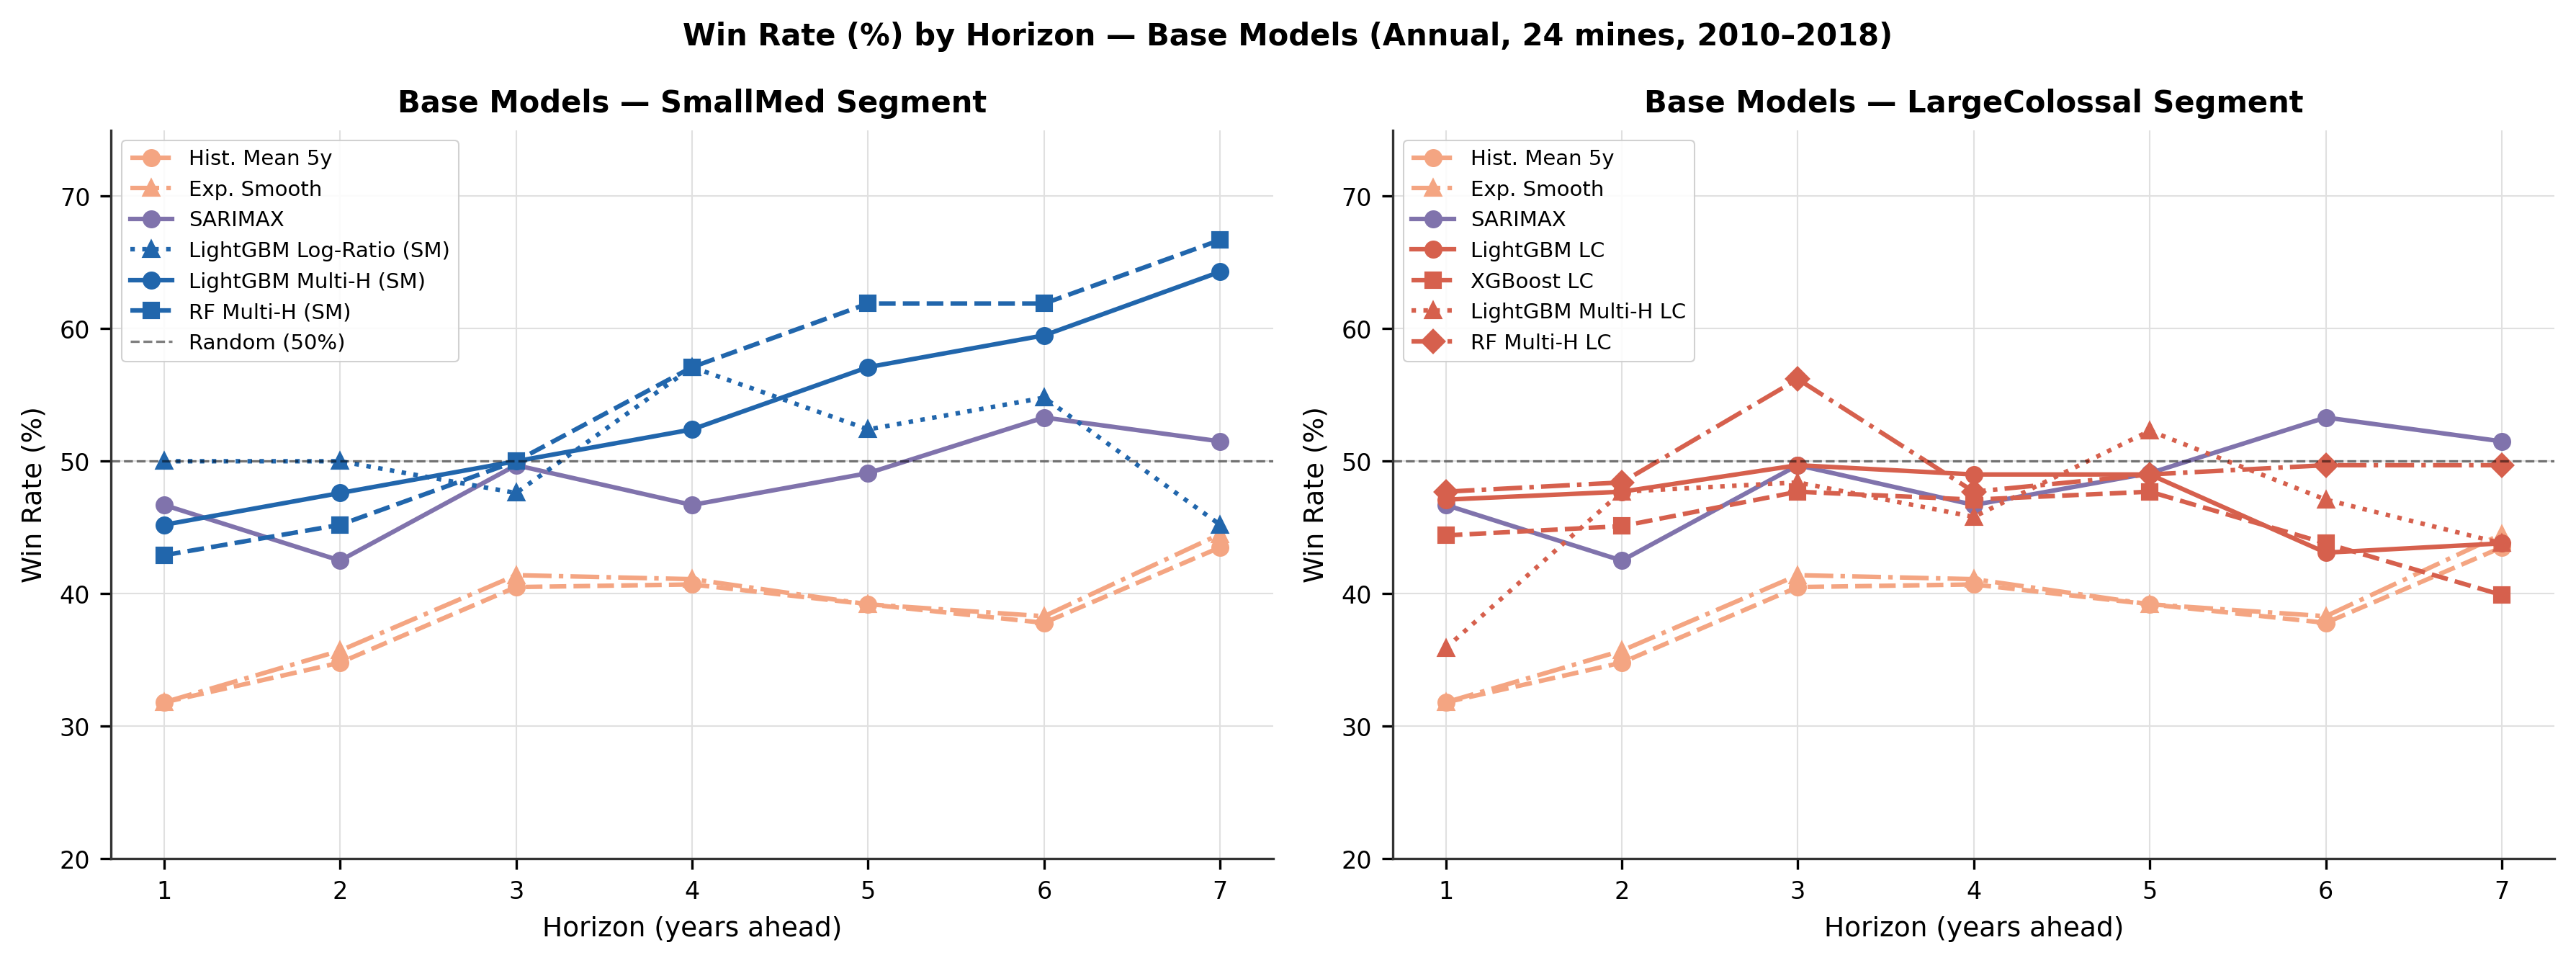

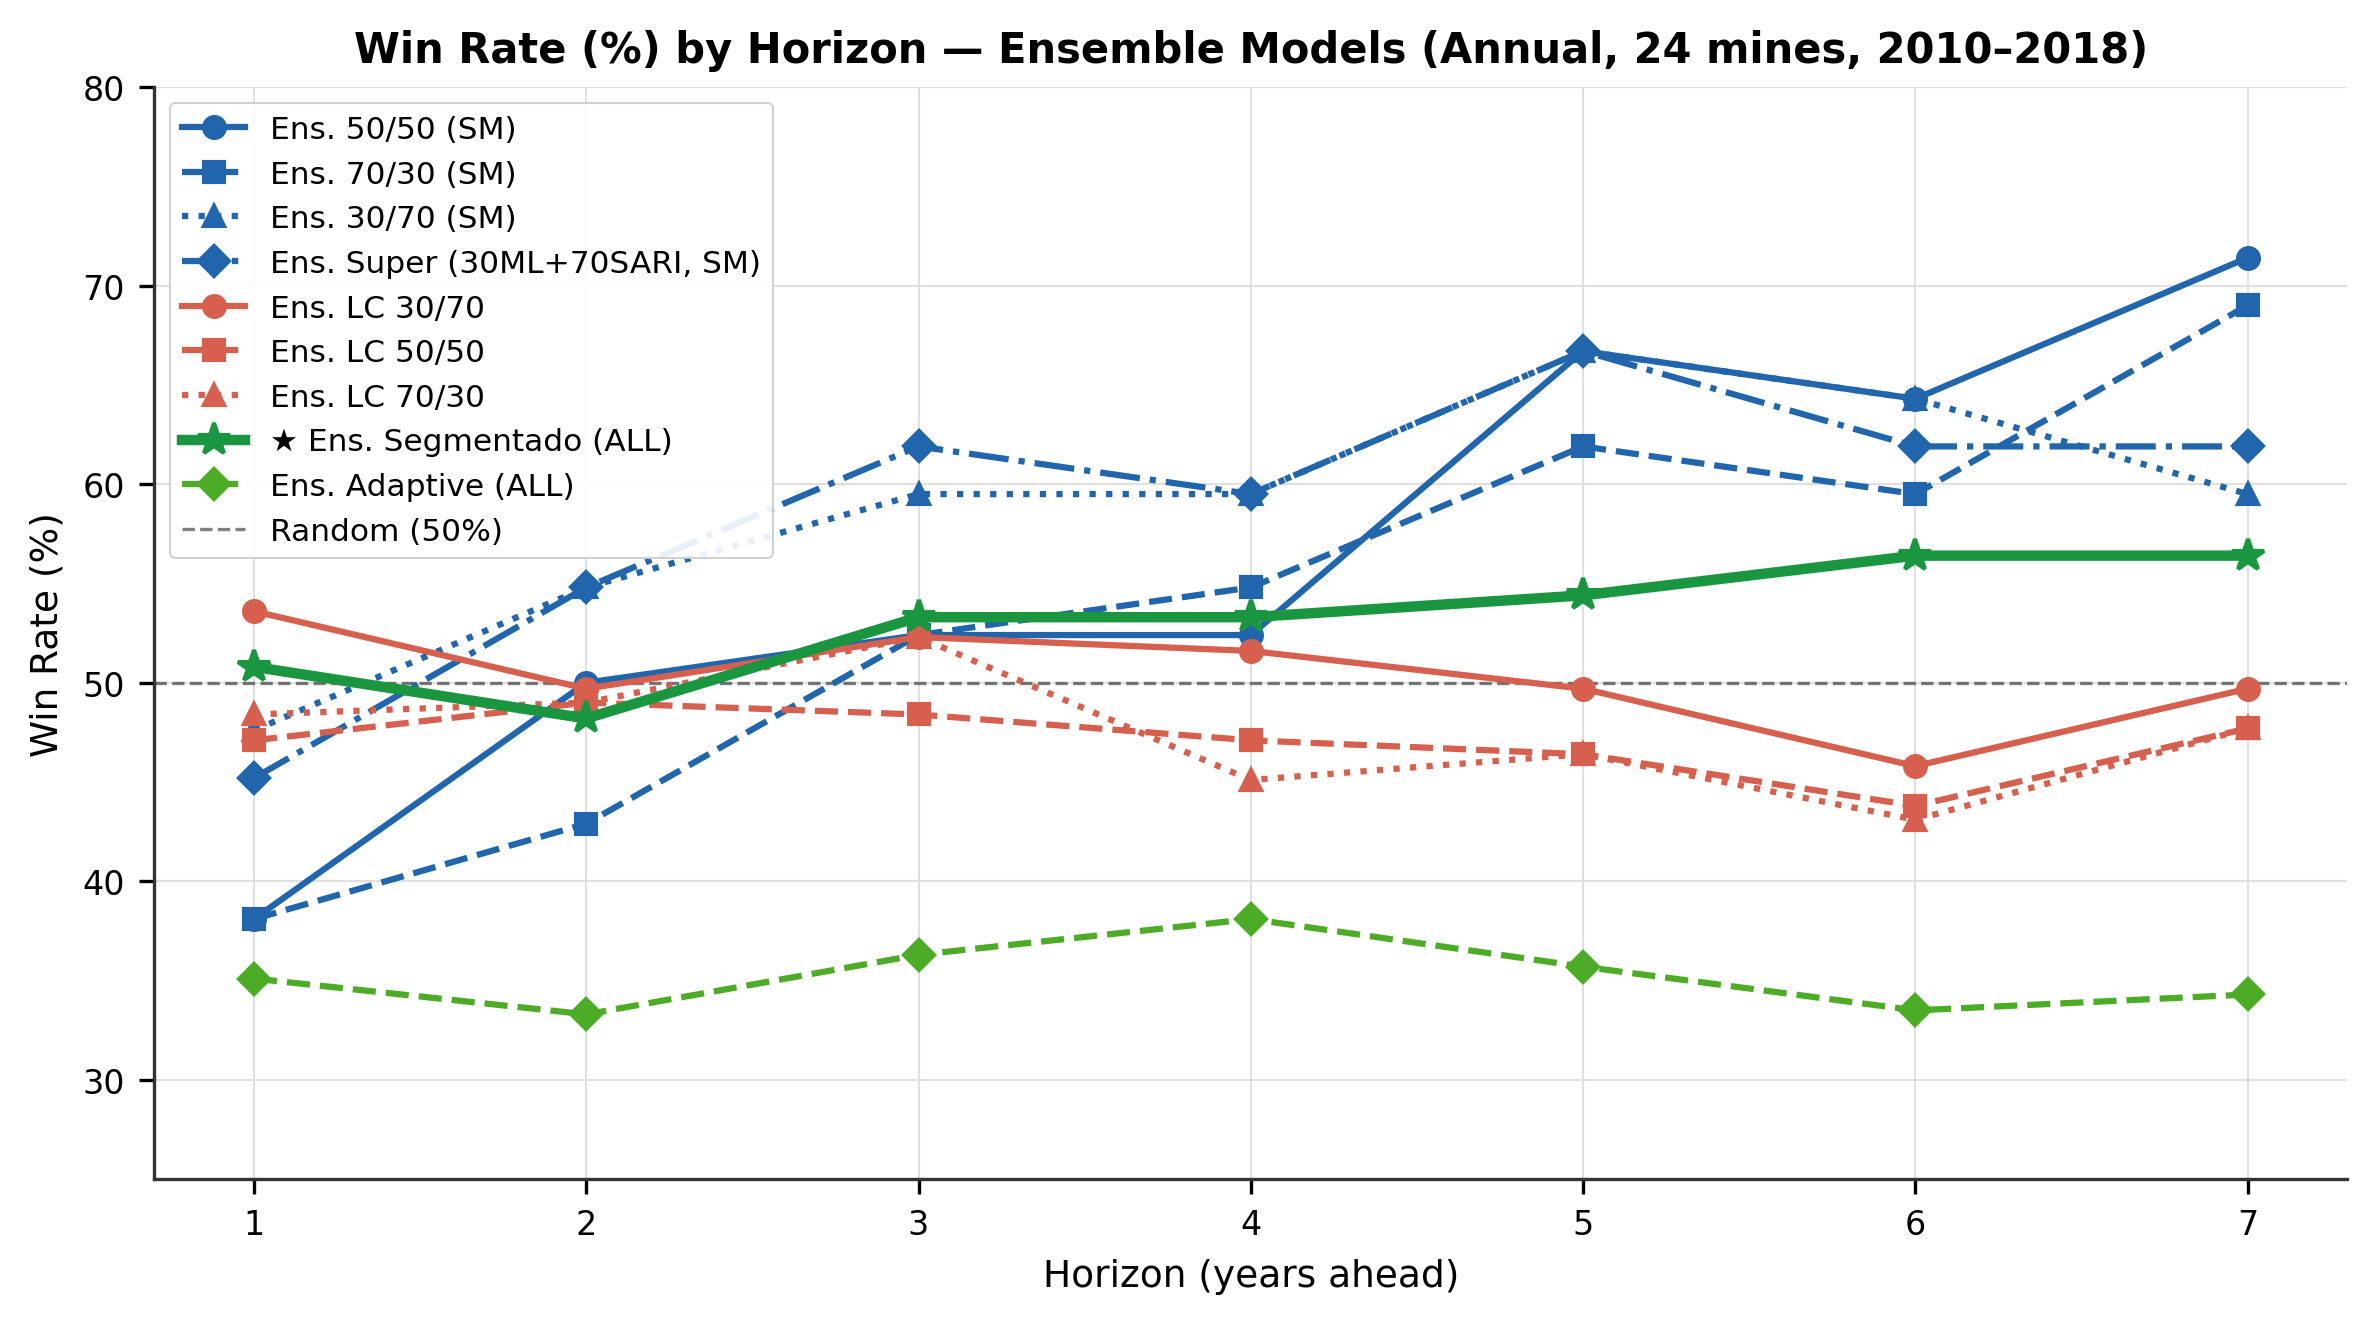

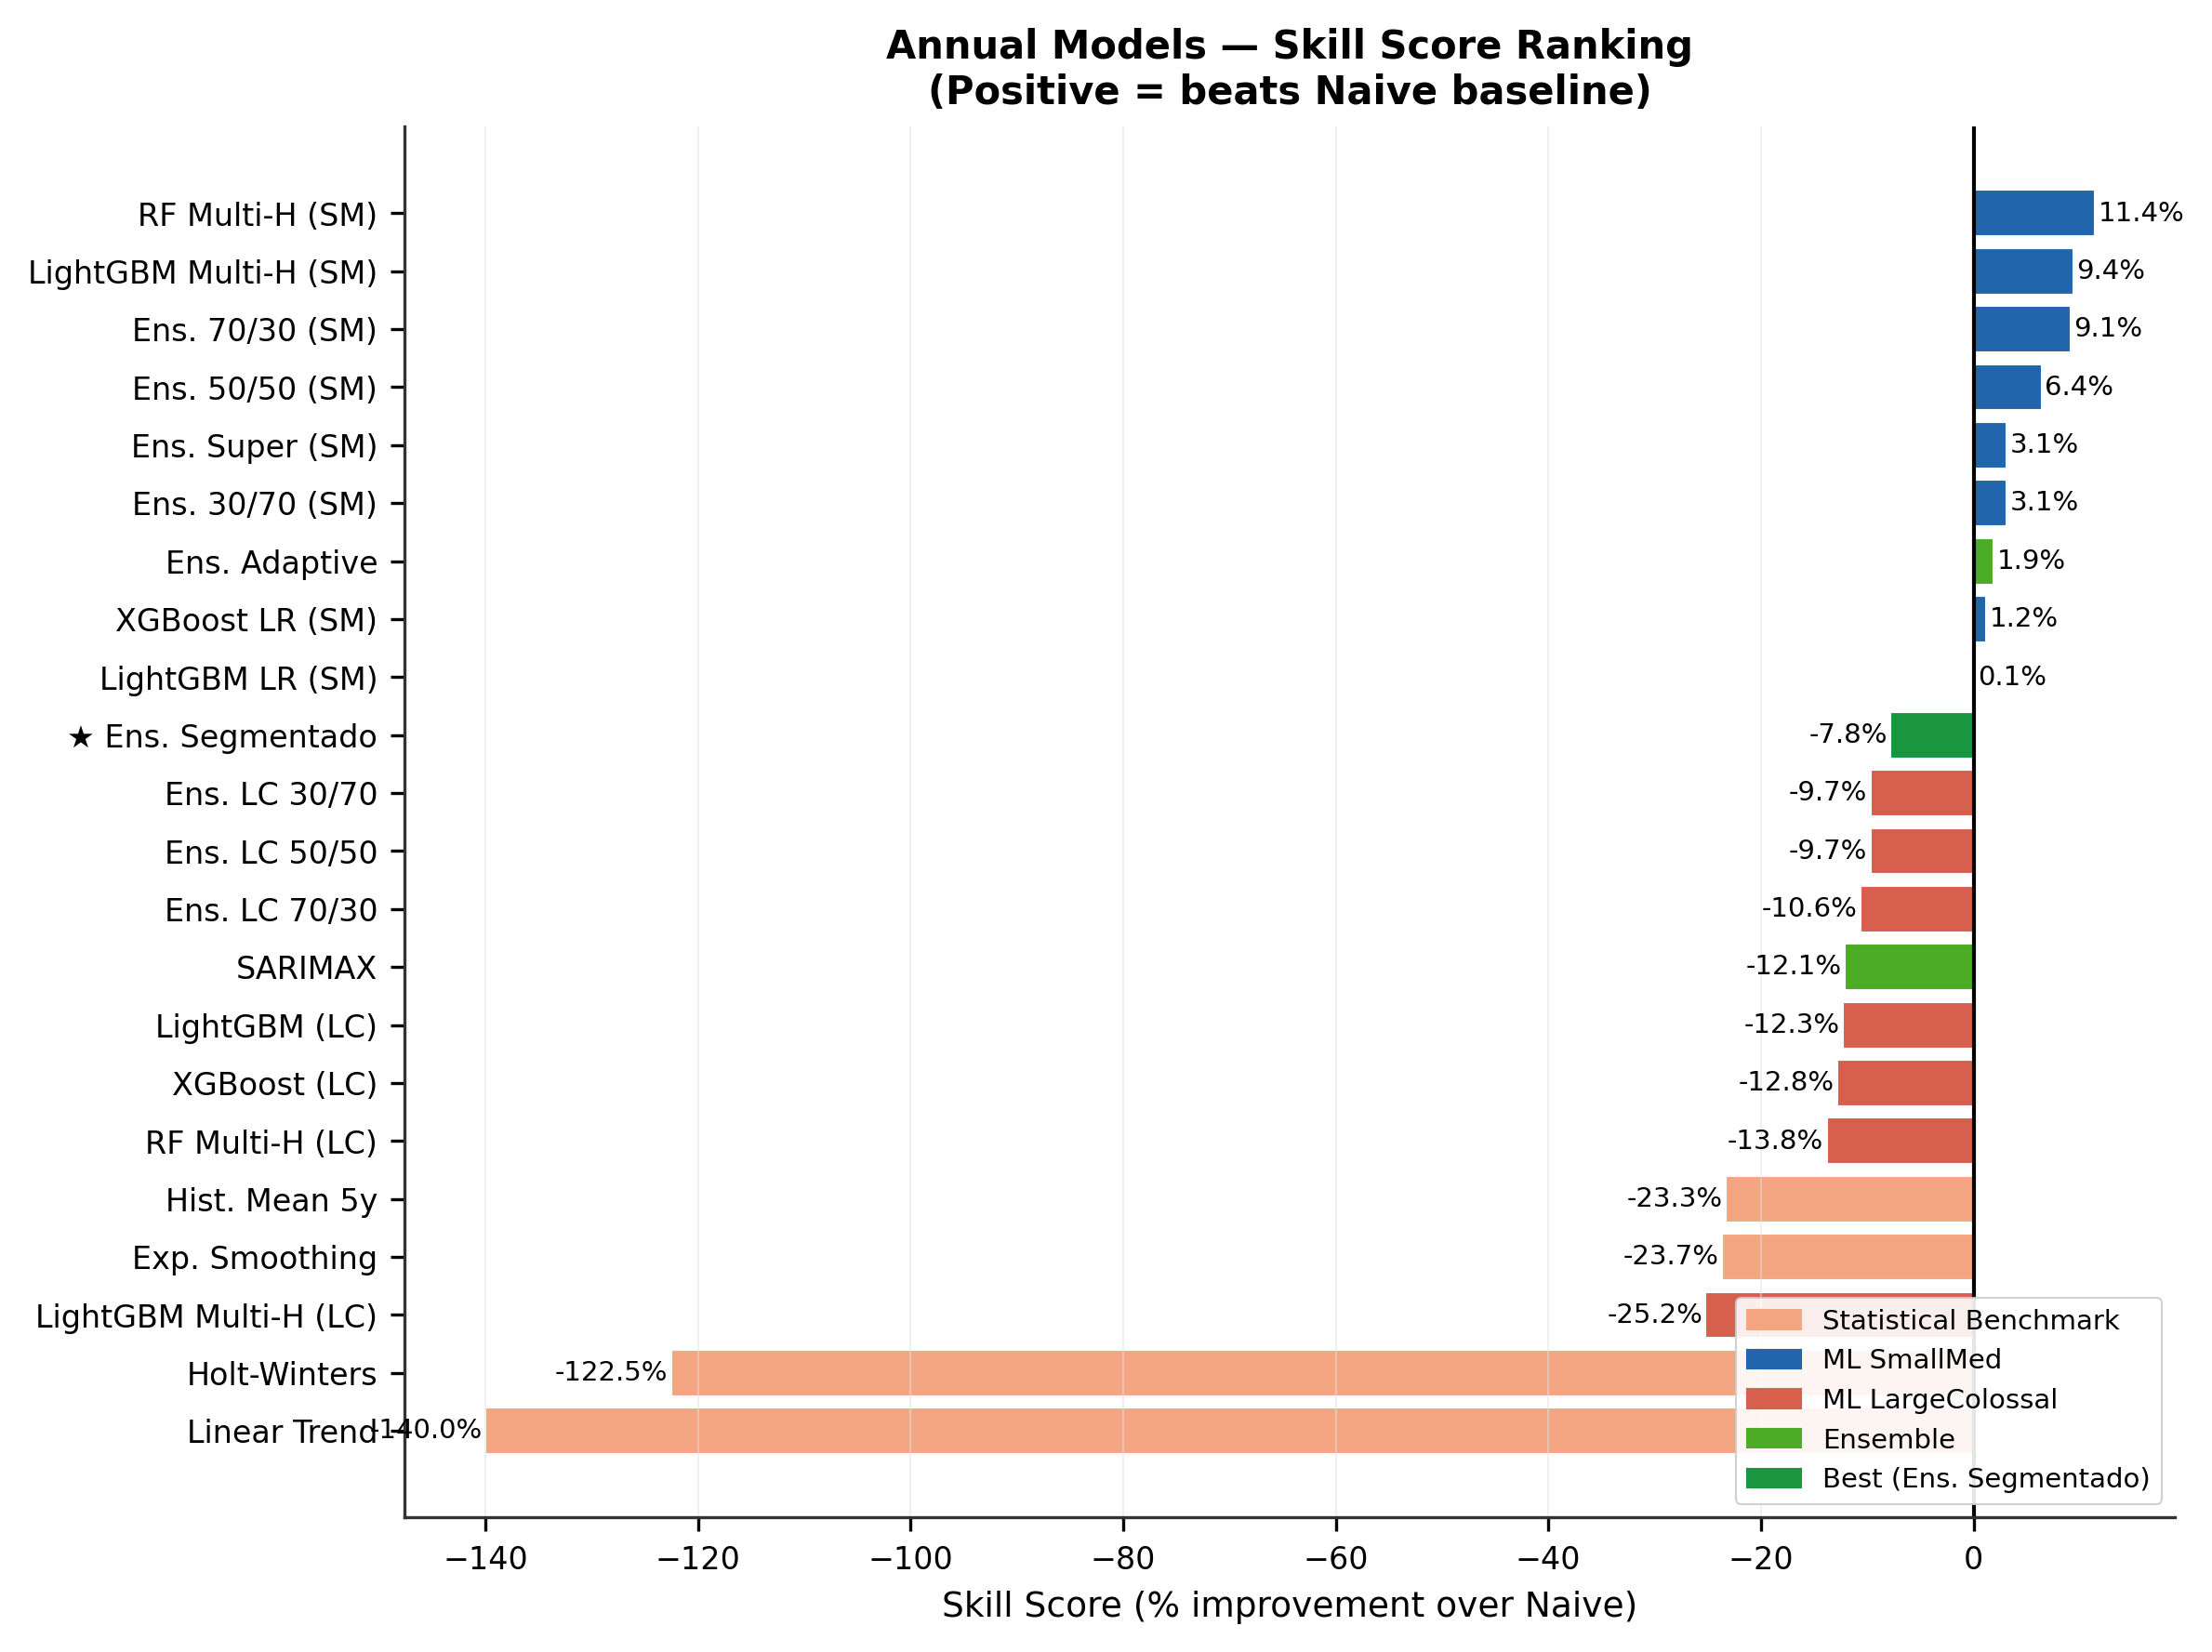

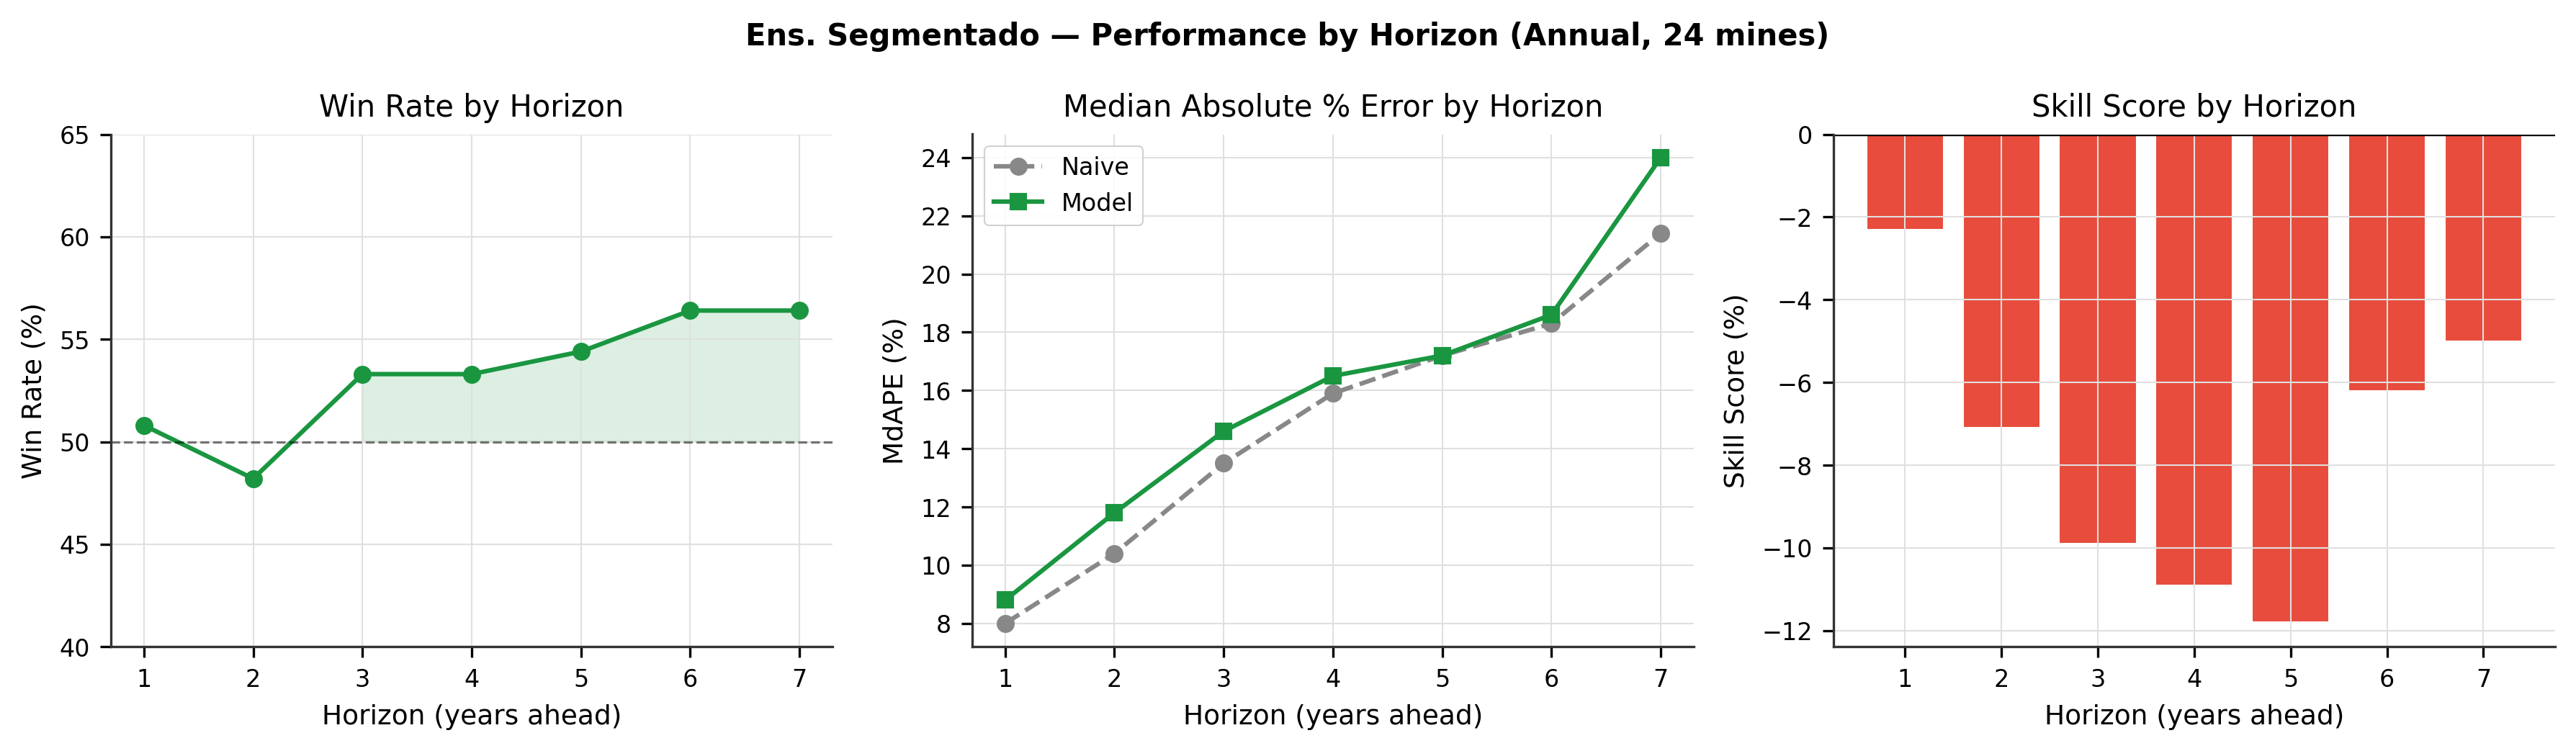

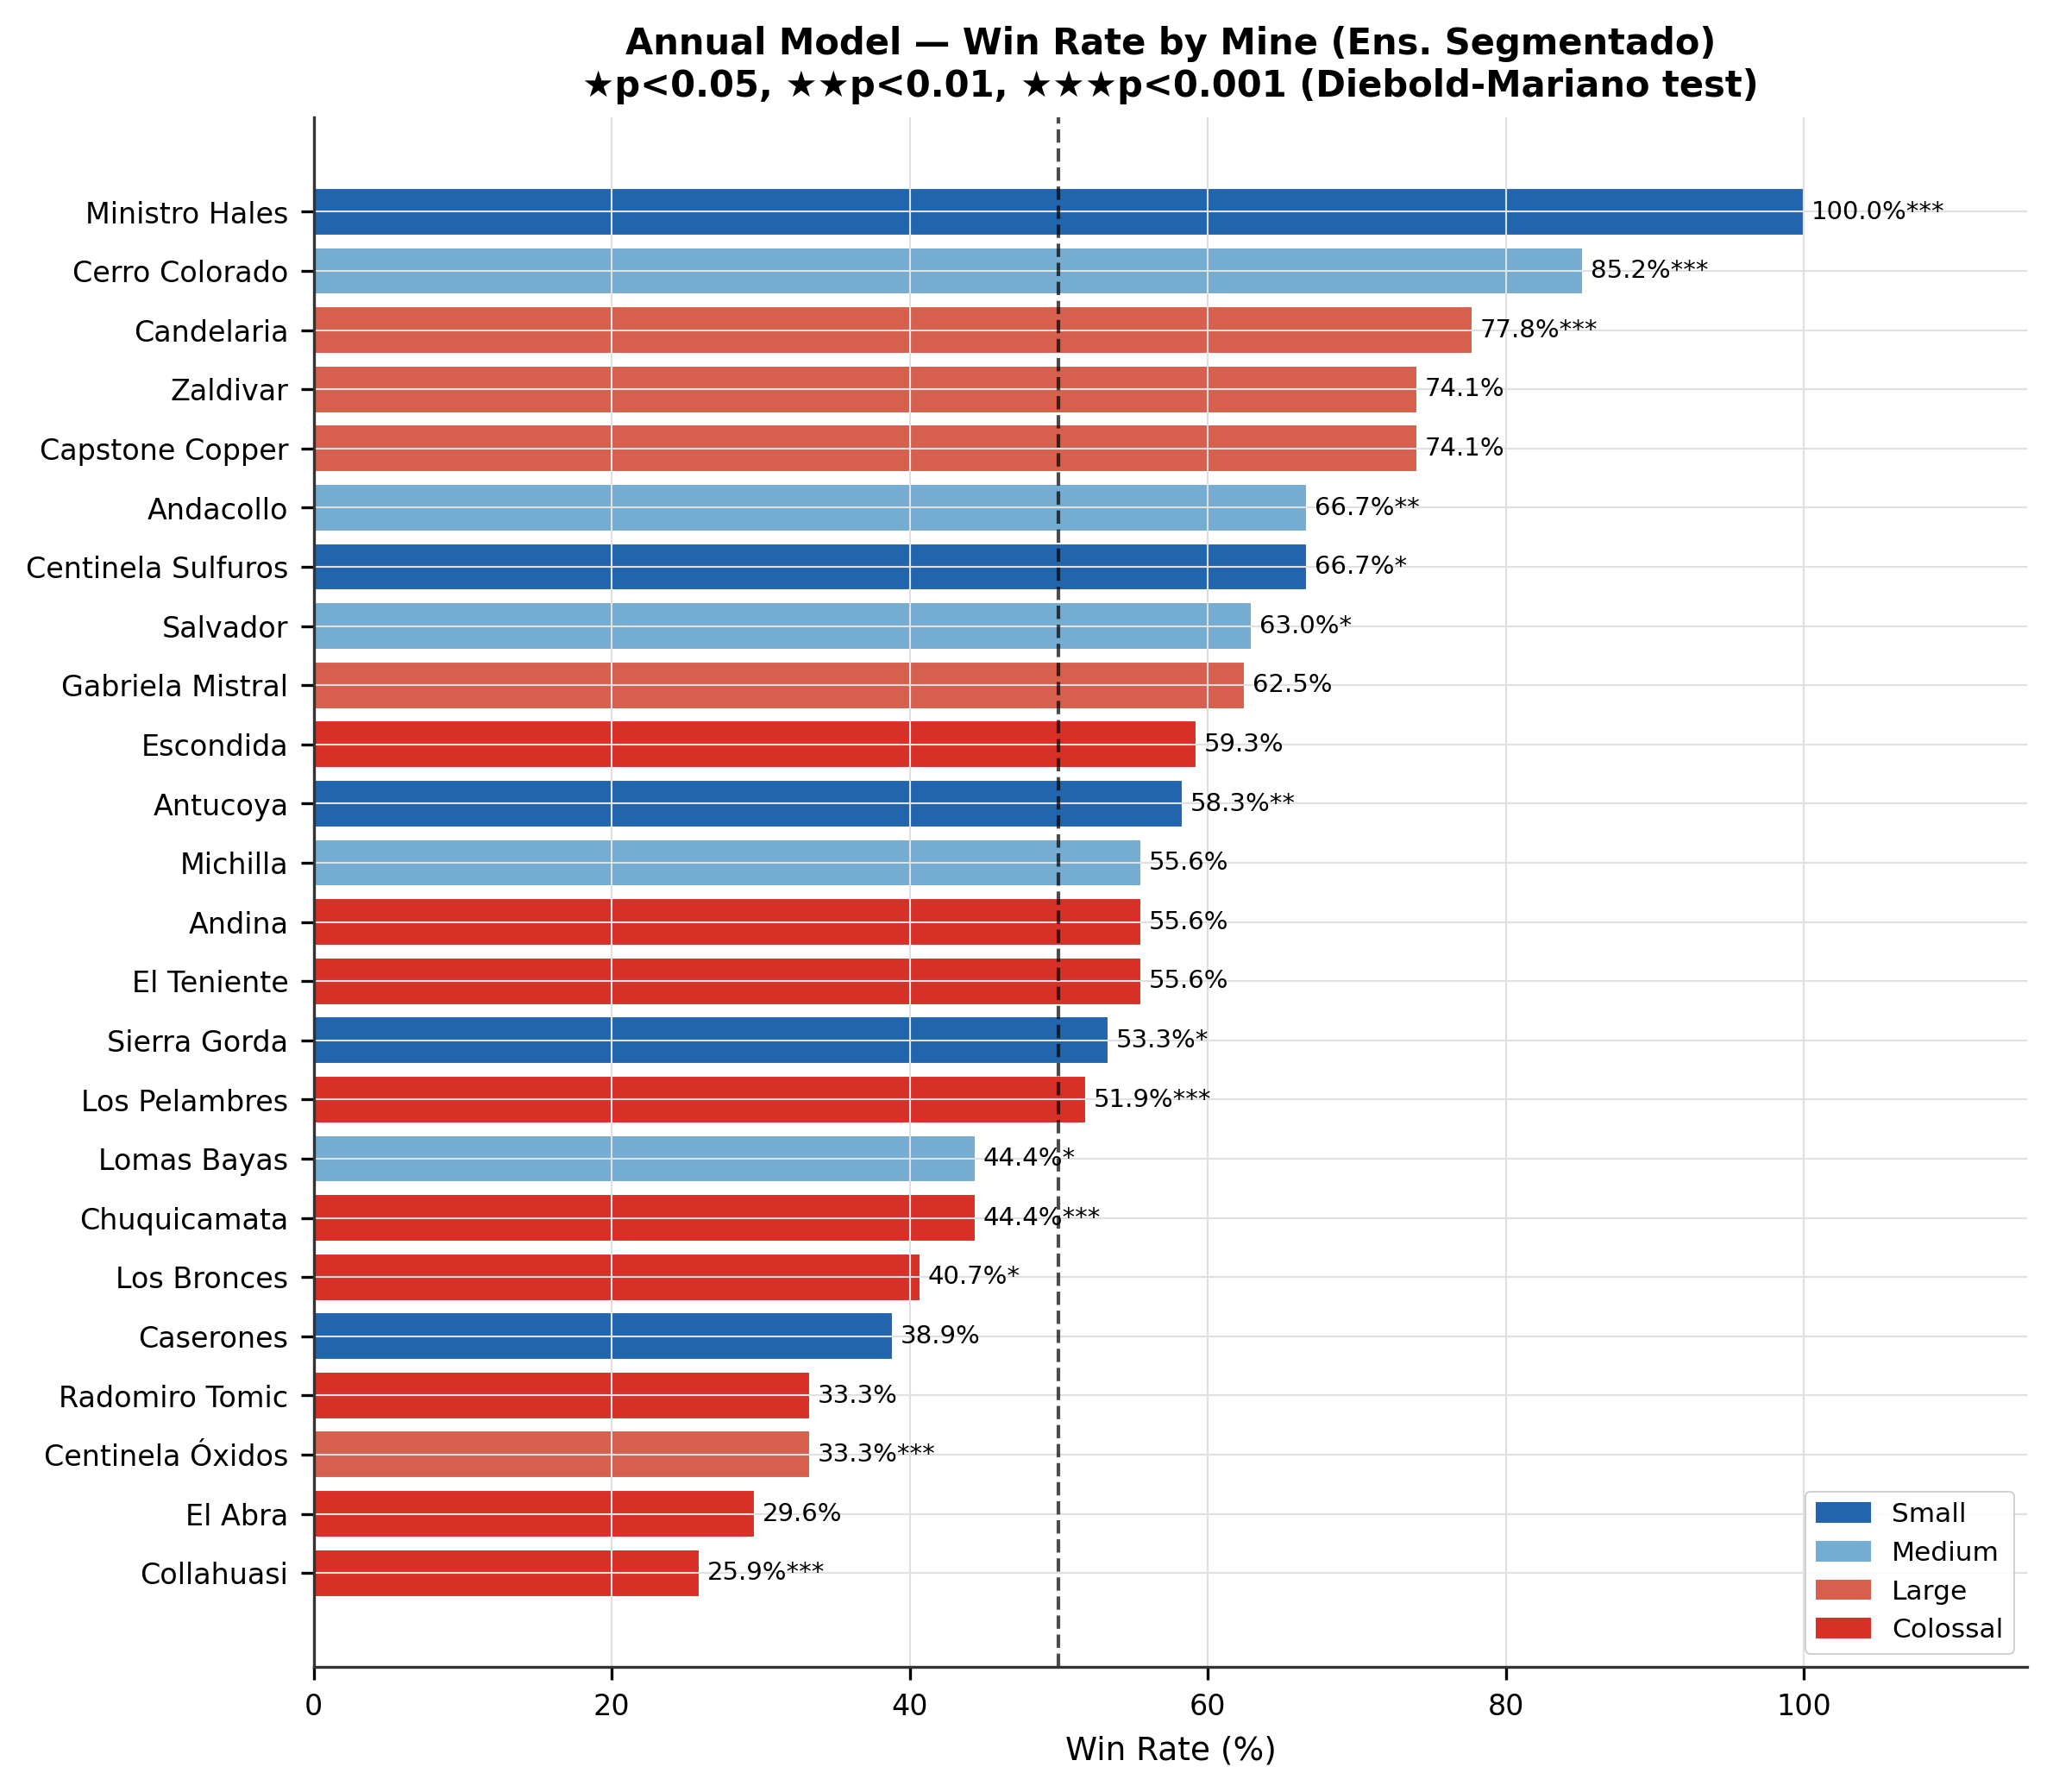

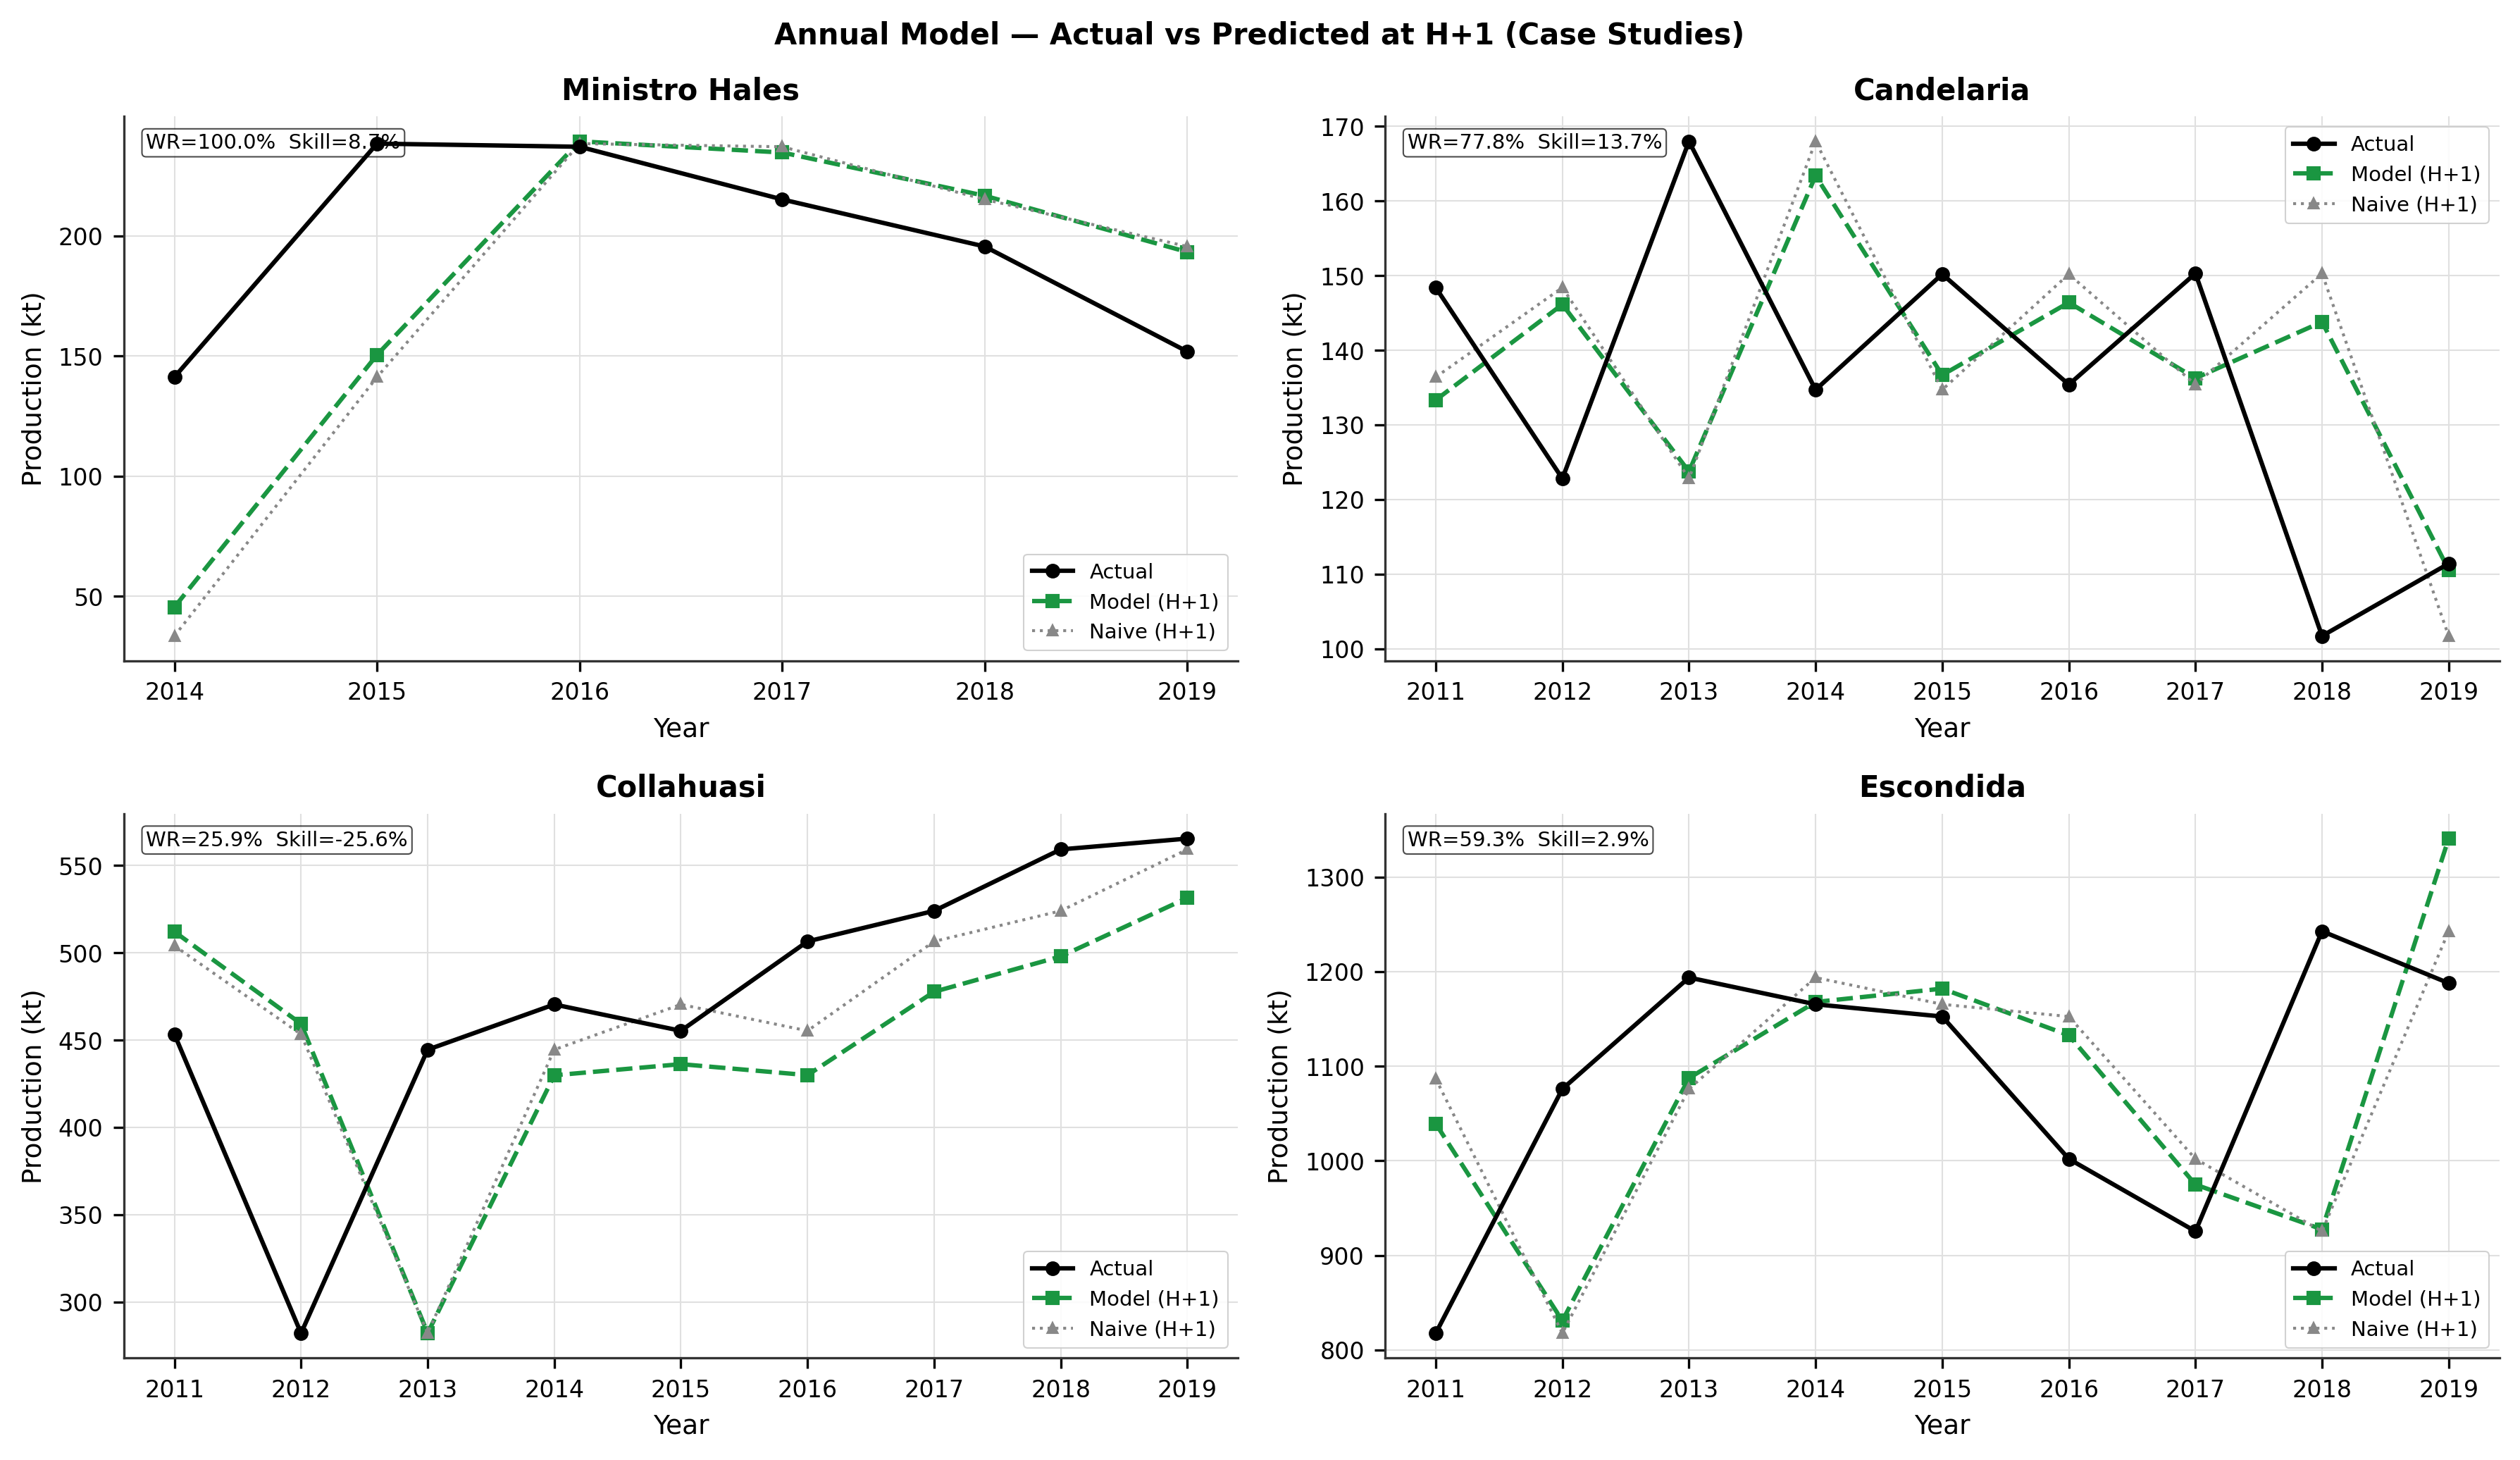

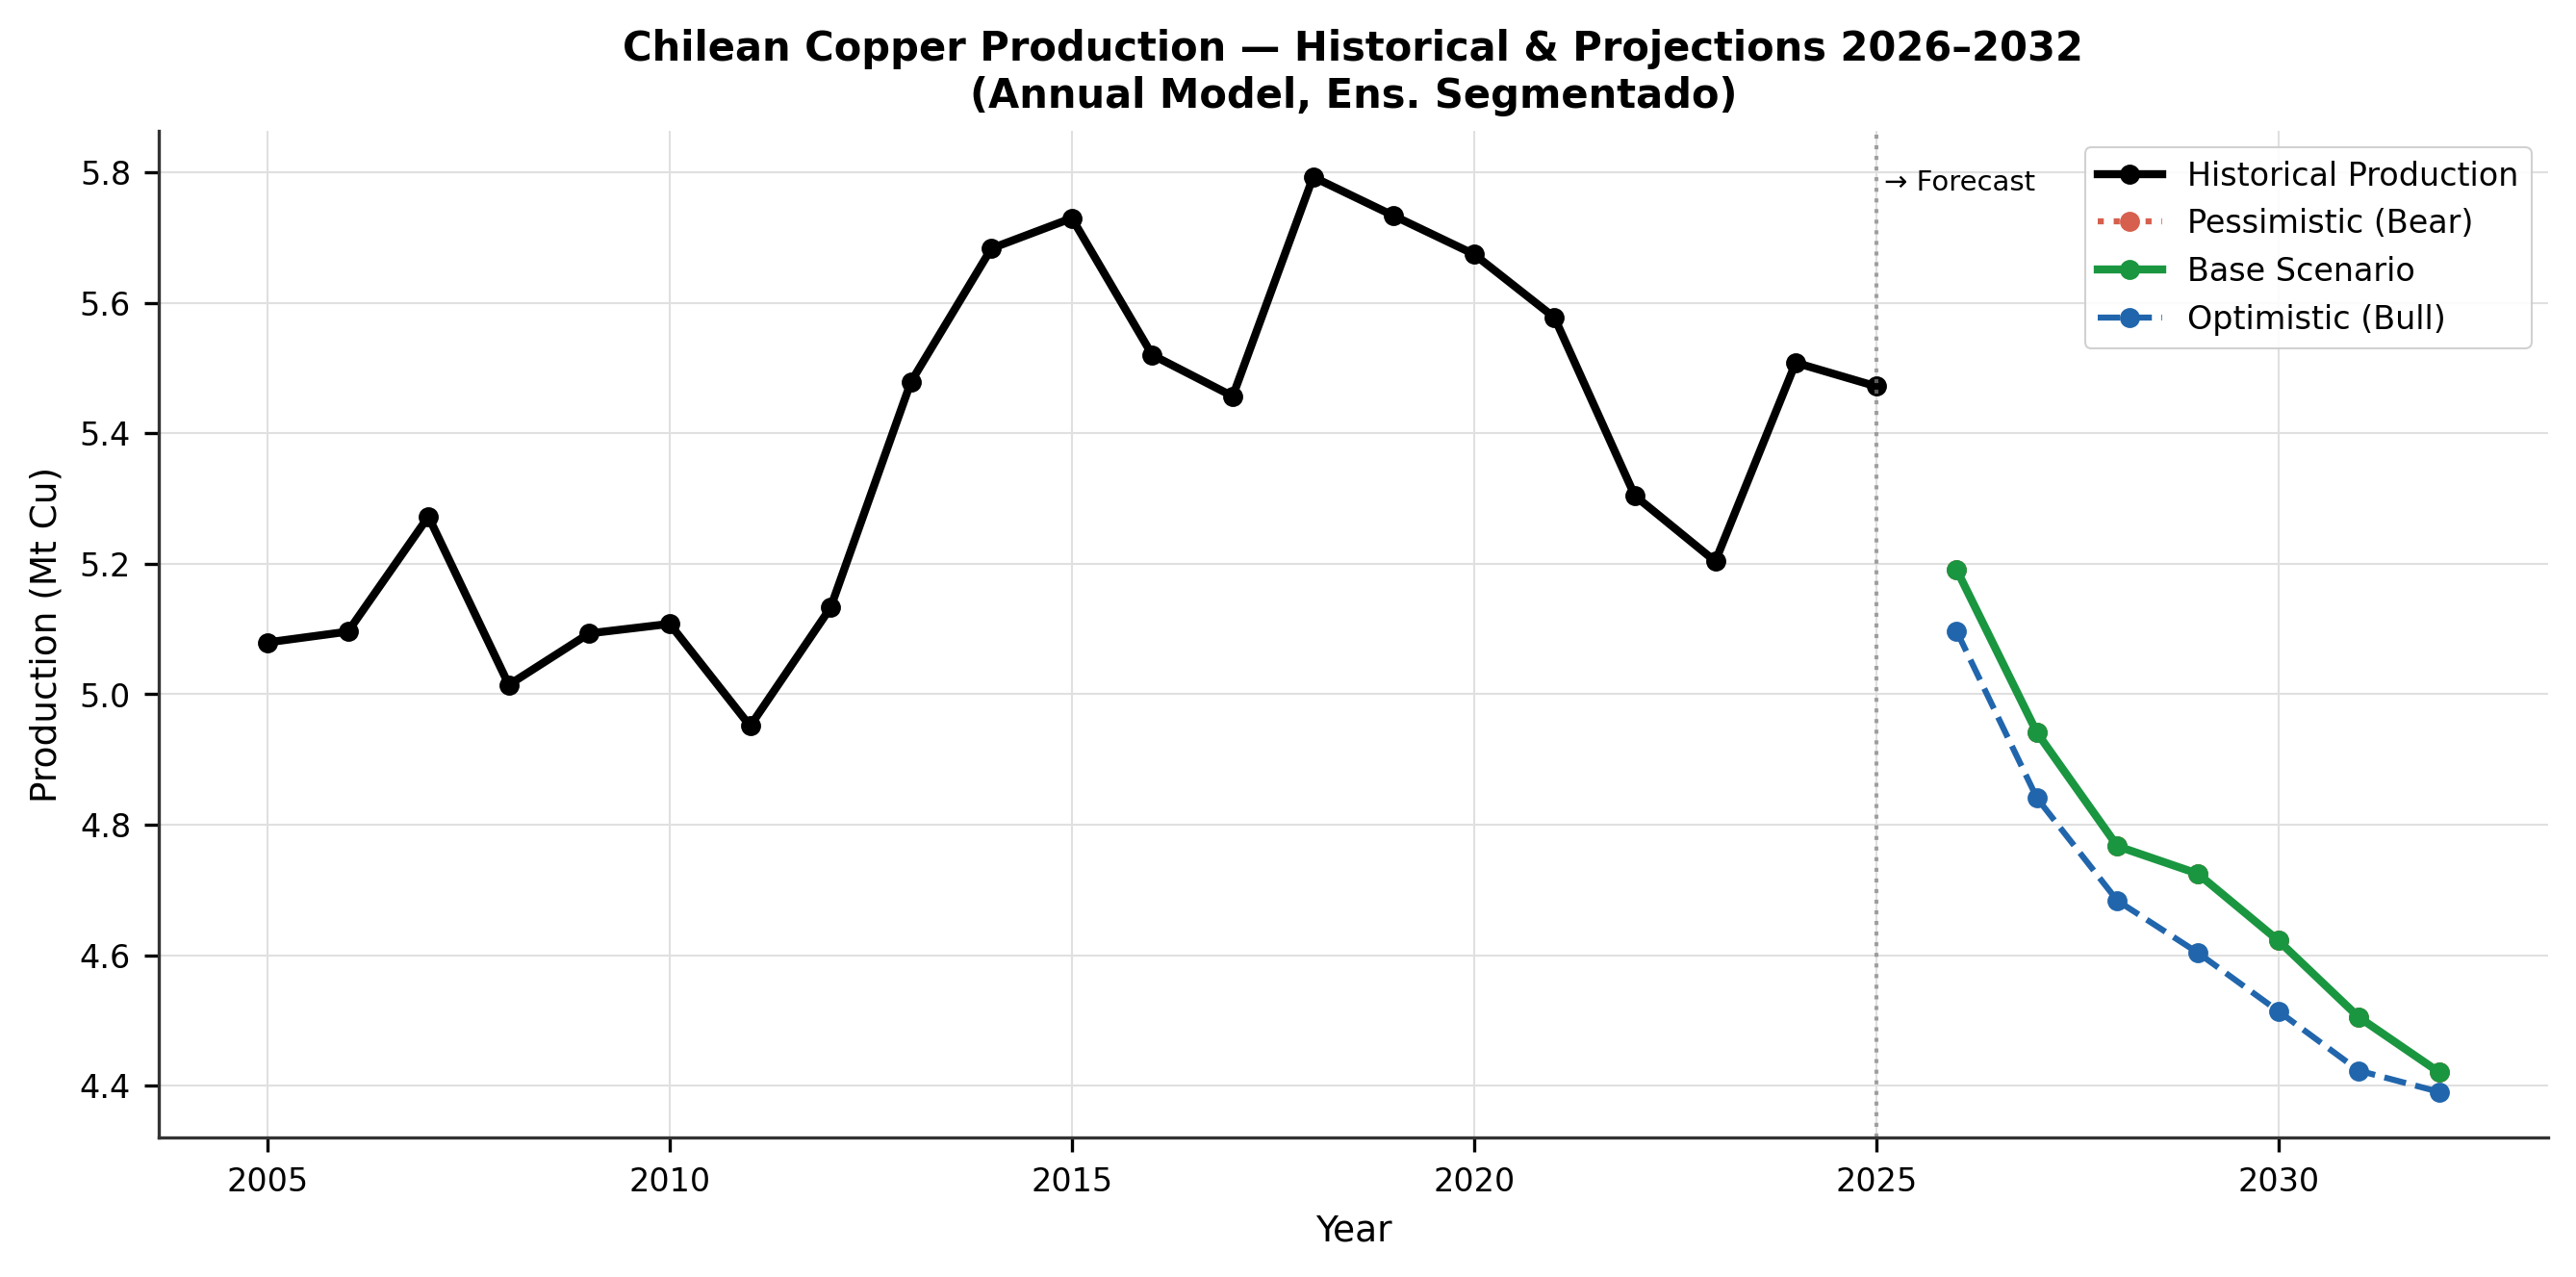

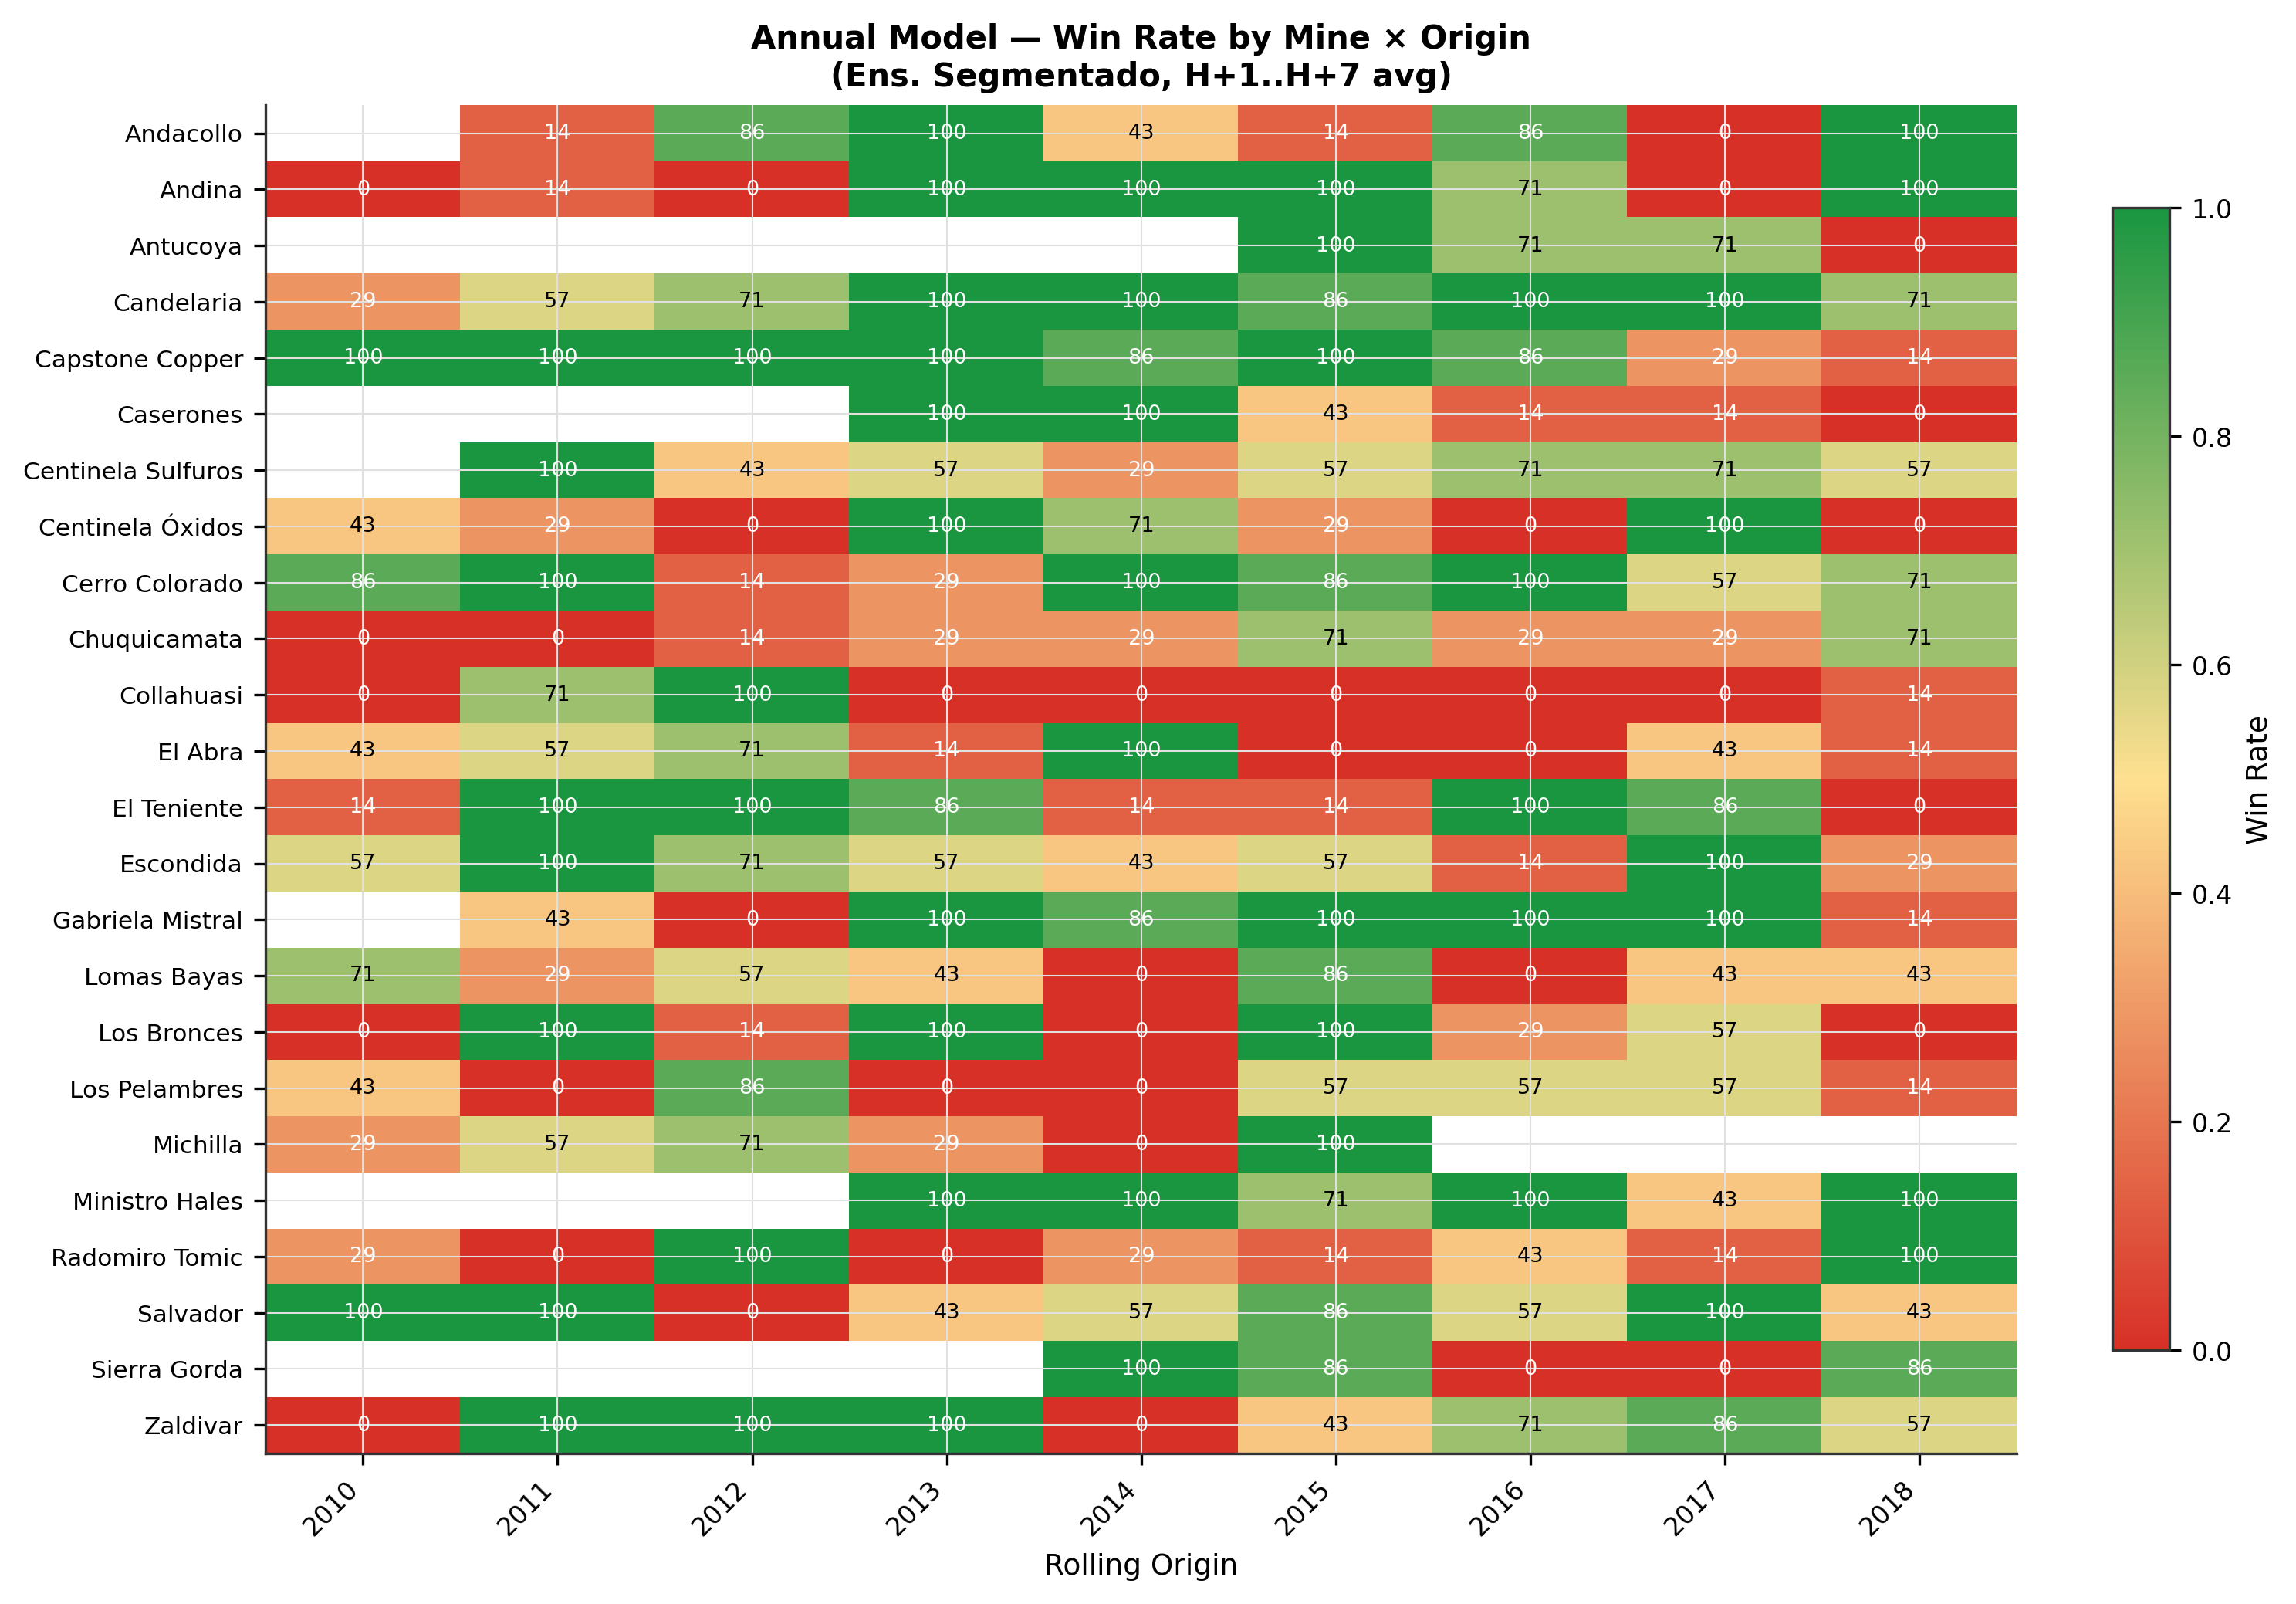

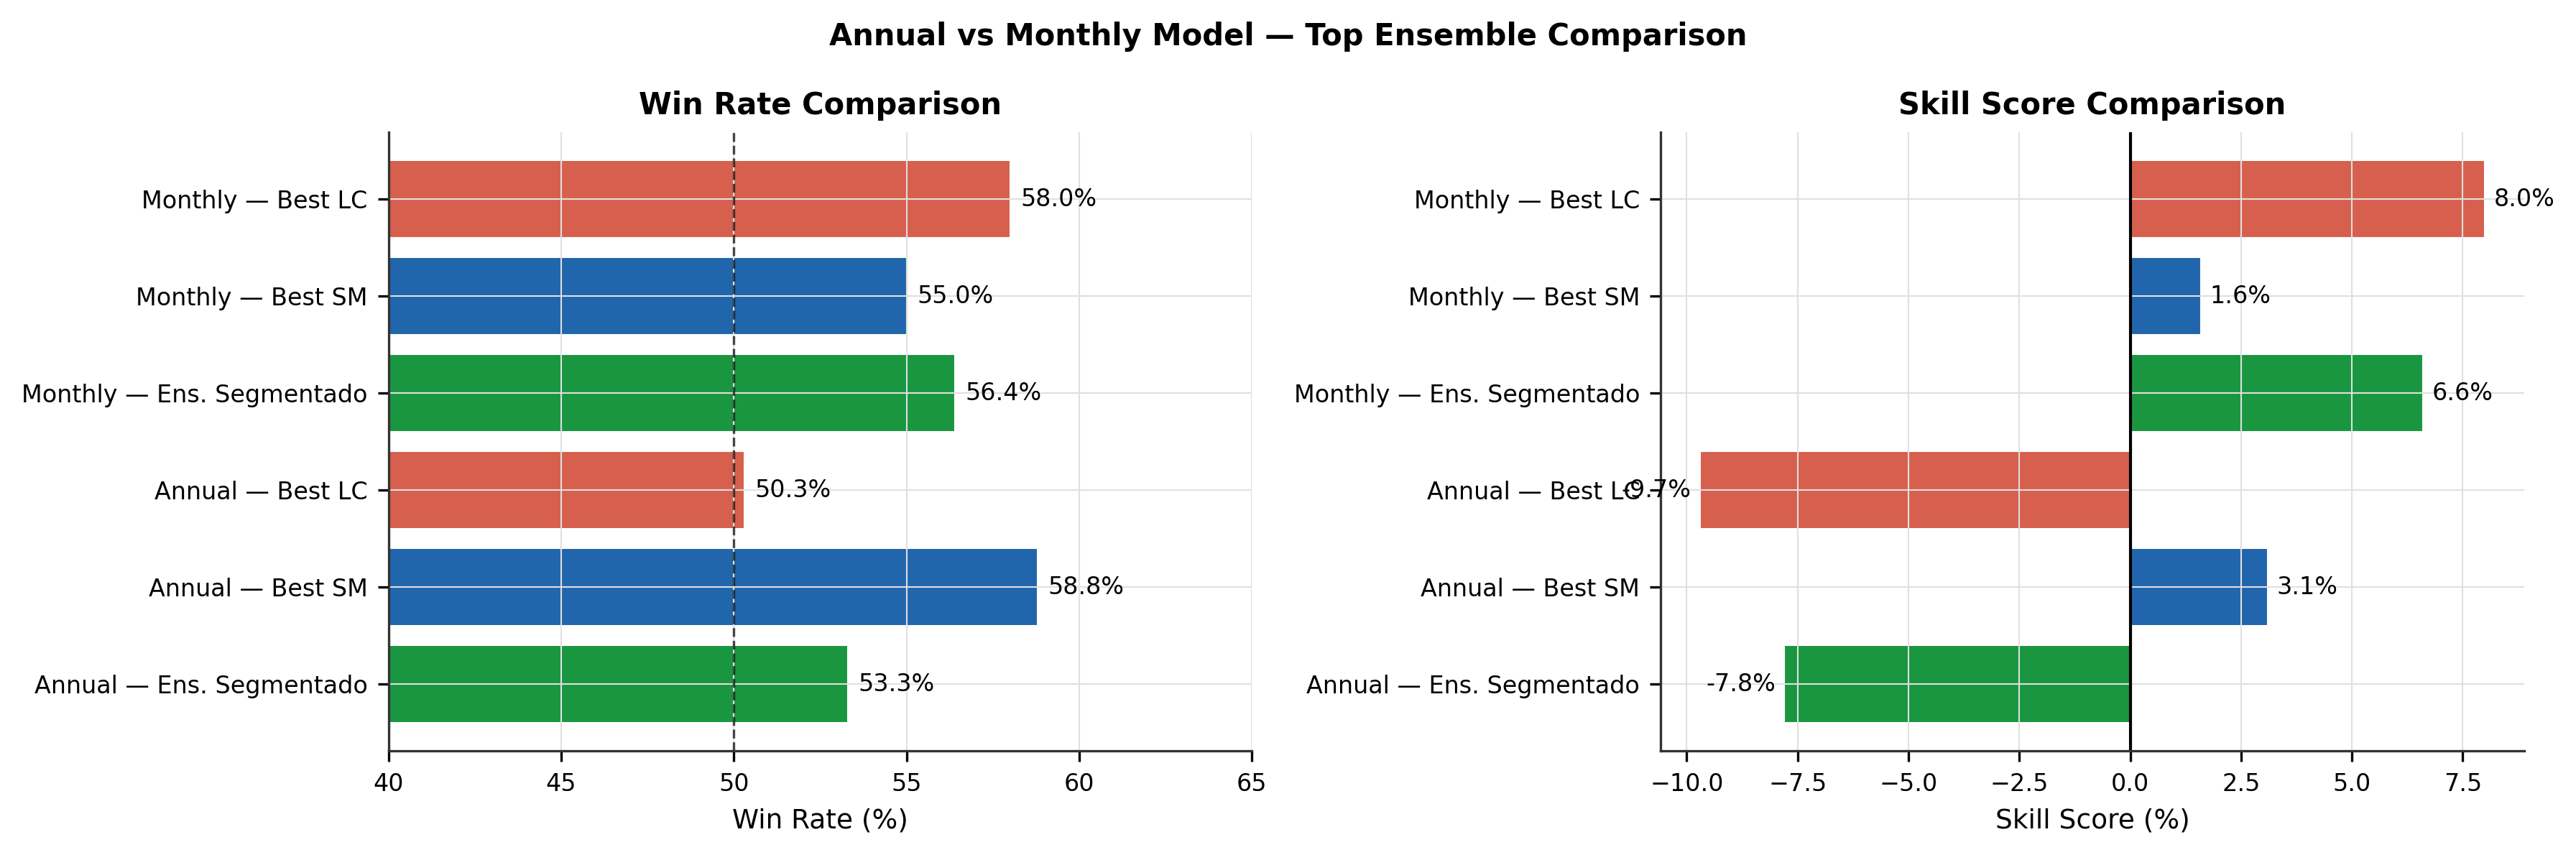

In [220]:
# ─── Figuras ─────────────────────────────────────────────────────────────────
show_fig("fig_base_models_wr_horizon", "Fig 1 — Win Rate por Horizonte: Modelos Base (SM vs LC)")
show_fig("fig_ensembles_wr_horizon",   "Fig 2 — Win Rate por Horizonte: Ensembles")
show_fig("fig_skill_ranking",          "Fig 3 — Ranking de Skill Score (todos los modelos)")
show_fig("fig_error_by_horizon",       "Fig 4 — WR%, MdAPE y Skill por Horizonte (Ens. Segmentado)")
show_fig("fig_per_mine_wr",            "Fig 5 — Win Rate por Mina (Ens. Segmentado)")
show_fig("fig_actual_vs_pred",         "Fig 6 — Actual vs Predicho en H+1 (Estudios de Caso)")
show_fig("fig_projections",            "Fig 7 — Proyecciones 2026-2032 (3 Escenarios)")
show_fig("fig_wr_heatmap_mine_origin", "Fig 8 — Heatmap WR% por Mina × Origen")
show_fig("fig_annual_vs_monthly",      "Fig 9 — Comparación Anual vs Mensual", width=1000)


## Sección 11 — Two-Stage LC: Clasificador de Dirección + Regresor de Magnitud

El segmento LargeColossal presenta dificultades estructurales (Skill=-9.7%) en el modelo base v8c.
Se propone un modelo de dos etapas:
- **Etapa 1 (Dirección):** Clasificador LightGBM binario que predice si la mina crecerá (log-ratio > 0).
  Features adicionales: `CapStock_growth`, `Consec_decline`, `Prod_vs_peak`.
- **Etapa 2 (Magnitud):** Regresor LightGBM que predice el log-ratio, condicionado en `P_up` de la Etapa 1.

El **Ensemble Híbrido** selecciona por mina: usa Two-Stage para las 4 minas donde mejora, v8c para el resto.

In [221]:
# Comparison cells referencing archived experiment outputs — skip if files not present
try:
    import pandas as pd
    import numpy as np
    
    EXPORT_DIR = 'outputs_best'
    HORIZONS   = list(range(1, 8))
    
    # Load pre-computed two-stage rolling-origin results
    df_ts_val    = pd.read_csv(f'{EXPORT_DIR}/two_stage_lc_validation.csv')
    df_ts_mine   = pd.read_csv(f'{EXPORT_DIR}/two_stage_lc_per_mine.csv')
    df_ts_sum    = pd.read_csv(f'{EXPORT_DIR}/two_stage_lc_summary.csv')
    df_hyb_sum   = pd.read_csv(f'{EXPORT_DIR}/hybrid_lc_summary.csv')
    df_hyb_mine  = pd.read_csv(f'{EXPORT_DIR}/hybrid_lc_per_mine.csv')
    
    print(f'Two-stage validation: {len(df_ts_val):,} rows, {df_ts_val["Mine"].nunique()} mines')
    print(f'Hybrid summary: {len(df_hyb_sum)} rows')
    
except FileNotFoundError as _e:
    print(f'Skipping archived comparison: {_e}')


Skipping archived comparison: [Errno 2] No such file or directory: 'outputs_best/two_stage_lc_validation.csv'


In [222]:
# Comparison cell (archived experiment data) — skip if vars not defined
try:
    # ── Global Summary: TwoStage variants vs v8c reference ──────────────────────
    print('='*80)
    print('  TWO-STAGE LC — Rolling-Origin Validation (2010–2018)')
    print('='*80)
    
    # Add v8c reference row
    v8c_ref = pd.DataFrame([{
        'Model': 'Ens_LC_3070 v8c (ref)', 'WR%': 50.3, 'Skill%': -9.7,
        'MdAPE': '--', 'H57%': 48.4
    }])
    display_sum = pd.concat([df_ts_sum[['Model','WR%','Skill%','MdAPE','H57%']], v8c_ref],
                             ignore_index=True)
    display(display_sum.style
        .format({'WR%': '{:.1f}', 'Skill%': '{:+.1f}', 'H57%': '{:.1f}'}, na_rep='--')
        .set_caption('Two-Stage LC — Resumen global vs referencia v8c')
        .highlight_max(subset=['WR%','H57%'], color='#d4f1d4')
    )
    
except (NameError, FileNotFoundError) as _e:
    print(f'Skipping archived comparison: {_e}')


  TWO-STAGE LC — Rolling-Origin Validation (2010–2018)
Skipping archived comparison: name 'df_ts_sum' is not defined


In [223]:
# Comparison cell (archived experiment data) — skip if vars not defined
try:
    # ── Hybrid Ensemble: Ens_Segmentado_Hybrid vs v8c (all 24 mines) ────────────
    print('='*80)
    print('  HYBRID ENSEMBLE — Ens_Segmentado_Hybrid vs Ens_Segmentado_v8c')
    print('  (SM: Ens_Super_Annual unchanged | LC: TwoStage for 4 mines, v8c for rest)')
    print('='*80)
    
    h_cols = [f'H+{h}' for h in HORIZONS]
    cols_show = ['Model','WR%','Skill%','H57%','Mines>=50%'] + h_cols
    display(df_hyb_sum[cols_show].style
        .format({c: '{:.1f}' for c in ['WR%','Skill%','H57%'] + h_cols})
        .set_caption('Ens_Segmentado_Hybrid vs v8c — Validación rolling-origin (2010–2018)')
        .highlight_max(subset=['WR%','Skill%','H57%','Mines>=50%'], color='#d4f1d4')
    )
    
    # Delta summary
    hyb = df_hyb_sum[df_hyb_sum['Model']=='Ens_Segmentado_Hybrid'].iloc[0]
    v8c = df_hyb_sum[df_hyb_sum['Model']=='Ens_Segmentado_v8c'].iloc[0]
    print(f'\nDelta Hybrid vs v8c:')
    print(f'  WR%:       {hyb["WR%"]:.1f}% vs {v8c["WR%"]:.1f}%  →  {hyb["WR%"]-v8c["WR%"]:+.1f}pp')
    print(f'  Skill%:    {hyb["Skill%"]:+.1f}% vs {v8c["Skill%"]:+.1f}%  →  {hyb["Skill%"]-v8c["Skill%"]:+.1f}pp')
    print(f'  H57%:      {hyb["H57%"]:.1f}% vs {v8c["H57%"]:.1f}%  →  {hyb["H57%"]-v8c["H57%"]:+.1f}pp')
    print(f'  Mines≥50%: {int(hyb["Mines>=50%"])} vs {int(v8c["Mines>=50%"])}  →  {int(hyb["Mines>=50%"]-v8c["Mines>=50%"]):+d} minas')
    
except (NameError, FileNotFoundError) as _e:
    print(f'Skipping archived comparison: {_e}')


  HYBRID ENSEMBLE — Ens_Segmentado_Hybrid vs Ens_Segmentado_v8c
  (SM: Ens_Super_Annual unchanged | LC: TwoStage for 4 mines, v8c for rest)
Skipping archived comparison: name 'df_hyb_sum' is not defined


In [224]:
# Comparison cell (archived experiment data) — skip if vars not defined
try:
    # ── Per-mine: Hybrid vs v8c ──────────────────────────────────────────────────
    TWO_STAGE_MINES = {'el abra', 'centinela_centinela_óxidos_', 'los bronces', 'collahuasi'}
    
    df_pm = df_hyb_mine.copy()
    df_pm['Two-Stage'] = df_pm['Mine'].isin(TWO_STAGE_MINES)
    df_pm['Delta_str'] = df_pm['Delta'].apply(
        lambda d: f'+{d:.1f}pp' if d > 0 else (f'{d:.1f}pp' if not np.isnan(d) else 'n/a')
    )
    
    def highlight_ts(row):
        color = '#fff3cd' if row['Two-Stage'] else ''
        return [f'background-color: {color}'] * len(row)
    
    show_cols = ['Mine','Source','WR_Hybrid','WR_v8c','Delta','Skill_Hybrid','Two-Stage']
    display(df_pm[show_cols].sort_values('Mine').style
        .apply(highlight_ts, axis=1)
        .format({'WR_Hybrid': '{:.1f}%', 'WR_v8c': '{:.1f}%',
                 'Delta': '{:+.1f}pp', 'Skill_Hybrid': '{:+.1f}%'})
        .set_caption('Por mina — Hybrid vs v8c. Amarillo = minas Two-Stage activo.')
    )
    
    # Summary stats
    ts_mines = df_pm[df_pm['Two-Stage']]
    print(f'\nMinas Two-Stage ({len(ts_mines)}):')
    for _, r in ts_mines.iterrows():
        print(f'  {r["Mine"]:<42} WR: {r["WR_v8c"]:.1f}% → {r["WR_Hybrid"]:.1f}%  ({r["Delta"]:+.1f}pp)')
    
except (NameError, FileNotFoundError) as _e:
    print(f'Skipping archived comparison: {_e}')


Skipping archived comparison: name 'df_hyb_mine' is not defined


In [225]:
# Comparison cells referencing archived experiment outputs — skip if files not present
try:
    # ── Horizon breakdown: TwoStage vs v8c by H ─────────────────────────────────
    df_ts_h = pd.read_csv(f'{EXPORT_DIR}/two_stage_lc_by_horizon.csv')
    df_ens = df_ts_h[df_ts_h['Model']=='Ens_TwoStage_3070'][['H','WR%','Skill%']].copy()
    df_ens.columns = ['Horizonte','WR_TwoStage%','Skill_TwoStage%']
    
    # v8c LC per horizon reference (from all_predictions_annual_v10.csv)
    try:
        df_v8c_all = pd.read_csv(f'{EXPORT_DIR}/all_predictions_annual_v10.csv')
        lc_v8c_h = []
        for h in HORIZONS:
            sub = df_v8c_all[(df_v8c_all['Exp']=='Ens_LC_3070') & (df_v8c_all['Horizonte']==h)]
            if len(sub):
                lc_v8c_h.append({'Horizonte': h, 'WR_v8c%': round(100*sub['Beats_Naive'].mean(),1)})
        df_v8c_h = pd.DataFrame(lc_v8c_h)
        df_h_comp = df_ens.merge(df_v8c_h, on='Horizonte')
        df_h_comp['Delta'] = df_h_comp['WR_TwoStage%'] - df_h_comp['WR_v8c%']
        display(df_h_comp.style
            .format({'WR_TwoStage%':'{:.1f}','Skill_TwoStage%':'{:+.1f}','WR_v8c%':'{:.1f}','Delta':'{:+.1f}pp'})
            .set_caption('WR% por horizonte — Ens_TwoStage_3070 vs Ens_LC_3070 v8c')
            .background_gradient(subset=['Delta'], cmap='RdYlGn', vmin=-15, vmax=15)
        )
    except Exception as e:
        print(f'v8c reference not loaded: {e}')
        display(df_ens)
    
except FileNotFoundError as _e:
    print(f'Skipping archived comparison: {_e}')


Skipping archived comparison: [Errno 2] No such file or directory: 'outputs_best/two_stage_lc_by_horizon.csv'


In [226]:
# ══════════════════════════════════════════════════════════════════════════════
# CANONICAL EXPORT — Ens_Stack_LGB como modelo de producción (v30)
# Genera scoreboard_annual_v10.csv y resumen_annual_v10.csv
# Split: VALIDATION (origins 2010-2018) vs TEST (origin 2019)
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

BEST_MODEL   = 'Ens_Stack_LGB'
OUT          = 'outputs_best'
HORIZONS     = list(range(1, 8))
_TEST_ORIG   = TEST_ORIGINS if 'TEST_ORIGINS' in dir() else {2019}
PANDEMIC_YRS = {2020, 2021}

# ── Cargar todas las predicciones ────────────────────────────────────────────
df_all  = pd.read_csv(f'{OUT}/all_predictions_annual_v10.csv')
df_best = df_all[df_all['Exp'] == BEST_MODEL].copy()

if df_best.empty:
    print(f'ERROR: {BEST_MODEL} no encontrado en all_predictions_annual_v10.csv')
else:
    df_best['ae']  = (df_best['Pred']      - df_best['Actual']).abs()
    df_best['aen'] = (df_best['Naive_Pred'] - df_best['Actual']).abs()
    df_best['b']   = (df_best['ae'] < df_best['aen']).astype(int)
    df_best['is_test'] = df_best['Origin'].isin(_TEST_ORIG)

    def _scoreboard(df_sub, label):
        rows = []
        for mine, g in df_sub[df_sub['Actual'] > 0].groupby('Mine'):
            ae, aen = g['ae'], g['aen']
            wr    = g['b'].mean()
            skill = (1 - ae.mean() / (aen.mean() + 1e-9)) * 100
            mape  = (ae / g['Actual'] * 100).clip(upper=100).mean()
            mase  = ae.mean() / (aen.mean() + 1e-9)
            g57   = g[g['Horizonte'].isin([5, 6, 7])]
            wr57  = g57['b'].mean() if len(g57) else np.nan
            ms_val   = g['Mine_Size'].median() if 'Mine_Size' in g.columns else np.nan
            size_lbl = {0:'Small',1:'Medium',2:'Large',3:'Colossal'}.get(
                           int(ms_val) if not np.isnan(ms_val) else -1, 'N/A')
            rows.append({
                'Mine': mine, 'WR': round(wr, 4), 'WR%': round(wr*100, 1),
                'Skill': round(skill, 2), 'MAPE': round(mape, 2),
                'MASE': round(mase, 3),
                'H57_WR%': round(wr57*100, 1) if not np.isnan(wr57) else np.nan,
                'Size_Label': size_lbl,
            })
        sb = pd.DataFrame(rows).sort_values('WR', ascending=False).reset_index(drop=True)
        print(f"\n{'='*60}")
        print(f"  {label}  ({len(df_sub['Origin'].unique())} orígenes, {len(sb)} minas)")
        print(f"{'='*60}")
        print(f"  MAPE  (simple avg) : {sb['MAPE'].mean():.1f}%")
        prod_w = df_sub[df_sub['Actual']>0].copy()
        prod_w['APE'] = prod_w['ae'] / prod_w['Actual'] * 100
        wmape = np.average(prod_w['APE'], weights=prod_w['Actual'])
        print(f"  MAPE  (prod-wtd)   : {wmape:.1f}%")
        print(f"  Skill              : {sb['Skill'].mean():.1f}%")
        print(f"  MASE<1             : {(sb['MASE']<1).sum()}/{len(sb)}")
        return sb

    # ── VALIDATION scoreboard (origins 2010-2018) ─────────────────────────────
    df_val = df_best[~df_best['is_test']]
    sb_val = _scoreboard(df_val, 'VALIDATION (origins 2010-2018)')
    sb_val.to_csv(f'{OUT}/scoreboard_annual_v10.csv', index=False)

    # ── TEST scoreboard (origin 2019) ─────────────────────────────────────────
    df_test = df_best[df_best['is_test']]
    if len(df_test) > 0:
        sb_test = _scoreboard(df_test, 'TEST (origin 2019, held-out)')
        # Also report excluding pandemic targets (2020-2021)
        df_test_np = df_test[~df_test['ForecastYear'].isin(PANDEMIC_YRS)]
        if len(df_test_np) > 0:
            _scoreboard(df_test_np, 'TEST excl. pandemic targets 2020-2021')
        sb_test.to_csv(f'{OUT}/scoreboard_annual_v10_test.csv', index=False)
        print(f"\n  scoreboard_annual_v10_test.csv saved")
    else:
        print("\n  ⚠ No test origin predictions found — re-run notebook with 2019 in ROLLING_ORIGINS")

    # ── Resumen WR por horizonte (validation only) ────────────────────────────
    wr_h = {f'H+{h}': round(df_val[df_val['Horizonte']==h]['b'].mean()*100, 1)
            for h in HORIZONS}
    resumen = pd.DataFrame([{'Exp': BEST_MODEL, **wr_h}])
    resumen.to_csv(f'{OUT}/resumen_annual_v10.csv', index=False)
    print(f"\n  resumen_annual_v10.csv  →  H+1..H+7 WR (validation only)")
    print(f"\n✓  BEST MODEL = {BEST_MODEL}  |  listo para thesis_figures.py")



  VALIDATION (origins 2010-2018)  (9 orígenes, 24 minas)
  MAPE  (simple avg) : 21.7%
  MAPE  (prod-wtd)   : 16.4%
  Skill              : -2.5%
  MASE<1             : 15/24

  TEST (origin 2019, held-out)  (1 orígenes, 31 minas)
  MAPE  (simple avg) : 33.0%
  MAPE  (prod-wtd)   : 24.0%
  Skill              : -777.2%
  MASE<1             : 16/31

  TEST excl. pandemic targets 2020-2021  (1 orígenes, 31 minas)
  MAPE  (simple avg) : 35.8%
  MAPE  (prod-wtd)   : 26.2%
  Skill              : -662.4%
  MASE<1             : 14/31

  scoreboard_annual_v10_test.csv saved

  resumen_annual_v10.csv  →  H+1..H+7 WR (validation only)

✓  BEST MODEL = Ens_Stack_LGB  |  listo para thesis_figures.py
